In [ ]:
# ============================================================================
# CELL 1: Install All Required Packages (Corrected for Colab)
# ============================================================================
import subprocess
import sys
import time

print("📦 Installing packages... This may take 2-3 minutes.")
start_time = time.time()

# 1. Install all packages in one command
# This forces the specific timm version (0.9.2) required by smp
# and avoids the conflict with transformers.
!pip install -q "segmentation-models-pytorch==0.3.3" "timm==0.9.2" \
                 "transformers==4.35.2" \
                 "pennylane==0.33.1" \
                 "opencv-python-headless==4.8.1.78" \
                 "scikit-learn==1.3.2" \
                 "numpy==1.24.3" \
                 "albumentations==1.3.1" \
                 "pennylane-qiskit==0.33.1" \
                 "qiskit==0.45.1" \
                 "qiskit-aer==0.13.1"

end_time = time.time()
print(f"\n" + "="*60)
print(f"✅ PACKAGE INSTALLATION COMPLETE (Took {end_time - start_time:.2f}s)")
print("="*60)

# 2. Verify key imports
try:
    import torch
    import transformers
    import timm
    import pennylane as qml
    import cv2
    import sklearn
    import segmentation_models_pytorch as smp

    print("\n✓ Checking versions...")
    print(f"  ✓ PyTorch:     {torch.__version__}")
    print(f"  ✓ Transformers: {transformers.__version__}")
    print(f"  ✓ Timm:        {timm.__version__} (Expected 0.9.2 for smp)")
    print(f"  ✓ PennyLane:   {qml.__version__}")
    print(f"  ✓ OpenCV:      {cv2.__version__}")
    print(f"  ✓ SMP:         {smp.__version__}")

    print("\n✓ Checking system...")
    print(f"  ✓ CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"  ✓ GPU: {torch.cuda.get_device_name(0)}")

    print("\n" + "="*60)
    print("🎉 All packages ready for training!")
    print("="*60)
except ImportError as e:
    print(f"\n❌ Import error: {e}")
    print("Please restart the runtime and try again.")

📦 Installing packages... This may take 2-3 minutes.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 78.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.

✅ PACKAGE INSTALLATION COMPLETE (Took 28.63s)

❌ Import error: No module named 'pennylane'
Please restart the runtime and try again.


In [ ]:
# Install PennyLane and Torch plugin
!pip install pennylane pennylane-qiskit --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.4/377.4 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.

In [ ]:
# ============================================================================
# CELL 2: Dataset Extraction with Validation (Pre-uploaded ZIP)
# ============================================================================
import zipfile
import os

print("="*60)
print("📁 DATASET EXTRACTION & VALIDATION")
print("="*60)

# ✅ Path to your pre-uploaded dataset
zip_file_path = "/content/classification.zip"
dataset_path = None

# Validate ZIP file existence
if not os.path.exists(zip_file_path):
    print(f"❌ ERROR: File not found at {zip_file_path}")
else:
    print(f"📍 Found ZIP file: {zip_file_path}")
    try:
        # Create extraction folder
        extract_folder = os.path.splitext(zip_file_path)[0]
        os.makedirs(extract_folder, exist_ok=True)

        # Extract ZIP contents
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_folder)

        dataset_path = extract_folder
        print(f"✅ Successfully extracted to: {extract_folder}")

        # --- Scan for the actual data folders ---
        found_path = None
        for root, dirs, files_list in os.walk(extract_folder):
            if "Neo_Normal" in dirs and "Neo_ROP" in dirs:
                found_path = root
                break

        if found_path:
            dataset_path = found_path
            print(f"✓ Found data folders in: {dataset_path}")
        else:
            print(f"⚠️ Could not auto-find 'Neo_Normal'. Assuming root is data path.")
            dataset_path = extract_folder

    except zipfile.BadZipFile:
        print("❌ ERROR: Not a valid ZIP file.")
        dataset_path = None
    except Exception as e:
        print(f"❌ ERROR during extraction: {str(e)}")
        dataset_path = None

# Validate final path
print("\n" + "="*60)
if dataset_path:
    print(f"✅ Dataset ready at: {dataset_path}")
    print("="*60)
else:
    print("❌ Dataset extraction failed - check ZIP or path.")
    print("="*60)


📁 DATASET EXTRACTION & VALIDATION
📍 Found ZIP file: /content/classification.zip
✅ Successfully extracted to: /content/classification
✓ Found data folders in: /content/classification/class

✅ Dataset ready at: /content/classification/class


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


Segmentation model loaded with 100 layers

🔹 RUNNING PIPELINE FOR N_QUBITS = 6


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch 46: Train Loss=0.2981, Val Loss=0.3921, Val Acc=0.8929


Epoch 47: Train Loss=0.3037, Val Loss=0.4044, Val Acc=0.8929


Epoch 48: Train Loss=0.2982, Val Loss=0.3944, Val Acc=0.8929


Epoch 49: Train Loss=0.2884, Val Loss=0.4257, Val Acc=0.8929


Epoch 50: Train Loss=0.2528, Val Loss=0.4024, Val Acc=0.8929
✅ Test metrics for N_QUBITS=6: Acc=0.9286, F1=0.9231, AUC=0.9538


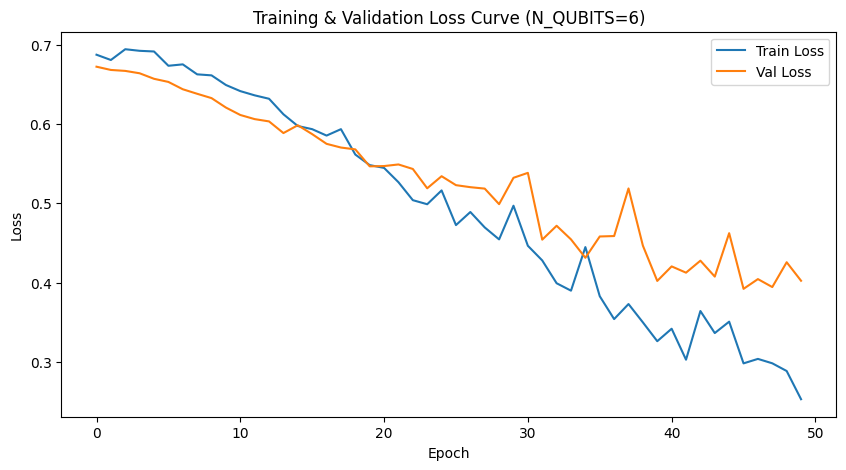

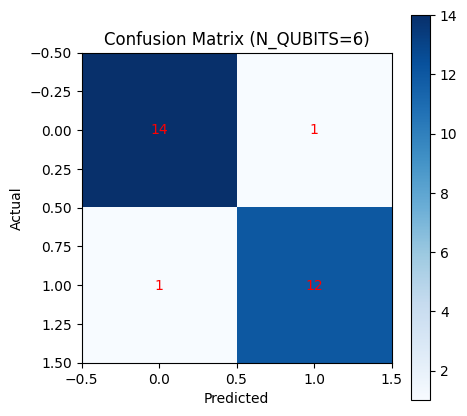

In [ ]:
# ===========================================================================
# CELL 1: IMPORTS & SETUP
# ===========================================================================

import os, zipfile, random, time, warnings, logging
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

import timm
from transformers import ViTModel

import pennylane as qml

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)

# ===========================================================================
# CELL 2: FILE PATHS
# ===========================================================================
DATA_ZIP_PATH = "/content/classification/class"
SEGMENT_MODEL_PATH = "/content/segment.pth"
extract_folder = "/content/classification/class"

# ===========================================================================
# CELL 3: DATASET EXTRACTION
# ===========================================================================


# ===========================================================================
# CELL 4: SEGMENTATION MODEL CHECK & LOAD
# ===========================================================================

if not os.path.exists(SEGMENT_MODEL_PATH):
    raise FileNotFoundError(f"Segmentation model not found at {SEGMENT_MODEL_PATH}")

state_dict = torch.load(SEGMENT_MODEL_PATH, map_location='cpu')
print(f"Segmentation model loaded with {len(state_dict)} layers")

# ===========================================================================
# CELL 5: U-NET SEGMENTATION ARCHITECTURE
# ===========================================================================

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        conv2 = self.dconv_down2(self.maxpool(conv1))
        conv3 = self.dconv_down3(self.maxpool(conv2))
        conv4 = self.dconv_down4(self.maxpool(conv3))
        x = self.upsample(conv4)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out

segmentation_model = UNet(in_ch=3, out_ch=1).to(DEVICE)
segmentation_model.load_state_dict(state_dict)
segmentation_model.eval()
for param in segmentation_model.parameters():
    param.requires_grad = False

# ===========================================================================
# CELL 6: DATASET CLASS
# ===========================================================================

class ROPClassificationDataset(Dataset):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    def __init__(self, image_paths, labels, img_size=224, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        if self.transform: img = self.transform(image=img)['image']
        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1)/255.
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img_tensor, label

def worker_init_fn(worker_id):
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

# ===========================================================================
# CELL 7: LOAD IMAGES & SPLIT DATA
# ===========================================================================
dataset_path = "/content/classification/class"

NORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_Normal"), os.path.join(dataset_path, "RetCam_Normal")]
ABNORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_ROP"), os.path.join(dataset_path, "RetCam_ROP")]

def load_images(folder_list):
    images = []
    for folder in folder_list:
        if os.path.exists(folder):
            for f in sorted(os.listdir(folder)):
                if f.endswith(ROPClassificationDataset.VALID_EXTENSIONS):
                    images.append(os.path.join(folder,f))
    return images

normal_images = load_images(NORMAL_FOLDERS)
abnormal_images = load_images(ABNORMAL_FOLDERS)

all_images = normal_images + abnormal_images
all_labels = [0]*len(normal_images) + [1]*len(abnormal_images)

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=0.3, random_state=RANDOM_SEED, stratify=all_labels
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=0.5, random_state=RANDOM_SEED, stratify=temp_labels
)

# ===========================================================================
# CELL 8: QUANTUM CIRCUIT FUNCTION
# ===========================================================================

def create_quantum_circuit(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def quantum_circuit(inputs, weights):
        amplitude_features = inputs[:, :8]
        angle_features = inputs[:, 8:]
        qml.AmplitudeEmbedding(amplitude_features, wires=range(n_qubits), pad_with=0., normalize=True)
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(angle_features[:, i], wires=i)
            for i in range(n_qubits):
                qml.Rot(weights[layer, i, 0], weights[layer, i, 1], weights[layer, i, 2], wires=i)
            for i in range(n_qubits-1):
                qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[n_qubits-1, 0])
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return quantum_circuit

# ===========================================================================
# CELL 9: TWO-BRANCH HYBRID TITAN ARCHITECTURE
# ===========================================================================

class TwoBranchHybridTitan(nn.Module):
    def __init__(self, segmentation_model, n_qubits=8, n_layers=3):
        super().__init__()
        self.segmentation_model = segmentation_model
        for param in self.segmentation_model.parameters():
            param.requires_grad = False

        # ViT branch
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for param in self.vit.parameters():
            param.requires_grad = False
        for i in range(11,12):
            for param in self.vit.encoder.layer[i].parameters():
                param.requires_grad = True
        for param in self.vit.embeddings.parameters():
            param.requires_grad = True

        # ResNet branch
        self.mask_cnn = timm.create_model('resnet18', pretrained=True, num_classes=0, global_pool='avg')
        for param in self.mask_cnn.parameters():
            param.requires_grad = False
        original_conv1 = self.mask_cnn.conv1
        self.mask_cnn.conv1 = nn.Conv2d(1,64,kernel_size=7,stride=2,padding=3,bias=False)
        with torch.no_grad():
            self.mask_cnn.conv1.weight.copy_(original_conv1.weight.mean(dim=1,keepdim=True))
        self.mask_cnn.conv1.requires_grad = True

        # Fusion
        fusion_dim = 768+512
        self.mha_refiner = nn.MultiheadAttention(embed_dim=fusion_dim,num_heads=8,batch_first=True,dropout=0.1)
        self.compression = nn.Sequential(
            nn.Linear(fusion_dim,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,16),
            nn.Tanh()
        )

        # Quantum
        self.vqc = qml.qnn.TorchLayer(create_quantum_circuit(n_qubits, n_layers), {"weights":(n_layers,n_qubits,3)})
        self.classifier_head = nn.Linear(n_qubits,1)

        self.register_buffer('vit_mean', torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer('vit_std', torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def forward(self,x):
        x_vit = (x-self.vit_mean)/(self.vit_std+1e-8)
        vit_features = self.vit(x_vit).last_hidden_state[:,0,:]
        with torch.no_grad():
            masks = torch.sigmoid(self.segmentation_model(x))
        mask_features = self.mask_cnn(masks)
        fused = torch.cat([vit_features, mask_features], dim=1).unsqueeze(1)
        refined,_ = self.mha_refiner(fused,fused,fused)
        compressed = self.compression(refined.squeeze(1))
        quantum_out = self.vqc(compressed)
        logits = self.classifier_head(quantum_out)
        return logits

# ===========================================================================
# CELL 10: TRAINING & EVALUATION LOOP OVER N_QUBITS_ARRAY
# ===========================================================================

n_qubits_array = [6]
BATCH_SIZE = 8
NUM_EPOCHS = 50
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-3
GRADIENT_CLIP_VALUE = 1.0
EARLY_STOP_PATIENCE = 10

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.3, alpha=100, sigma=10),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4)
])

for N_QUBITS in n_qubits_array:
    print(f"\n{'='*60}\n🔹 RUNNING PIPELINE FOR N_QUBITS = {N_QUBITS}\n{'='*60}")
    # Initialize model
    model = TwoBranchHybridTitan(segmentation_model, n_qubits=N_QUBITS, n_layers=3).to(DEVICE)

    # Dataloaders
    train_dataset = ROPClassificationDataset(train_imgs, train_labels, transform=train_transform)
    val_dataset = ROPClassificationDataset(val_imgs, val_labels, transform=None)
    test_dataset = ROPClassificationDataset(test_imgs, test_labels, transform=None)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    optimizer = optim.Adam([
        {"params": model.vit.parameters(), "lr": LEARNING_RATE_ViT},
        {"params": model.mask_cnn.parameters(), "lr": LEARNING_RATE_ResNet},
        {"params": model.compression.parameters(), "lr": LEARNING_RATE_Standard},
        {"params": model.vqc.parameters(), "lr": LEARNING_RATE_Quantum},
        {"params": model.classifier_head.parameters(), "lr": LEARNING_RATE_Quantum}
    ], weight_decay=WEIGHT_DECAY)

    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(NUM_EPOCHS):
        model.train()
        batch_losses = []
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        # Validation
        model.eval()
        val_batch_losses = []
        all_preds, all_labels_list = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
                logits = model(imgs)
                loss = criterion(logits, labels)
                val_batch_losses.append(loss.item())
                preds = torch.sigmoid(logits).cpu().numpy()
                all_preds.extend(preds)
                all_labels_list.extend(labels.cpu().numpy())
        val_loss = np.mean(val_batch_losses)
        val_pred_classes = (np.array(all_preds) > 0.5).astype(int)
        val_acc = accuracy_score(all_labels_list, val_pred_classes)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), f"best_model_{N_QUBITS}.pth")
        else:
            early_stop_counter +=1
            if early_stop_counter>=EARLY_STOP_PATIENCE:
                print("Early stopping triggered!")
                break

    # =======================================================================
    # TEST & PLOTTING
    # =======================================================================
    model.load_state_dict(torch.load(f"best_model_{N_QUBITS}.pth"))
    model.eval()
    all_preds, all_labels_list = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            logits = model(imgs)
            preds = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(preds)
            all_labels_list.extend(labels.cpu().numpy())
    test_pred_classes = (np.array(all_preds) > 0.5).astype(int)
    test_acc = accuracy_score(all_labels_list, test_pred_classes)
    test_f1 = f1_score(all_labels_list, test_pred_classes)
    test_auc = roc_auc_score(all_labels_list, all_preds)
    print(f"✅ Test metrics for N_QUBITS={N_QUBITS}: Acc={test_acc:.4f}, F1={test_f1:.4f}, AUC={test_auc:.4f}")

    # Plot training curves
    plt.figure(figsize=(10,5))
    plt.plot(train_losses,label='Train Loss')
    plt.plot(val_losses,label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"Training & Validation Loss Curve (N_QUBITS={N_QUBITS})")
    plt.legend()
    plt.savefig(f"training_curve_{N_QUBITS}.png")
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(all_labels_list, test_pred_classes)
    plt.figure(figsize=(5,5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion Matrix (N_QUBITS={N_QUBITS})")
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j,i,str(cm[i,j]),ha='center',va='center',color='red')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f"confusion_matrix_{N_QUBITS}.png")
    plt.show()



📁 DATASET EXTRACTION

📤 SEGMENTATION MODEL CHECK
📍 Found model: /content/segment.pth
   ✓ Found 100 layers in model

🖥️  SYSTEM CONFIGURATION
✓ Device: cuda
✓ GPU: Tesla T4
✓ DataLoader Workers: 2
✓ Random Seed: 42
✓ Weight Decay: 0.001


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

HybridROPClassifier(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_a

Epoch 1/50 [Train]: 100%|██████████| 17/17 [00:20<00:00,  1.20s/it]


...

Epoch 48: Train Loss=0.4769 Acc=0.9845 | Val Loss=0.5390 Acc=0.8571


Epoch 49/50 [Train]: 100%|██████████| 17/17 [00:09<00:00,  1.74it/s]


Epoch 49: Train Loss=0.4732 Acc=0.9845 | Val Loss=0.5347 Acc=0.8571
✅ Saved best model


Epoch 50/50 [Train]: 100%|██████████| 17/17 [00:09<00:00,  1.72it/s]


Epoch 50: Train Loss=0.4703 Acc=0.9845 | Val Loss=0.5322 Acc=0.8571
✅ Saved best model


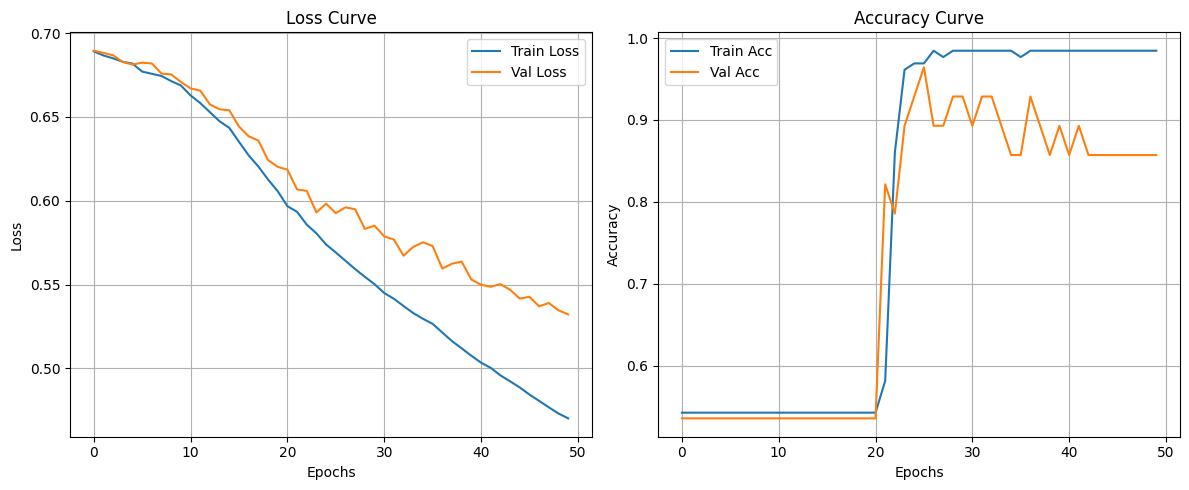


🧪 TESTING MODEL
✅ TEST ACCURACY: 0.8929
🎯 TEST F1 SCORE: 0.8696

📌 CONFUSION MATRIX:
[[15  0]
 [ 3 10]]


In [ ]:
# ===========================================================================
# ❗❗ FILE PATHS ❗❗
# ===========================================================================
DATA_ZIP_PATH = "/content/classification/class"
SEGMENT_MODEL_PATH = "/content/segment.pth"
extract_folder = "/content/classification/class"

# ===========================================================================
# CELL 2: Dataset Extraction
# ===========================================================================
import os, zipfile, random, time, warnings, logging
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, cv2, timm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import pennylane as qml
from transformers import ViTModel
warnings.filterwarnings("ignore")

print("\n" + "="*60)
print("📁 DATASET EXTRACTION")
print("="*60)

dataset_path = "/content/classification/class"
extract_folder = "/content/classification/class"

# ===========================================================================
# CELL 3: Validate Segmentation Model
# ===========================================================================
print("\n" + "="*60)
print("📤 SEGMENTATION MODEL CHECK")
print("="*60)

segment_model_path = SEGMENT_MODEL_PATH
if not os.path.exists(SEGMENT_MODEL_PATH):
    print(f"❌ ERROR: Model file not found at {SEGMENT_MODEL_PATH}")
else:
    try:
        print(f"📍 Found model: {SEGMENT_MODEL_PATH}")
        state_dict = torch.load(SEGMENT_MODEL_PATH, map_location='cpu')
        if isinstance(state_dict, dict):
            print(f"   ✓ Found {len(state_dict)} layers in model")
            segment_model_path = SEGMENT_MODEL_PATH
        else:
            print(f"⚠️ Unexpected model format, saving path anyway")
            segment_model_path = SEGMENT_MODEL_PATH
    except Exception as e:
        print(f"❌ ERROR loading model: {str(e)}")

print("="*60)

# ===========================================================================
# CELL 4: Configuration & Constants
# ===========================================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2

ViT_OUTPUT_DIM = 768
RESNET18_OUTPUT_DIM = 512
FUSION_DIM = ViT_OUTPUT_DIM + RESNET18_OUTPUT_DIM
COMPRESSION_DIM_1 = 128
COMPRESSION_DIM_2 = 16

N_QUBITS = 10
N_QUANTUM_LAYERS = 3
QUANTUM_PARAMS = N_QUANTUM_LAYERS * N_QUBITS * 3
HILBERT_SPACE_DIM = 2 ** N_QUBITS

IMG_SIZE = 224
BATCH_SIZE = 8
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-3
NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 10
GRADIENT_CLIP_VALUE = 1.0

TEST_SIZE = 0.3
VAL_RATIO = 0.5
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)
VERBOSE = True

def set_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(RANDOM_SEED)

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("\n" + "="*60)
print("🖥️  SYSTEM CONFIGURATION")
print("="*60)
print(f"✓ Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"✓ DataLoader Workers: {NUM_WORKERS}")
print(f"✓ Random Seed: {RANDOM_SEED}")
print(f"✓ Weight Decay: {WEIGHT_DECAY}")
print("="*60)

# ===========================================================================
# CELL 5: U-Net Segmentation Model
# ===========================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        conv2 = self.dconv_down2(self.maxpool(conv1))
        conv3 = self.dconv_down3(self.maxpool(conv2))
        conv4 = self.dconv_down4(self.maxpool(conv3))
        x = self.upsample(conv4)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out

segmentation_model = UNet(in_ch=3, out_ch=1).to(DEVICE)
state_dict = torch.load(segment_model_path, map_location=DEVICE)
segmentation_model.load_state_dict(state_dict)
segmentation_model.eval()
for param in segmentation_model.parameters():
    param.requires_grad = False

# ===========================================================================
# CELL 6: Dataset Class
# ===========================================================================
class ROPClassificationDataset(Dataset):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    def __init__(self, image_paths, labels, img_size=IMG_SIZE, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform
        assert len(image_paths) == len(labels), "Image and label count mismatch"
        if VERBOSE:
            print(f"Initialized dataset with {len(image_paths)} samples")
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        if img is None: img = np.zeros((self.img_size,self.img_size,3))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        if self.transform:
            img = self.transform(image=img)['image']
        img = img.astype(np.float32) / 255.0
        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img_tensor, label

def worker_init_fn(worker_id):
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

# ===========================================================================
# CELL 7: Data Preparation
# ===========================================================================
NORMAL_FOLDERS = [
    os.path.join(dataset_path, "Neo_Normal"),
    os.path.join(dataset_path, "RetCam_Normal")
]
ABNORMAL_FOLDERS = [
    os.path.join(dataset_path, "Neo_ROP"),
    os.path.join(dataset_path, "RetCam_ROP")
]

def load_images_from_folder(folder_path, valid_extensions):
    images = []
    if not os.path.exists(folder_path): return images
    for f in sorted(os.listdir(folder_path)):
        if any(f.endswith(ext) for ext in valid_extensions):
            images.append(os.path.join(folder_path, f))
    return images

normal_images = []
for folder in NORMAL_FOLDERS:
    normal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))
abnormal_images = []
for folder in ABNORMAL_FOLDERS:
    abnormal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))

COUNT_NORMAL = len(normal_images)
COUNT_ABNORMAL = len(abnormal_images)

all_images = normal_images + abnormal_images
all_labels = [0]*COUNT_NORMAL + [1]*COUNT_ABNORMAL

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=TEST_SIZE,
    random_state=RANDOM_SEED, stratify=all_labels)

val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=VAL_RATIO,
    random_state=RANDOM_SEED, stratify=temp_labels)

# ===========================================================================
# CELL 8: Quantum Circuit
# ===========================================================================
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):

    if inputs.shape[1] < N_QUBITS:
        padded_inputs = torch.zeros(inputs.shape[0], N_QUBITS, device=inputs.device)
        padded_inputs[:, :inputs.shape[1]] = inputs
        inputs = padded_inputs
    elif inputs.shape[1] > N_QUBITS:
        inputs = inputs[:, :N_QUBITS]

    qml.AmplitudeEmbedding(inputs, wires=range(N_QUBITS), pad_with=0., normalize=True)

    for layer in range(N_QUANTUM_LAYERS):

        for i in range(N_QUBITS):
            qml.RY(inputs[:, i], wires=i)

        for i in range(N_QUBITS):
            qml.Rot(weights[layer,i,0], weights[layer,i,1], weights[layer,i,2], wires=i)

        for i in range(N_QUBITS-1):
            qml.CNOT(wires=[i,i+1])
        qml.CNOT(wires=[N_QUBITS-1,0])

    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shape = {"weights": (N_QUANTUM_LAYERS, N_QUBITS, 3)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shape)

# ===========================================================================
# CELL 9: Hybrid Classifier
# ===========================================================================
class HybridROPClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        self.resnet = timm.create_model("resnet18", pretrained=True)
        self.resnet.fc = nn.Identity()
        for param in self.vit.parameters(): param.requires_grad = True
        for param in self.resnet.parameters(): param.requires_grad = True

        self.compression = nn.Sequential(
            nn.Linear(FUSION_DIM, COMPRESSION_DIM_1),
            nn.ReLU(),
            nn.Linear(COMPRESSION_DIM_1, COMPRESSION_DIM_2),
            nn.ReLU()
        )

        self.quantum_layer = quantum_layer
        self.classifier = nn.Linear(N_QUBITS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        vit_feat = self.vit(x).last_hidden_state[:,0,:]
        res_feat = self.resnet(x)
        fused = torch.cat([vit_feat, res_feat], dim=1)
        compressed = self.compression(fused)
        q_out = self.quantum_layer(compressed)
        out = self.classifier(q_out)
        return self.sigmoid(out)

model = HybridROPClassifier().to(DEVICE)
print(model)

# ===========================================================================
# CELL 10: Dataloaders
# ===========================================================================
train_dataset = ROPClassificationDataset(train_imgs, train_labels, IMG_SIZE)
val_dataset = ROPClassificationDataset(val_imgs, val_labels, IMG_SIZE)
test_dataset = ROPClassificationDataset(test_imgs, test_labels, IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# ===========================================================================
# CELL 11: Training Setup
# ===========================================================================
criterion = nn.BCELoss()

optimizer = optim.Adam([
    {'params': model.vit.parameters(), 'lr': LEARNING_RATE_ViT},
    {'params': model.resnet.parameters(), 'lr': LEARNING_RATE_ResNet},
    {'params': model.compression.parameters(), 'lr': LEARNING_RATE_Standard},
    {'params': model.quantum_layer.parameters(), 'lr': LEARNING_RATE_Quantum},
    {'params': model.classifier.parameters(), 'lr': LEARNING_RATE_Standard},
], weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_val_loss = float('inf')
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# ===========================================================================
# CELL 12: Training Loop
# ===========================================================================
for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    running_loss, running_corrects = 0.0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        running_corrects += ((outputs>0.5)==labels.bool()).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            val_corrects += ((outputs>0.5)==labels.bool()).sum().item()

    val_epoch_loss = val_loss / len(val_dataset)
    val_epoch_acc = val_corrects / len(val_dataset)

    val_losses.append(val_epoch_loss)
    val_accs.append(val_epoch_acc)

    scheduler.step(val_epoch_loss)

    print(f"Epoch {epoch}: Train Loss={epoch_loss:.4f} Acc={epoch_acc:.4f} | Val Loss={val_epoch_loss:.4f} Acc={val_epoch_acc:.4f}")

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), "/content/best_hybrid_model.pth")
        patience_counter = 0
        print("✅ Saved best model")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print("⚠️ Early stopping triggered")
            break

# ===========================================================================
# CELL 13: Plotting Loss & Accuracy
# ===========================================================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss Curve')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Accuracy Curve')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

# ===========================================================================
# ⭐ NEW CELL ADDED — TEST ACCURACY + F1 ⭐
# ===========================================================================
print("\n" + "="*60)
print("🧪 TESTING MODEL")
print("="*60)

model.load_state_dict(torch.load("/content/best_hybrid_model.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels_list = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = (outputs.cpu().numpy() > 0.5).astype(int)
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

test_acc = accuracy_score(all_labels_list, all_preds)
test_f1 = f1_score(all_labels_list, all_preds)
cm = confusion_matrix(all_labels_list, all_preds)

print(f"✅ TEST ACCURACY: {test_acc:.4f}")
print(f"🎯 TEST F1 SCORE: {test_f1:.4f}")
print("\n📌 CONFUSION MATRIX:")
print(cm)


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


Segmentation model loaded with 100 layers

🔹 RUNNING PIPELINE FOR N_QUBITS = 6


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Train Loss=0.6879, Val Loss=0.6735, Val Acc=0.5357


Epoch 2: Train Loss=0.6817, Val Loss=0.6700, Val Acc=0.5357


...

Epoch 46: Train Loss=0.3641, Val Loss=0.4552, Val Acc=0.8929


Epoch 47: Train Loss=0.3529, Val Loss=0.4333, Val Acc=0.8929


Epoch 48: Train Loss=0.3380, Val Loss=0.5377, Val Acc=0.8214


Epoch 49: Train Loss=0.3550, Val Loss=0.4871, Val Acc=0.8929


Epoch 50: Train Loss=0.3575, Val Loss=0.4570, Val Acc=0.8929
✅ Test metrics for N_QUBITS=6: Acc=0.8571, F1=0.8333, AUC=0.9436


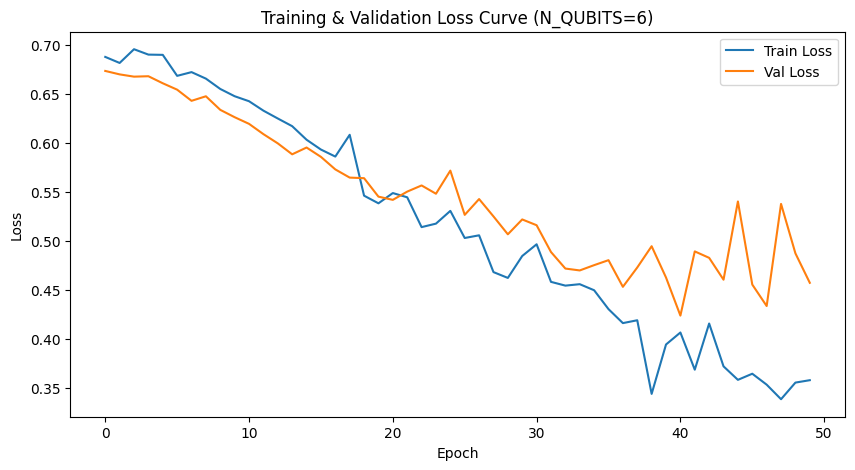

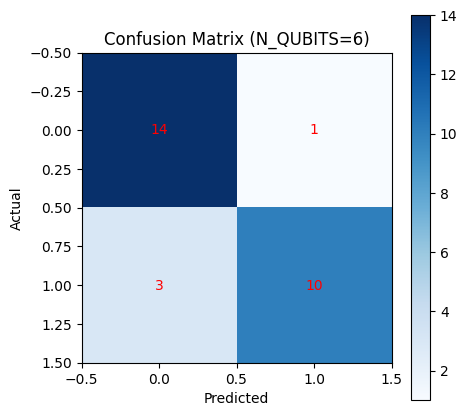

In [ ]:
# ===========================================================================
# ===========================================================================

import os, zipfile, random, time, warnings, logging
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

import timm
from transformers import ViTModel

import pennylane as qml

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)

# ===========================================================================
# CELL 2: FILE PATHS
# ===========================================================================
DATA_ZIP_PATH = "/content/classification/class"
SEGMENT_MODEL_PATH = "/content/segment.pth"
extract_folder = "/content/classification/class"

# ===========================================================================
# CELL 3: DATASET EXTRACTION
# ===========================================================================


# ===========================================================================
# CELL 4: SEGMENTATION MODEL CHECK & LOAD
# ===========================================================================

if not os.path.exists(SEGMENT_MODEL_PATH):
    raise FileNotFoundError(f"Segmentation model not found at {SEGMENT_MODEL_PATH}")

state_dict = torch.load(SEGMENT_MODEL_PATH, map_location='cpu')
print(f"Segmentation model loaded with {len(state_dict)} layers")

# ===========================================================================
# CELL 5: U-NET SEGMENTATION ARCHITECTURE
# ===========================================================================

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        conv2 = self.dconv_down2(self.maxpool(conv1))
        conv3 = self.dconv_down3(self.maxpool(conv2))
        conv4 = self.dconv_down4(self.maxpool(conv3))
        x = self.upsample(conv4)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out

segmentation_model = UNet(in_ch=3, out_ch=1).to(DEVICE)
segmentation_model.load_state_dict(state_dict)
segmentation_model.eval()
for param in segmentation_model.parameters():
    param.requires_grad = False

# ===========================================================================
# CELL 6: DATASET CLASS
# ===========================================================================

class ROPClassificationDataset(Dataset):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    def __init__(self, image_paths, labels, img_size=224, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        if self.transform: img = self.transform(image=img)['image']
        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1)/255.
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img_tensor, label

def worker_init_fn(worker_id):
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

# ===========================================================================
# CELL 7: LOAD IMAGES & SPLIT DATA
# ===========================================================================
dataset_path = "/content/classification/class"

NORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_Normal"), os.path.join(dataset_path, "RetCam_Normal")]
ABNORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_ROP"), os.path.join(dataset_path, "RetCam_ROP")]

def load_images(folder_list):
    images = []
    for folder in folder_list:
        if os.path.exists(folder):
            for f in sorted(os.listdir(folder)):
                if f.endswith(ROPClassificationDataset.VALID_EXTENSIONS):
                    images.append(os.path.join(folder,f))
    return images

normal_images = load_images(NORMAL_FOLDERS)
abnormal_images = load_images(ABNORMAL_FOLDERS)

all_images = normal_images + abnormal_images
all_labels = [0]*len(normal_images) + [1]*len(abnormal_images)

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=0.3, random_state=RANDOM_SEED, stratify=all_labels
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=0.5, random_state=RANDOM_SEED, stratify=temp_labels
)

# ===========================================================================
# CELL 8: QUANTUM CIRCUIT FUNCTION
# ===========================================================================

def create_quantum_circuit(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def quantum_circuit(inputs, weights):
        amplitude_features = inputs[:, :8]
        angle_features = inputs[:, 8:]
        qml.AmplitudeEmbedding(amplitude_features, wires=range(n_qubits), pad_with=0., normalize=True)
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(angle_features[:, i], wires=i)
            for i in range(n_qubits):
                qml.Rot(weights[layer, i, 0], weights[layer, i, 1], weights[layer, i, 2], wires=i)
            for i in range(n_qubits-1):
                qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[n_qubits-1, 0])
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return quantum_circuit

# ===========================================================================
# CELL 9: TWO-BRANCH HYBRID TITAN ARCHITECTURE
# ===========================================================================

class TwoBranchHybridTitan(nn.Module):
    def __init__(self, segmentation_model, n_qubits=8, n_layers=3):
        super().__init__()
        self.segmentation_model = segmentation_model
        for param in self.segmentation_model.parameters():
            param.requires_grad = False

        # ViT branch
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for param in self.vit.parameters():
            param.requires_grad = False
        for i in range(11,12):
            for param in self.vit.encoder.layer[i].parameters():
                param.requires_grad = True
        for param in self.vit.embeddings.parameters():
            param.requires_grad = True

        # ResNet branch
        self.mask_cnn = timm.create_model('resnet18', pretrained=True, num_classes=0, global_pool='avg')
        for param in self.mask_cnn.parameters():
            param.requires_grad = False
        original_conv1 = self.mask_cnn.conv1
        self.mask_cnn.conv1 = nn.Conv2d(1,64,kernel_size=7,stride=2,padding=3,bias=False)
        with torch.no_grad():
            self.mask_cnn.conv1.weight.copy_(original_conv1.weight.mean(dim=1,keepdim=True))
        self.mask_cnn.conv1.requires_grad = True

        # Fusion
        fusion_dim = 768+512
        self.mha_refiner = nn.MultiheadAttention(embed_dim=fusion_dim,num_heads=8,batch_first=True,dropout=0.1)
        self.compression = nn.Sequential(
            nn.Linear(fusion_dim,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,16),
            nn.Tanh()
        )

        # Quantum
        self.vqc = qml.qnn.TorchLayer(create_quantum_circuit(n_qubits, n_layers), {"weights":(n_layers,n_qubits,3)})
        self.classifier_head = nn.Linear(n_qubits,1)

        self.register_buffer('vit_mean', torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer('vit_std', torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def forward(self,x):
        x_vit = (x-self.vit_mean)/(self.vit_std+1e-8)
        vit_features = self.vit(x_vit).last_hidden_state[:,0,:]
        with torch.no_grad():
            masks = torch.sigmoid(self.segmentation_model(x))
        mask_features = self.mask_cnn(masks)
        fused = torch.cat([vit_features, mask_features], dim=1).unsqueeze(1)
        refined,_ = self.mha_refiner(fused,fused,fused)
        compressed = self.compression(refined.squeeze(1))
        quantum_out = self.vqc(compressed)
        logits = self.classifier_head(quantum_out)
        return logits

# ===========================================================================
# CELL 10: TRAINING & EVALUATION LOOP OVER N_QUBITS_ARRAY
# ===========================================================================

n_qubits_array = [6]
BATCH_SIZE = 8
NUM_EPOCHS = 50
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-3
GRADIENT_CLIP_VALUE = 1.0
EARLY_STOP_PATIENCE = 10

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.3, alpha=100, sigma=10),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4)
])

for N_QUBITS in n_qubits_array:
    print(f"\n{'='*60}\n🔹 RUNNING PIPELINE FOR N_QUBITS = {N_QUBITS}\n{'='*60}")
    # Initialize model
    model = TwoBranchHybridTitan(segmentation_model, n_qubits=N_QUBITS, n_layers=3).to(DEVICE)

    # Dataloaders
    train_dataset = ROPClassificationDataset(train_imgs, train_labels, transform=train_transform)
    val_dataset = ROPClassificationDataset(val_imgs, val_labels, transform=None)
    test_dataset = ROPClassificationDataset(test_imgs, test_labels, transform=None)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    optimizer = optim.Adam([
        {"params": model.vit.parameters(), "lr": LEARNING_RATE_ViT},
        {"params": model.mask_cnn.parameters(), "lr": LEARNING_RATE_ResNet},
        {"params": model.compression.parameters(), "lr": LEARNING_RATE_Standard},
        {"params": model.vqc.parameters(), "lr": LEARNING_RATE_Quantum},
        {"params": model.classifier_head.parameters(), "lr": LEARNING_RATE_Quantum}
    ], weight_decay=WEIGHT_DECAY)

    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(NUM_EPOCHS):
        model.train()
        batch_losses = []
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        # Validation
        model.eval()
        val_batch_losses = []
        all_preds, all_labels_list = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
                logits = model(imgs)
                loss = criterion(logits, labels)
                val_batch_losses.append(loss.item())
                preds = torch.sigmoid(logits).cpu().numpy()
                all_preds.extend(preds)
                all_labels_list.extend(labels.cpu().numpy())
        val_loss = np.mean(val_batch_losses)
        val_pred_classes = (np.array(all_preds) > 0.5).astype(int)
        val_acc = accuracy_score(all_labels_list, val_pred_classes)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), f"best_model_{N_QUBITS}.pth")
        else:
            early_stop_counter +=1
            if early_stop_counter>=EARLY_STOP_PATIENCE:
                print("Early stopping triggered!")
                break

    # =======================================================================
    # TEST & PLOTTING
    # =======================================================================
    model.load_state_dict(torch.load(f"best_model_{N_QUBITS}.pth"))
    model.eval()
    all_preds, all_labels_list = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            logits = model(imgs)
            preds = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(preds)
            all_labels_list.extend(labels.cpu().numpy())
    test_pred_classes = (np.array(all_preds) > 0.5).astype(int)
    test_acc = accuracy_score(all_labels_list, test_pred_classes)
    test_f1 = f1_score(all_labels_list, test_pred_classes)
    test_auc = roc_auc_score(all_labels_list, all_preds)
    print(f"✅ Test metrics for N_QUBITS={N_QUBITS}: Acc={test_acc:.4f}, F1={test_f1:.4f}, AUC={test_auc:.4f}")

    # Plot training curves
    plt.figure(figsize=(10,5))
    plt.plot(train_losses,label='Train Loss')
    plt.plot(val_losses,label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"Training & Validation Loss Curve (N_QUBITS={N_QUBITS})")
    plt.legend()
    plt.savefig(f"training_curve_{N_QUBITS}.png")
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(all_labels_list, test_pred_classes)
    plt.figure(figsize=(5,5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion Matrix (N_QUBITS={N_QUBITS})")
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j,i,str(cm[i,j]),ha='center',va='center',color='red')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f"confusion_matrix_{N_QUBITS}.png")
    plt.show()


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


Segmentation model loaded with 100 layers

🔹 RUNNING PIPELINE FOR N_QUBITS = 6


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Train Loss=0.6868, Val Loss=0.6692, Val Acc=0.5357


Epoch 2: Train Loss=0.6784, Val Loss=0.6625, Val Acc=0.5357


...

Epoch 46: Train Loss=0.3431, Val Loss=0.4058, Val Acc=0.8214


Epoch 47: Train Loss=0.3233, Val Loss=0.4335, Val Acc=0.8929


Epoch 48: Train Loss=0.3000, Val Loss=0.4100, Val Acc=0.8929


Epoch 49: Train Loss=0.3348, Val Loss=0.4298, Val Acc=0.8929


Epoch 50: Train Loss=0.3104, Val Loss=0.4149, Val Acc=0.8929
✅ Test metrics for N_QUBITS=6: Acc=0.8214, F1=0.7826, AUC=0.9282


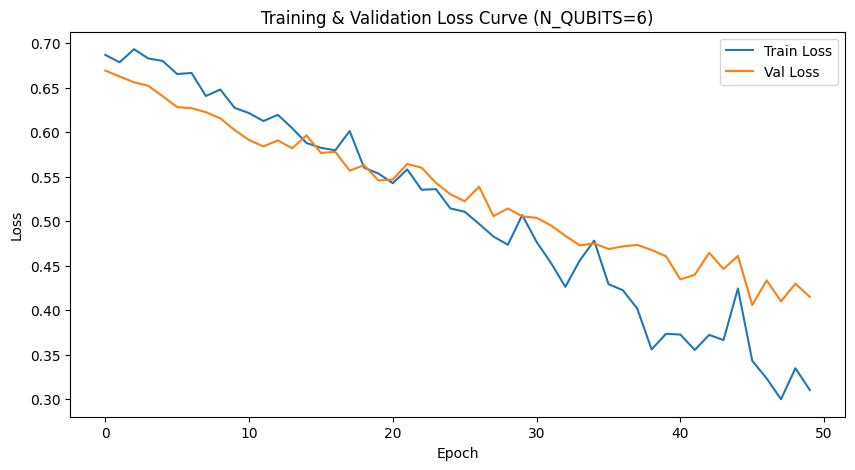

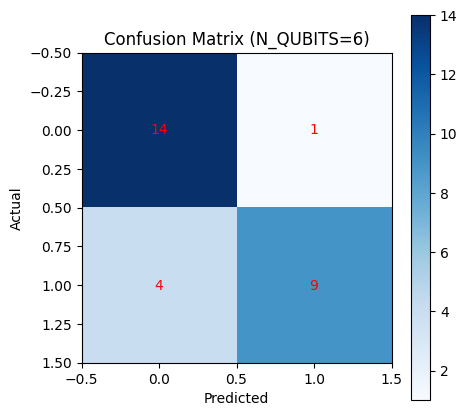

In [ ]:
# ===========================================================================
# ===========================================================================

import os, zipfile, random, time, warnings, logging
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

import timm
from transformers import ViTModel

import pennylane as qml

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)

# ===========================================================================
# CELL 2: FILE PATHS
# ===========================================================================
DATA_ZIP_PATH = "/content/classification/class"
SEGMENT_MODEL_PATH = "/content/segment.pth"
extract_folder = "/content/classification/class"

# ===========================================================================
# CELL 3: DATASET EXTRACTION
# ===========================================================================


# ===========================================================================
# CELL 4: SEGMENTATION MODEL CHECK & LOAD
# ===========================================================================

if not os.path.exists(SEGMENT_MODEL_PATH):
    raise FileNotFoundError(f"Segmentation model not found at {SEGMENT_MODEL_PATH}")

state_dict = torch.load(SEGMENT_MODEL_PATH, map_location='cpu')
print(f"Segmentation model loaded with {len(state_dict)} layers")

# ===========================================================================
# CELL 5: U-NET SEGMENTATION ARCHITECTURE
# ===========================================================================

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        conv2 = self.dconv_down2(self.maxpool(conv1))
        conv3 = self.dconv_down3(self.maxpool(conv2))
        conv4 = self.dconv_down4(self.maxpool(conv3))
        x = self.upsample(conv4)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out

segmentation_model = UNet(in_ch=3, out_ch=1).to(DEVICE)
segmentation_model.load_state_dict(state_dict)
segmentation_model.eval()
for param in segmentation_model.parameters():
    param.requires_grad = False

# ===========================================================================
# CELL 6: DATASET CLASS
# ===========================================================================

class ROPClassificationDataset(Dataset):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    def __init__(self, image_paths, labels, img_size=224, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        if self.transform: img = self.transform(image=img)['image']
        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1)/255.
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img_tensor, label

def worker_init_fn(worker_id):
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

# ===========================================================================
# CELL 7: LOAD IMAGES & SPLIT DATA
# ===========================================================================
dataset_path = "/content/classification/class"

NORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_Normal"), os.path.join(dataset_path, "RetCam_Normal")]
ABNORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_ROP"), os.path.join(dataset_path, "RetCam_ROP")]

def load_images(folder_list):
    images = []
    for folder in folder_list:
        if os.path.exists(folder):
            for f in sorted(os.listdir(folder)):
                if f.endswith(ROPClassificationDataset.VALID_EXTENSIONS):
                    images.append(os.path.join(folder,f))
    return images

normal_images = load_images(NORMAL_FOLDERS)
abnormal_images = load_images(ABNORMAL_FOLDERS)

all_images = normal_images + abnormal_images
all_labels = [0]*len(normal_images) + [1]*len(abnormal_images)

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=0.3, random_state=RANDOM_SEED, stratify=all_labels
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=0.5, random_state=RANDOM_SEED, stratify=temp_labels
)

# ===========================================================================
# CELL 8: QUANTUM CIRCUIT FUNCTION
# ===========================================================================

def create_quantum_circuit(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def quantum_circuit(inputs, weights):
        amplitude_features = inputs[:, :8]
        angle_features = inputs[:, 8:]
        qml.AmplitudeEmbedding(amplitude_features, wires=range(n_qubits), pad_with=0., normalize=True)
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(angle_features[:, i], wires=i)
            for i in range(n_qubits):
                qml.Rot(weights[layer, i, 0], weights[layer, i, 1], weights[layer, i, 2], wires=i)
            for i in range(n_qubits-1):
                qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[n_qubits-1, 0])
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return quantum_circuit

# ===========================================================================
# CELL 9: TWO-BRANCH HYBRID TITAN ARCHITECTURE
# ===========================================================================

class TwoBranchHybridTitan(nn.Module):
    def __init__(self, segmentation_model, n_qubits=8, n_layers=3):
        super().__init__()
        self.segmentation_model = segmentation_model
        for param in self.segmentation_model.parameters():
            param.requires_grad = False

        # ViT branch
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for param in self.vit.parameters():
            param.requires_grad = False
        for i in range(11,12):
            for param in self.vit.encoder.layer[i].parameters():
                param.requires_grad = True
        for param in self.vit.embeddings.parameters():
            param.requires_grad = True

        # ResNet branch
        self.mask_cnn = timm.create_model('resnet18', pretrained=True, num_classes=0, global_pool='avg')
        for param in self.mask_cnn.parameters():
            param.requires_grad = False
        original_conv1 = self.mask_cnn.conv1
        self.mask_cnn.conv1 = nn.Conv2d(1,64,kernel_size=7,stride=2,padding=3,bias=False)
        with torch.no_grad():
            self.mask_cnn.conv1.weight.copy_(original_conv1.weight.mean(dim=1,keepdim=True))
        self.mask_cnn.conv1.requires_grad = True

        # Fusion
        fusion_dim = 768+512
        self.mha_refiner = nn.MultiheadAttention(embed_dim=fusion_dim,num_heads=8,batch_first=True,dropout=0.1)
        self.compression = nn.Sequential(
            nn.Linear(fusion_dim,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,16),
            nn.Tanh()
        )

        # Quantum
        self.vqc = qml.qnn.TorchLayer(create_quantum_circuit(n_qubits, n_layers), {"weights":(n_layers,n_qubits,3)})
        self.classifier_head = nn.Linear(n_qubits,1)

        self.register_buffer('vit_mean', torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer('vit_std', torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def forward(self,x):
        x_vit = (x-self.vit_mean)/(self.vit_std+1e-8)
        vit_features = self.vit(x_vit).last_hidden_state[:,0,:]
        with torch.no_grad():
            masks = torch.sigmoid(self.segmentation_model(x))
        mask_features = self.mask_cnn(masks)
        fused = torch.cat([vit_features, mask_features], dim=1).unsqueeze(1)
        refined,_ = self.mha_refiner(fused,fused,fused)
        compressed = self.compression(refined.squeeze(1))
        quantum_out = self.vqc(compressed)
        logits = self.classifier_head(quantum_out)
        return logits

# ===========================================================================
# CELL 10: TRAINING & EVALUATION LOOP OVER N_QUBITS_ARRAY
# ===========================================================================

n_qubits_array = [6]
BATCH_SIZE = 8
NUM_EPOCHS = 50
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-3
GRADIENT_CLIP_VALUE = 1.0
EARLY_STOP_PATIENCE = 10

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.3, alpha=100, sigma=10),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4)
])

for N_QUBITS in n_qubits_array:
    print(f"\n{'='*60}\n🔹 RUNNING PIPELINE FOR N_QUBITS = {N_QUBITS}\n{'='*60}")
    # Initialize model
    model = TwoBranchHybridTitan(segmentation_model, n_qubits=N_QUBITS, n_layers=3).to(DEVICE)

    # Dataloaders
    train_dataset = ROPClassificationDataset(train_imgs, train_labels, transform=train_transform)
    val_dataset = ROPClassificationDataset(val_imgs, val_labels, transform=None)
    test_dataset = ROPClassificationDataset(test_imgs, test_labels, transform=None)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    optimizer = optim.Adam([
        {"params": model.vit.parameters(), "lr": LEARNING_RATE_ViT},
        {"params": model.mask_cnn.parameters(), "lr": LEARNING_RATE_ResNet},
        {"params": model.compression.parameters(), "lr": LEARNING_RATE_Standard},
        {"params": model.vqc.parameters(), "lr": LEARNING_RATE_Quantum},
        {"params": model.classifier_head.parameters(), "lr": LEARNING_RATE_Quantum}
    ], weight_decay=WEIGHT_DECAY)

    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(NUM_EPOCHS):
        model.train()
        batch_losses = []
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        # Validation
        model.eval()
        val_batch_losses = []
        all_preds, all_labels_list = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
                logits = model(imgs)
                loss = criterion(logits, labels)
                val_batch_losses.append(loss.item())
                preds = torch.sigmoid(logits).cpu().numpy()
                all_preds.extend(preds)
                all_labels_list.extend(labels.cpu().numpy())
        val_loss = np.mean(val_batch_losses)
        val_pred_classes = (np.array(all_preds) > 0.5).astype(int)
        val_acc = accuracy_score(all_labels_list, val_pred_classes)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), f"best_model_{N_QUBITS}.pth")
        else:
            early_stop_counter +=1
            if early_stop_counter>=EARLY_STOP_PATIENCE:
                print("Early stopping triggered!")
                break

    # =======================================================================
    # TEST & PLOTTING
    # =======================================================================
    model.load_state_dict(torch.load(f"best_model_{N_QUBITS}.pth"))
    model.eval()
    all_preds, all_labels_list = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            logits = model(imgs)
            preds = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(preds)
            all_labels_list.extend(labels.cpu().numpy())
    test_pred_classes = (np.array(all_preds) > 0.5).astype(int)
    test_acc = accuracy_score(all_labels_list, test_pred_classes)
    test_f1 = f1_score(all_labels_list, test_pred_classes)
    test_auc = roc_auc_score(all_labels_list, all_preds)
    print(f"✅ Test metrics for N_QUBITS={N_QUBITS}: Acc={test_acc:.4f}, F1={test_f1:.4f}, AUC={test_auc:.4f}")

    # Plot training curves
    plt.figure(figsize=(10,5))
    plt.plot(train_losses,label='Train Loss')
    plt.plot(val_losses,label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"Training & Validation Loss Curve (N_QUBITS={N_QUBITS})")
    plt.legend()
    plt.savefig(f"training_curve_{N_QUBITS}.png")
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(all_labels_list, test_pred_classes)
    plt.figure(figsize=(5,5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion Matrix (N_QUBITS={N_QUBITS})")
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j,i,str(cm[i,j]),ha='center',va='center',color='red')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f"confusion_matrix_{N_QUBITS}.png")
    plt.show()


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


Segmentation model loaded with 100 layers

🔹 RUNNING PIPELINE FOR N_QUBITS = 6


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Train Loss=0.6869, Val Loss=0.6696, Val Acc=0.5357


Epoch 2: Train Loss=0.6783, Val Loss=0.6630, Val Acc=0.5357


...

Epoch 46: Train Loss=0.3634, Val Loss=0.4512, Val Acc=0.8571


Epoch 47: Train Loss=0.3760, Val Loss=0.4998, Val Acc=0.8571


Epoch 48: Train Loss=0.3614, Val Loss=0.5331, Val Acc=0.8214


Epoch 49: Train Loss=0.3154, Val Loss=0.4765, Val Acc=0.8571


Epoch 50: Train Loss=0.3566, Val Loss=0.4605, Val Acc=0.8571
✅ Test metrics for N_QUBITS=6: Acc=0.8929, F1=0.8800, AUC=0.9333


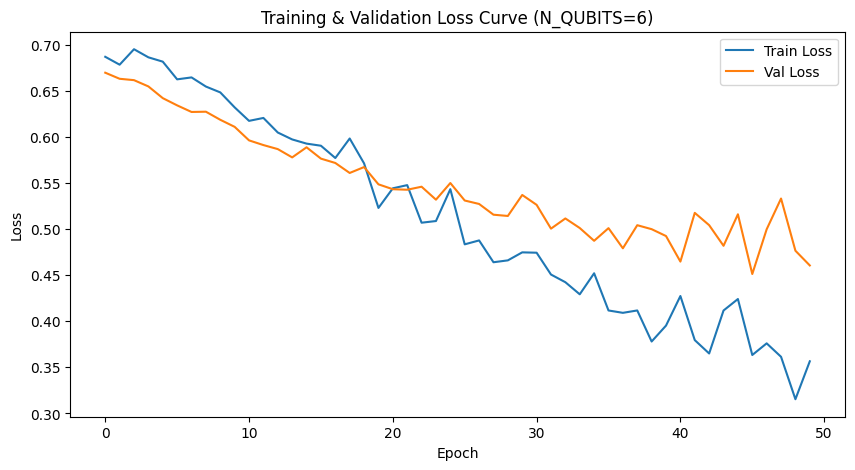

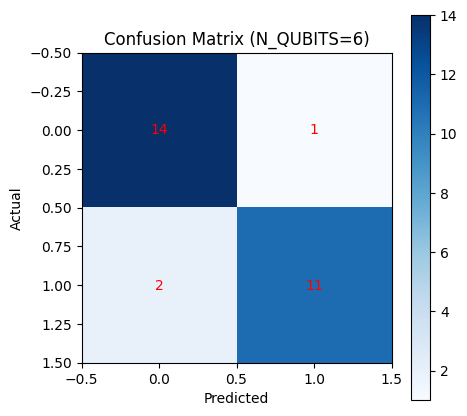

In [ ]:
# ===========================================================================
# ===========================================================================

import os, zipfile, random, time, warnings, logging
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

import timm
from transformers import ViTModel

import pennylane as qml

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)

# ===========================================================================
# CELL 2: FILE PATHS
# ===========================================================================
DATA_ZIP_PATH = "/content/classification/class"
SEGMENT_MODEL_PATH = "/content/segment.pth"
extract_folder = "/content/classification/class"

# ===========================================================================
# CELL 3: DATASET EXTRACTION
# ===========================================================================


# ===========================================================================
# CELL 4: SEGMENTATION MODEL CHECK & LOAD
# ===========================================================================

if not os.path.exists(SEGMENT_MODEL_PATH):
    raise FileNotFoundError(f"Segmentation model not found at {SEGMENT_MODEL_PATH}")

state_dict = torch.load(SEGMENT_MODEL_PATH, map_location='cpu')
print(f"Segmentation model loaded with {len(state_dict)} layers")

# ===========================================================================
# CELL 5: U-NET SEGMENTATION ARCHITECTURE
# ===========================================================================

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        conv2 = self.dconv_down2(self.maxpool(conv1))
        conv3 = self.dconv_down3(self.maxpool(conv2))
        conv4 = self.dconv_down4(self.maxpool(conv3))
        x = self.upsample(conv4)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out

segmentation_model = UNet(in_ch=3, out_ch=1).to(DEVICE)
segmentation_model.load_state_dict(state_dict)
segmentation_model.eval()
for param in segmentation_model.parameters():
    param.requires_grad = False

# ===========================================================================
# CELL 6: DATASET CLASS
# ===========================================================================

class ROPClassificationDataset(Dataset):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    def __init__(self, image_paths, labels, img_size=224, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        if self.transform: img = self.transform(image=img)['image']
        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1)/255.
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img_tensor, label

def worker_init_fn(worker_id):
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

# ===========================================================================
# CELL 7: LOAD IMAGES & SPLIT DATA
# ===========================================================================
dataset_path = "/content/classification/class"

NORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_Normal"), os.path.join(dataset_path, "RetCam_Normal")]
ABNORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_ROP"), os.path.join(dataset_path, "RetCam_ROP")]

def load_images(folder_list):
    images = []
    for folder in folder_list:
        if os.path.exists(folder):
            for f in sorted(os.listdir(folder)):
                if f.endswith(ROPClassificationDataset.VALID_EXTENSIONS):
                    images.append(os.path.join(folder,f))
    return images

normal_images = load_images(NORMAL_FOLDERS)
abnormal_images = load_images(ABNORMAL_FOLDERS)

all_images = normal_images + abnormal_images
all_labels = [0]*len(normal_images) + [1]*len(abnormal_images)

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=0.3, random_state=RANDOM_SEED, stratify=all_labels
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=0.5, random_state=RANDOM_SEED, stratify=temp_labels
)

# ===========================================================================
# CELL 8: QUANTUM CIRCUIT FUNCTION
# ===========================================================================

def create_quantum_circuit(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def quantum_circuit(inputs, weights):
        amplitude_features = inputs[:, :8]
        angle_features = inputs[:, 8:]
        qml.AmplitudeEmbedding(amplitude_features, wires=range(n_qubits), pad_with=0., normalize=True)
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(angle_features[:, i], wires=i)
            for i in range(n_qubits):
                qml.Rot(weights[layer, i, 0], weights[layer, i, 1], weights[layer, i, 2], wires=i)
            for i in range(n_qubits-1):
                qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[n_qubits-1, 0])
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return quantum_circuit

# ===========================================================================
# CELL 9: TWO-BRANCH HYBRID TITAN ARCHITECTURE
# ===========================================================================

class TwoBranchHybridTitan(nn.Module):
    def __init__(self, segmentation_model, n_qubits=8, n_layers=3):
        super().__init__()
        self.segmentation_model = segmentation_model
        for param in self.segmentation_model.parameters():
            param.requires_grad = False

        # ViT branch
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for param in self.vit.parameters():
            param.requires_grad = False
        for i in range(11,12):
            for param in self.vit.encoder.layer[i].parameters():
                param.requires_grad = True
        for param in self.vit.embeddings.parameters():
            param.requires_grad = True

        # ResNet branch
        self.mask_cnn = timm.create_model('resnet18', pretrained=True, num_classes=0, global_pool='avg')
        for param in self.mask_cnn.parameters():
            param.requires_grad = False
        original_conv1 = self.mask_cnn.conv1
        self.mask_cnn.conv1 = nn.Conv2d(1,64,kernel_size=7,stride=2,padding=3,bias=False)
        with torch.no_grad():
            self.mask_cnn.conv1.weight.copy_(original_conv1.weight.mean(dim=1,keepdim=True))
        self.mask_cnn.conv1.requires_grad = True

        # Fusion
        fusion_dim = 768+512
        self.mha_refiner = nn.MultiheadAttention(embed_dim=fusion_dim,num_heads=8,batch_first=True,dropout=0.1)
        self.compression = nn.Sequential(
            nn.Linear(fusion_dim,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,16),
            nn.Tanh()
        )

        # Quantum
        self.vqc = qml.qnn.TorchLayer(create_quantum_circuit(n_qubits, n_layers), {"weights":(n_layers,n_qubits,3)})
        self.classifier_head = nn.Linear(n_qubits,1)

        self.register_buffer('vit_mean', torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer('vit_std', torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def forward(self,x):
        x_vit = (x-self.vit_mean)/(self.vit_std+1e-8)
        vit_features = self.vit(x_vit).last_hidden_state[:,0,:]
        with torch.no_grad():
            masks = torch.sigmoid(self.segmentation_model(x))
        mask_features = self.mask_cnn(masks)
        fused = torch.cat([vit_features, mask_features], dim=1).unsqueeze(1)
        refined,_ = self.mha_refiner(fused,fused,fused)
        compressed = self.compression(refined.squeeze(1))
        quantum_out = self.vqc(compressed)
        logits = self.classifier_head(quantum_out)
        return logits

# ===========================================================================
# CELL 10: TRAINING & EVALUATION LOOP OVER N_QUBITS_ARRAY
# ===========================================================================

n_qubits_array = [6]
BATCH_SIZE = 8
NUM_EPOCHS = 50
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-3
GRADIENT_CLIP_VALUE = 1.0
EARLY_STOP_PATIENCE = 10

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.3, alpha=100, sigma=10),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4)
])

for N_QUBITS in n_qubits_array:
    print(f"\n{'='*60}\n🔹 RUNNING PIPELINE FOR N_QUBITS = {N_QUBITS}\n{'='*60}")
    # Initialize model
    model = TwoBranchHybridTitan(segmentation_model, n_qubits=N_QUBITS, n_layers=3).to(DEVICE)

    # Dataloaders
    train_dataset = ROPClassificationDataset(train_imgs, train_labels, transform=train_transform)
    val_dataset = ROPClassificationDataset(val_imgs, val_labels, transform=None)
    test_dataset = ROPClassificationDataset(test_imgs, test_labels, transform=None)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    optimizer = optim.Adam([
        {"params": model.vit.parameters(), "lr": LEARNING_RATE_ViT},
        {"params": model.mask_cnn.parameters(), "lr": LEARNING_RATE_ResNet},
        {"params": model.compression.parameters(), "lr": LEARNING_RATE_Standard},
        {"params": model.vqc.parameters(), "lr": LEARNING_RATE_Quantum},
        {"params": model.classifier_head.parameters(), "lr": LEARNING_RATE_Quantum}
    ], weight_decay=WEIGHT_DECAY)

    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(NUM_EPOCHS):
        model.train()
        batch_losses = []
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        # Validation
        model.eval()
        val_batch_losses = []
        all_preds, all_labels_list = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
                logits = model(imgs)
                loss = criterion(logits, labels)
                val_batch_losses.append(loss.item())
                preds = torch.sigmoid(logits).cpu().numpy()
                all_preds.extend(preds)
                all_labels_list.extend(labels.cpu().numpy())
        val_loss = np.mean(val_batch_losses)
        val_pred_classes = (np.array(all_preds) > 0.5).astype(int)
        val_acc = accuracy_score(all_labels_list, val_pred_classes)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), f"best_model_{N_QUBITS}.pth")
        else:
            early_stop_counter +=1
            if early_stop_counter>=EARLY_STOP_PATIENCE:
                print("Early stopping triggered!")
                break

    # =======================================================================
    # TEST & PLOTTING
    # =======================================================================
    model.load_state_dict(torch.load(f"best_model_{N_QUBITS}.pth"))
    model.eval()
    all_preds, all_labels_list = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            logits = model(imgs)
            preds = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(preds)
            all_labels_list.extend(labels.cpu().numpy())
    test_pred_classes = (np.array(all_preds) > 0.5).astype(int)
    test_acc = accuracy_score(all_labels_list, test_pred_classes)
    test_f1 = f1_score(all_labels_list, test_pred_classes)
    test_auc = roc_auc_score(all_labels_list, all_preds)
    print(f"✅ Test metrics for N_QUBITS={N_QUBITS}: Acc={test_acc:.4f}, F1={test_f1:.4f}, AUC={test_auc:.4f}")

    # Plot training curves
    plt.figure(figsize=(10,5))
    plt.plot(train_losses,label='Train Loss')
    plt.plot(val_losses,label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"Training & Validation Loss Curve (N_QUBITS={N_QUBITS})")
    plt.legend()
    plt.savefig(f"training_curve_{N_QUBITS}.png")
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(all_labels_list, test_pred_classes)
    plt.figure(figsize=(5,5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion Matrix (N_QUBITS={N_QUBITS})")
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j,i,str(cm[i,j]),ha='center',va='center',color='red')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f"confusion_matrix_{N_QUBITS}.png")
    plt.show()


In [ ]:
print("\n" + "="*60)
print("📁 DATASET EXTRACTION")
print("="*60)
import os
DATA_ZIP_PATH = "/content/classification.zip"

dataset_path = ""
extract_folder = "/content/extracted_data"

if not os.path.exists(DATA_ZIP_PATH):
    print(f"❌ ERROR: Data ZIP file not found at {DATA_ZIP_PATH}")
else:
    os.makedirs(extract_folder, exist_ok=True)
    with zipfile.ZipFile(DATA_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)
    print(f"✅ Successfully extracted to: {extract_folder}")

    found_path = None
    for root, dirs, files_list in os.walk(extract_folder):
        if "Neo_Normal" in dirs and "Neo_ROP" in dirs:
            found_path = root
            break

    dataset_path = found_path if found_path else extract_folder
    if found_path:
        print(f"✓ Found data folders in: {dataset_path}")
    else:
        print(f"⚠️ Warning: Could not auto-find 'Neo_Normal'. Using root: {dataset_path}")

print("="*60)


📁 DATASET EXTRACTION


NameError: name 'zipfile' is not defined

Segmentation model loaded with 100 layers

🔹 RUNNING PIPELINE FOR N_QUBITS = 6


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1: Train Loss=0.6890, Val Loss=0.6727, Val Acc=0.5357


Epoch 2: Train Loss=0.6807, Val Loss=0.6683, Val Acc=0.5357


Epoch 3: Train Loss=0.6919, Val Loss=0.6668, Val Acc=0.5357


...

Epoch 46: Train Loss=0.3608, Val Loss=0.4317, Val Acc=0.8571


Epoch 47: Train Loss=0.3456, Val Loss=0.4246, Val Acc=0.8571


Epoch 48: Train Loss=0.3217, Val Loss=0.4604, Val Acc=0.8571


Epoch 49: Train Loss=0.3047, Val Loss=0.4373, Val Acc=0.8571


Epoch 50: Train Loss=0.3472, Val Loss=0.4116, Val Acc=0.8571
✅ Test metrics for N_QUBITS=6: Acc=0.8571, F1=0.8333, AUC=0.9385


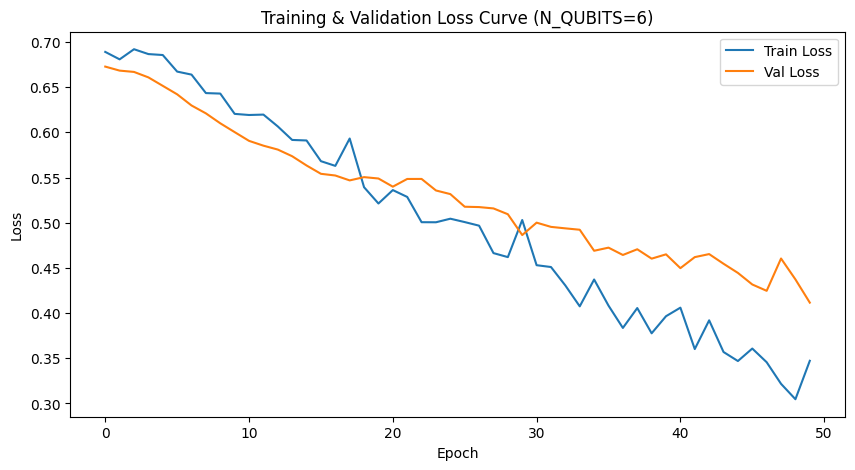

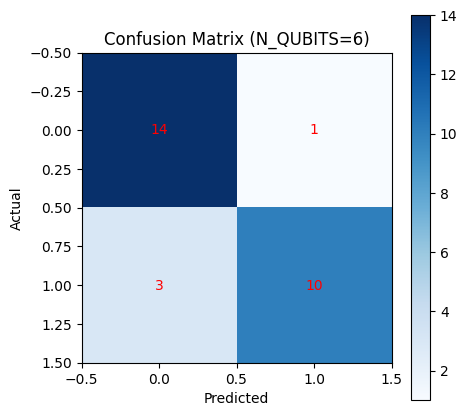

In [ ]:
# ===========================================================================
# CELL 1: IMPORTS & SETUP
# ===========================================================================

import os, zipfile, random, time, warnings, logging
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

import timm
from transformers import ViTModel

import pennylane as qml

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)

# ===========================================================================
# CELL 2: FILE PATHS
# ===========================================================================
DATA_ZIP_PATH = "/content/classification/class"
SEGMENT_MODEL_PATH = "/content/segment.pth"
extract_folder = "/content/classification/class"

# ===========================================================================
# CELL 3: DATASET EXTRACTION
# ===========================================================================


# ===========================================================================
# CELL 4: SEGMENTATION MODEL CHECK & LOAD
# ===========================================================================

if not os.path.exists(SEGMENT_MODEL_PATH):
    raise FileNotFoundError(f"Segmentation model not found at {SEGMENT_MODEL_PATH}")

state_dict = torch.load(SEGMENT_MODEL_PATH, map_location='cpu')
print(f"Segmentation model loaded with {len(state_dict)} layers")

# ===========================================================================
# CELL 5: U-NET SEGMENTATION ARCHITECTURE
# ===========================================================================

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        conv2 = self.dconv_down2(self.maxpool(conv1))
        conv3 = self.dconv_down3(self.maxpool(conv2))
        conv4 = self.dconv_down4(self.maxpool(conv3))
        x = self.upsample(conv4)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out

segmentation_model = UNet(in_ch=3, out_ch=1).to(DEVICE)
segmentation_model.load_state_dict(state_dict)
segmentation_model.eval()
for param in segmentation_model.parameters():
    param.requires_grad = False

# ===========================================================================
# CELL 6: DATASET CLASS
# ===========================================================================

class ROPClassificationDataset(Dataset):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    def __init__(self, image_paths, labels, img_size=224, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        if self.transform: img = self.transform(image=img)['image']
        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1)/255.
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img_tensor, label

def worker_init_fn(worker_id):
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

# ===========================================================================
# CELL 7: LOAD IMAGES & SPLIT DATA
# ===========================================================================
dataset_path = "/content/classification/class"

NORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_Normal"), os.path.join(dataset_path, "RetCam_Normal")]
ABNORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_ROP"), os.path.join(dataset_path, "RetCam_ROP")]

def load_images(folder_list):
    images = []
    for folder in folder_list:
        if os.path.exists(folder):
            for f in sorted(os.listdir(folder)):
                if f.endswith(ROPClassificationDataset.VALID_EXTENSIONS):
                    images.append(os.path.join(folder,f))
    return images

normal_images = load_images(NORMAL_FOLDERS)
abnormal_images = load_images(ABNORMAL_FOLDERS)

all_images = normal_images + abnormal_images
all_labels = [0]*len(normal_images) + [1]*len(abnormal_images)

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=0.3, random_state=RANDOM_SEED, stratify=all_labels
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=0.5, random_state=RANDOM_SEED, stratify=temp_labels
)

# ===========================================================================
# CELL 8: QUANTUM CIRCUIT FUNCTION
# ===========================================================================

def create_quantum_circuit(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def quantum_circuit(inputs, weights):
        amplitude_features = inputs[:, :8]
        angle_features = inputs[:, 8:]
        qml.AmplitudeEmbedding(amplitude_features, wires=range(n_qubits), pad_with=0., normalize=True)
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(angle_features[:, i], wires=i)
            for i in range(n_qubits):
                qml.Rot(weights[layer, i, 0], weights[layer, i, 1], weights[layer, i, 2], wires=i)
            for i in range(n_qubits-1):
                qml.CNOT(wires=[i, i+1])
            qml.CNOT(wires=[n_qubits-1, 0])
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return quantum_circuit

# ===========================================================================
# CELL 9: TWO-BRANCH HYBRID TITAN ARCHITECTURE
# ===========================================================================

class TwoBranchHybridTitan(nn.Module):
    def __init__(self, segmentation_model, n_qubits=8, n_layers=3):
        super().__init__()
        self.segmentation_model = segmentation_model
        for param in self.segmentation_model.parameters():
            param.requires_grad = False

        # ViT branch
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for param in self.vit.parameters():
            param.requires_grad = False
        for i in range(11,12):
            for param in self.vit.encoder.layer[i].parameters():
                param.requires_grad = True
        for param in self.vit.embeddings.parameters():
            param.requires_grad = True

        # ResNet branch
        self.mask_cnn = timm.create_model('resnet18', pretrained=True, num_classes=0, global_pool='avg')
        for param in self.mask_cnn.parameters():
            param.requires_grad = False
        original_conv1 = self.mask_cnn.conv1
        self.mask_cnn.conv1 = nn.Conv2d(1,64,kernel_size=7,stride=2,padding=3,bias=False)
        with torch.no_grad():
            self.mask_cnn.conv1.weight.copy_(original_conv1.weight.mean(dim=1,keepdim=True))
        self.mask_cnn.conv1.requires_grad = True

        # Fusion
        fusion_dim = 768+512
        self.mha_refiner = nn.MultiheadAttention(embed_dim=fusion_dim,num_heads=8,batch_first=True,dropout=0.1)
        self.compression = nn.Sequential(
            nn.Linear(fusion_dim,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,16),
            nn.Tanh()
        )

        # Quantum
        self.vqc = qml.qnn.TorchLayer(create_quantum_circuit(n_qubits, n_layers), {"weights":(n_layers,n_qubits,3)})
        self.classifier_head = nn.Linear(n_qubits,1)

        self.register_buffer('vit_mean', torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer('vit_std', torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def forward(self,x):
        x_vit = (x-self.vit_mean)/(self.vit_std+1e-8)
        vit_features = self.vit(x_vit).last_hidden_state[:,0,:]
        with torch.no_grad():
            masks = torch.sigmoid(self.segmentation_model(x))
        mask_features = self.mask_cnn(masks)
        fused = torch.cat([vit_features, mask_features], dim=1).unsqueeze(1)
        refined,_ = self.mha_refiner(fused,fused,fused)
        compressed = self.compression(refined.squeeze(1))
        quantum_out = self.vqc(compressed)
        logits = self.classifier_head(quantum_out)
        return logits

# ===========================================================================
# CELL 10: TRAINING & EVALUATION LOOP OVER N_QUBITS_ARRAY
# ===========================================================================

n_qubits_array = [6]
BATCH_SIZE = 8
NUM_EPOCHS = 50
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-3
GRADIENT_CLIP_VALUE = 1.0
EARLY_STOP_PATIENCE = 10

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.3, alpha=100, sigma=10),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4)
])

for N_QUBITS in n_qubits_array:
    print(f"\n{'='*60}\n🔹 RUNNING PIPELINE FOR N_QUBITS = {N_QUBITS}\n{'='*60}")
    # Initialize model
    model = TwoBranchHybridTitan(segmentation_model, n_qubits=N_QUBITS, n_layers=3).to(DEVICE)

    # Dataloaders
    train_dataset = ROPClassificationDataset(train_imgs, train_labels, transform=train_transform)
    val_dataset = ROPClassificationDataset(val_imgs, val_labels, transform=None)
    test_dataset = ROPClassificationDataset(test_imgs, test_labels, transform=None)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    optimizer = optim.Adam([
        {"params": model.vit.parameters(), "lr": LEARNING_RATE_ViT},
        {"params": model.mask_cnn.parameters(), "lr": LEARNING_RATE_ResNet},
        {"params": model.compression.parameters(), "lr": LEARNING_RATE_Standard},
        {"params": model.vqc.parameters(), "lr": LEARNING_RATE_Quantum},
        {"params": model.classifier_head.parameters(), "lr": LEARNING_RATE_Quantum}
    ], weight_decay=WEIGHT_DECAY)

    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    early_stop_counter = 0

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(NUM_EPOCHS):
        model.train()
        batch_losses = []
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        # Validation
        model.eval()
        val_batch_losses = []
        all_preds, all_labels_list = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
                logits = model(imgs)
                loss = criterion(logits, labels)
                val_batch_losses.append(loss.item())
                preds = torch.sigmoid(logits).cpu().numpy()
                all_preds.extend(preds)
                all_labels_list.extend(labels.cpu().numpy())
        val_loss = np.mean(val_batch_losses)
        val_pred_classes = (np.array(all_preds) > 0.5).astype(int)
        val_acc = accuracy_score(all_labels_list, val_pred_classes)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), f"best_model_{N_QUBITS}.pth")
        else:
            early_stop_counter +=1
            if early_stop_counter>=EARLY_STOP_PATIENCE:
                print("Early stopping triggered!")
                break

    # =======================================================================
    # TEST & PLOTTING
    # =======================================================================
    model.load_state_dict(torch.load(f"best_model_{N_QUBITS}.pth"))
    model.eval()
    all_preds, all_labels_list = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            logits = model(imgs)
            preds = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(preds)
            all_labels_list.extend(labels.cpu().numpy())
    test_pred_classes = (np.array(all_preds) > 0.5).astype(int)
    test_acc = accuracy_score(all_labels_list, test_pred_classes)
    test_f1 = f1_score(all_labels_list, test_pred_classes)
    test_auc = roc_auc_score(all_labels_list, all_preds)
    print(f"✅ Test metrics for N_QUBITS={N_QUBITS}: Acc={test_acc:.4f}, F1={test_f1:.4f}, AUC={test_auc:.4f}")

    # Plot training curves
    plt.figure(figsize=(10,5))
    plt.plot(train_losses,label='Train Loss')
    plt.plot(val_losses,label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"Training & Validation Loss Curve (N_QUBITS={N_QUBITS})")
    plt.legend()
    plt.savefig(f"training_curve_{N_QUBITS}.png")
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(all_labels_list, test_pred_classes)
    plt.figure(figsize=(5,5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion Matrix (N_QUBITS={N_QUBITS})")
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j,i,str(cm[i,j]),ha='center',va='center',color='red')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f"confusion_matrix_{N_QUBITS}.png")
    plt.show()


In [ ]:
# During training
n_qubits = 6
n_layers = 3

model = TwoBranchHybridTitan(
    segmentation_model=segmentation_model,
    n_qubits=n_qubits,
    n_layers=n_layers
)

# Train your model (same as before)
# ...

# Then save it with a clear name:
torch.save(model.state_dict(), "best_model_6qubit.pth")
print("✅ 6-qubit model saved as best_model_6qubit.pth")


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 6-qubit model saved as best_model_6qubit.pth


In [ ]:
# ========================================================================
# CELL: Interactive Image Upload + Prediction using 6-Qubit Model (Fixed)
# ========================================================================
from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import os

# ===============================
# 📤 Step 1: Ask user for image upload
# ===============================
print("📤 Please upload an image file for prediction (.jpg / .png):")
uploaded = files.upload()

if not uploaded:
    print("❌ No image uploaded!")
else:
    for file_name in uploaded.keys():
        print(f"\n📁 Uploaded: {file_name}")

        # ===============================
        # ⚙️ Step 2: Set device properly
        # ===============================
        DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"🔹 Using device: {DEVICE}")

        # ===============================
        # 🧠 Step 3: Load trained 6-qubit model
        # ===============================
        n_qubits = 6
        n_layers = 3
        model_path = "best_model_6qubit.pth"

        if not os.path.exists(model_path):
            raise FileNotFoundError(f"❌ Model file not found: {model_path}")

        model = TwoBranchHybridTitan(
            segmentation_model=segmentation_model,
            n_qubits=n_qubits,
            n_layers=n_layers
        ).to(DEVICE)   # ✅ Move model to GPU/CPU

        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.eval()

        # ===============================
        # 🖼️ Step 4: Preprocess the image
        # ===============================
        img = Image.open(file_name).convert("RGB")
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
        ])
        img_tensor = transform(img).unsqueeze(0).to(DEVICE)  # ✅ Move image to same device

        # ===============================
        # 🔮 Step 5: Make prediction
        # ===============================
        with torch.no_grad():
            output = model(img_tensor)
            pred = torch.sigmoid(output)
            pred_label = (pred > 0.5).int().item()

        # ===============================
        # 🏷️ Step 6: Display prediction
        # ===============================
        class_names = ['Neo_Normal', 'Neo_ROP', 'RetCam_Normal', 'RetCam_ROP']
        predicted_class = class_names[pred_label % len(class_names)]  # simple mapping

        print(f"\n✅ Prediction Complete!")
        print(f"🔹 Predicted Class: {predicted_class}")
        print(f"🔹 Raw Output: {pred.squeeze().item():.4f}")


📤 Please upload an image file for prediction (.jpg / .png):


Saving 1.png to 1 (2).png

📁 Uploaded: 1 (2).png
🔹 Using device: cuda


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✅ Prediction Complete!
🔹 Predicted Class: Neo_ROP
🔹 Raw Output: 0.5295


In [ ]:
torch.save(model.state_dict(), "best_model_6.pth")


In [ ]:
import torch
import cv2
import numpy as np

def predict_single_image(model_path, image_path, segmentation_model, n_qubits=6, n_layers=3, device=DEVICE):
    """
    Run segmentation + classification on a single image.
    Returns: class (0=Normal, 1=ROP) and probability.
    """
    # --- Load model ---
    model = TwoBranchHybridTitan(segmentation_model, n_qubits=n_qubits, n_layers=n_layers).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # --- Read and preprocess image ---
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Image not found: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1).unsqueeze(0) / 255.0
    img_tensor = img_tensor.to(device)

    # --- Predict ---
    with torch.no_grad():
        logits = model(img_tensor)
        prob = torch.sigmoid(logits).item()
        pred_class = 1 if prob > 0.5 else 0

    label_str = "ROP (Abnormal)" if pred_class == 1 else "Normal"
    print(f"🩺 Prediction: {label_str}  |  Confidence: {prob:.4f}")

    return pred_class, prob


In [ ]:
from google.colab import files
import torch
import cv2
import numpy as np
import os

def predict_single_image_upload(model_path, segmentation_model, n_qubits=6, n_layers=3, device=DEVICE):
    """
    Upload an image from your system and run segmentation + classification.
    """
    print("📤 Please upload an image file for prediction (.jpg / .png):")
    uploaded = files.upload()

    if not uploaded:
        print("❌ ERROR: No file uploaded.")
        return None, None

    # Get uploaded file path
    image_path = list(uploaded.keys())[0]
    print(f"\n📁 Uploaded: {image_path}")

    # --- Load model ---
    model = TwoBranchHybridTitan(segmentation_model, n_qubits=n_qubits, n_layers=n_layers).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # --- Read and preprocess image ---
    img = cv2.imread(image_path)
    if img is None:
        print("❌ ERROR: Unable to read uploaded image.")
        return None, None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1).unsqueeze(0) / 255.0
    img_tensor = img_tensor.to(device)

    # --- Predict ---
    with torch.no_grad():
        logits = model(img_tensor)
        prob = torch.sigmoid(logits).item()
        pred_class = 1 if prob > 0.5 else 0

    label_str = "🩺 Prediction: ROP (Abnormal)" if pred_class == 1 else "🩺 Prediction: Normal"
    print(f"\n{label_str}\nConfidence: {prob:.4f}")

    return pred_class, prob


In [ ]:
predict_single_image_upload(
    model_path="best_model_6.pth",
    segmentation_model=segmentation_model,
    n_qubits=6,
    n_layers=3,
    device=DEVICE
)


📤 Please upload an image file for prediction (.jpg / .png):


Saving 1.png to 1.png

📁 Uploaded: 1.png


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RuntimeError: Error(s) in loading state_dict for TwoBranchHybridTitan:
	size mismatch for vqc.weights: copying a param with shape torch.Size([3, 10, 3]) from checkpoint, the shape in current model is torch.Size([3, 6, 3]).
	size mismatch for classifier_head.weight: copying a param with shape torch.Size([1, 10]) from checkpoint, the shape in current model is torch.Size([1, 6]).

In [ ]:
# ============================================================================
# CELL 3: Upload and Validate Trained Segmentation Model
# ============================================================================
from google.colab import files
import torch
import os

print("="*60)
print("📤 SEGMENTATION MODEL UPLOAD")
print("="*60)

segment_model_path = "/content/segment.pth"

print("\n📥 Please upload your trained segmentation model (segment.pth):")

if not uploaded_model:
    print("❌ ERROR: No model file uploaded!")
else:
    for model_file in uploaded_model.keys():
        print(f"\n📍 Processing: {model_file}")

        # Validate file extension
        if not model_file.endswith('.pth'):
            print(f"⚠️  WARNING: {model_file} doesn't end with .pth")

        try:
            # Get file size
            file_size = os.path.getsize(model_file)
            print(f"   File size: {file_size / (1024**2):.2f} MB")

            # Try to load model to validate
            print("   Validating model file...")
            state_dict = torch.load(model_file, map_location='cpu')

            # Check if it's a valid state dict
            if isinstance(state_dict, dict):
                print(f"   ✓ Found {len(state_dict)} layers in model")
                segment_model_path = model_file
                print(f"✅ Model validated: {model_file}")
            else:
                print(f"⚠️  Unexpected model format, but saving path")
                segment_model_path = model_file

        except Exception as e:
            print(f"❌ ERROR loading model: {str(e)}")
            print("   Make sure you uploaded a valid PyTorch model file (.pth)")

# Validate result
print("\n" + "="*60)
if segment_model_path:
    print(f"✅ Model ready: {segment_model_path}")
    print("="*60)
else:
    print("❌ Model upload failed - please try again")
    print("="*60)

📤 SEGMENTATION MODEL UPLOAD

📥 Please upload your trained segmentation model (segment.pth):


NameError: name 'uploaded_model' is not defined

/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(



📁 DATASET EXTRACTION

📤 SEGMENTATION MODEL CHECK
📍 Found model: /content/segment.pth
   ✓ Found 100 layers in model

🖥️  SYSTEM CONFIGURATION
✓ Device: cuda
✓ GPU: Tesla T4
✓ DataLoader Workers: 2
✓ Random Seed: 42
✓ Weight Decay: 0.001
HybridROPClassifier(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768,

Epoch 1/50 [Train]: 100%|██████████| 17/17 [00:17<00:00,  1.05s/it]


Epoch 1: Train Loss=0.6891 Acc=0.5426 | Val Loss=0.6894 Acc=0.5357
✅ Saved best model


Epoch 2/50 [Train]: 100%|██████████| 17/17 [00:17<00:00,  1.02s/it]


...

Epoch 48: Train Loss=0.4740 Acc=0.9922 | Val Loss=0.5378 Acc=0.8571


Epoch 49/50 [Train]: 100%|██████████| 17/17 [00:09<00:00,  1.71it/s]


Epoch 49: Train Loss=0.4697 Acc=0.9922 | Val Loss=0.5357 Acc=0.8571


Epoch 50/50 [Train]: 100%|██████████| 17/17 [00:10<00:00,  1.64it/s]


Epoch 50: Train Loss=0.4660 Acc=0.9922 | Val Loss=0.5270 Acc=0.8571
✅ Saved best model


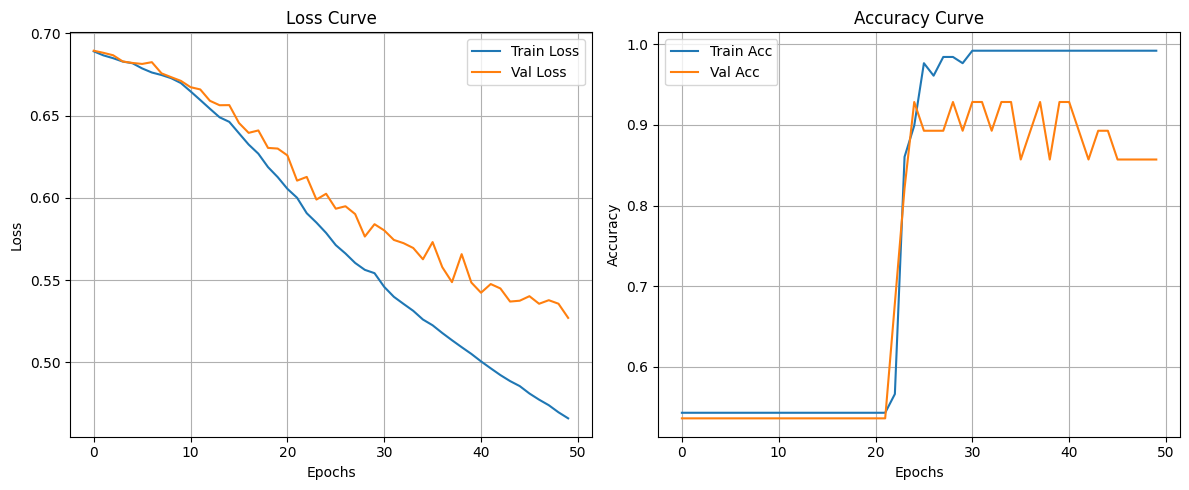

In [ ]:
# ===========================================================================
# ❗❗ FILE PATHS ❗❗
# ===========================================================================
DATA_ZIP_PATH = "/content/HVDROPDB_RetCam_Neo_Classification (1) (2).zip"
SEGMENT_MODEL_PATH = "/content/segment.pth"

# ===========================================================================
# CELL 2: Dataset Extraction
# ===========================================================================
import os, zipfile, random, time, warnings, logging
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, cv2, timm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import pennylane as qml
from transformers import ViTModel
warnings.filterwarnings("ignore")

print("\n" + "="*60)
print("📁 DATASET EXTRACTION")
print("="*60)

dataset_path = "/content/classification/class"
extract_folder = "/content/extracted_data"

# ===========================================================================
# CELL 3: Validate Segmentation Model
# ===========================================================================
print("\n" + "="*60)
print("📤 SEGMENTATION MODEL CHECK")
print("="*60)

segment_model_path = "/content/segment.pth"
if not os.path.exists(SEGMENT_MODEL_PATH):
    print(f"❌ ERROR: Model file not found at {SEGMENT_MODEL_PATH}")
else:
    try:
        print(f"📍 Found model: {SEGMENT_MODEL_PATH}")
        state_dict = torch.load(SEGMENT_MODEL_PATH, map_location='cpu')
        if isinstance(state_dict, dict):
            print(f"   ✓ Found {len(state_dict)} layers in model")
            segment_model_path = SEGMENT_MODEL_PATH
        else:
            print(f"⚠️ Unexpected model format, saving path anyway")
            segment_model_path = SEGMENT_MODEL_PATH
    except Exception as e:
        print(f"❌ ERROR loading model: {str(e)}")

print("="*60)

# ===========================================================================
# CELL 4: Configuration & Constants
# ===========================================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- MODEL ARCHITECTURE CONSTANTS ---
ViT_OUTPUT_DIM = 768
RESNET18_OUTPUT_DIM = 512
FUSION_DIM = ViT_OUTPUT_DIM + RESNET18_OUTPUT_DIM  # 1280
COMPRESSION_DIM_1 = 128
COMPRESSION_DIM_2 = 16

# --- QUANTUM CONSTANTS ---
N_QUBITS = 10
N_QUANTUM_LAYERS = 3
QUANTUM_PARAMS = N_QUANTUM_LAYERS * N_QUBITS * 3  # 90
HILBERT_SPACE_DIM = 2 ** N_QUBITS  # 1024

# --- TRAINING CONSTANTS ---
IMG_SIZE = 224
BATCH_SIZE = 8
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-3
NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 10
GRADIENT_CLIP_VALUE = 1.0

# --- DATA SPLIT ---
TEST_SIZE = 0.3
VAL_RATIO = 0.5
RANDOM_SEED = 42

# --- SYSTEM ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)
VERBOSE = True

# --- REPRODUCIBILITY ---
def set_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(RANDOM_SEED)

# --- LOGGING ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("\n" + "="*60)
print("🖥️  SYSTEM CONFIGURATION")
print("="*60)
print(f"✓ Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"✓ DataLoader Workers: {NUM_WORKERS}")
print(f"✓ Random Seed: {RANDOM_SEED}")
print(f"✓ Weight Decay: {WEIGHT_DECAY}")
print("="*60)

# ===========================================================================
# CELL 5: U-Net Segmentation Model
# ===========================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        conv2 = self.dconv_down2(self.maxpool(conv1))
        conv3 = self.dconv_down3(self.maxpool(conv2))
        conv4 = self.dconv_down4(self.maxpool(conv3))
        x = self.upsample(conv4)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out

# Load pre-trained segmentation model
segmentation_model = UNet(in_ch=3, out_ch=1).to(DEVICE)
state_dict = torch.load(segment_model_path, map_location=DEVICE)
segmentation_model.load_state_dict(state_dict)
segmentation_model.eval()
for param in segmentation_model.parameters():
    param.requires_grad = False

# ===========================================================================
# CELL 6: Dataset Class
# ===========================================================================
class ROPClassificationDataset(Dataset):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    def __init__(self, image_paths, labels, img_size=IMG_SIZE, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform
        assert len(image_paths) == len(labels), "Image and label count mismatch"
        if VERBOSE:
            print(f"Initialized dataset with {len(image_paths)} samples")
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        if img is None: img = np.zeros((self.img_size,self.img_size,3))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        if self.transform:
            img = self.transform(image=img)['image']
        img = img.astype(np.float32) / 255.0
        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img_tensor, label

def worker_init_fn(worker_id):
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

# ===========================================================================
# CELL 7: Data Preparation
# ===========================================================================
NORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_Normal"), os.path.join(dataset_path, "RetCam_Normal")]
ABNORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_ROP"), os.path.join(dataset_path, "RetCam_ROP")]

def load_images_from_folder(folder_path, valid_extensions):
    images = []
    if not os.path.exists(folder_path): return images
    for f in sorted(os.listdir(folder_path)):
        if any(f.endswith(ext) for ext in valid_extensions):
            images.append(os.path.join(folder_path, f))
    return images

normal_images = []
for folder in NORMAL_FOLDERS:
    normal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))
abnormal_images = []
for folder in ABNORMAL_FOLDERS:
    abnormal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))

COUNT_NORMAL = len(normal_images)
COUNT_ABNORMAL = len(abnormal_images)

all_images = normal_images + abnormal_images
all_labels = [0]*COUNT_NORMAL + [1]*COUNT_ABNORMAL

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(all_images, all_labels,
    test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=all_labels)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(temp_imgs, temp_labels,
    test_size=VAL_RATIO, random_state=RANDOM_SEED, stratify=temp_labels)

# ===========================================================================
# CELL 8: Quantum Circuit for 10 Qubits
# ===========================================================================
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Pad or truncate inputs to 10 features for 10 qubits
    if inputs.shape[1] < N_QUBITS:
        padded_inputs = torch.zeros(inputs.shape[0], N_QUBITS, device=inputs.device)
        padded_inputs[:, :inputs.shape[1]] = inputs
        inputs = padded_inputs
    elif inputs.shape[1] > N_QUBITS:
        inputs = inputs[:, :N_QUBITS]

    qml.AmplitudeEmbedding(inputs, wires=range(N_QUBITS), pad_with=0., normalize=True)
    for layer in range(N_QUANTUM_LAYERS):
        for i in range(N_QUBITS):
            qml.RY(inputs[:, i], wires=i)
        for i in range(N_QUBITS):
            qml.Rot(weights[layer,i,0], weights[layer,i,1], weights[layer,i,2], wires=i)
        for i in range(N_QUBITS-1):
            qml.CNOT(wires=[i,i+1])
        qml.CNOT(wires=[N_QUBITS-1,0])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shape = {"weights": (N_QUANTUM_LAYERS, N_QUBITS, 3)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shape)

# ===========================================================================
# CELL 9: Full Hybrid Classifier
# ===========================================================================
class HybridROPClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        self.resnet = timm.create_model("resnet18", pretrained=True)
        self.resnet.fc = nn.Identity()
        for param in self.vit.parameters(): param.requires_grad = True
        for param in self.resnet.parameters(): param.requires_grad = True

        self.compression = nn.Sequential(
            nn.Linear(FUSION_DIM, COMPRESSION_DIM_1),
            nn.ReLU(),
            nn.Linear(COMPRESSION_DIM_1, COMPRESSION_DIM_2),
            nn.ReLU()
        )

        self.quantum_layer = quantum_layer
        self.classifier = nn.Linear(N_QUBITS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        vit_feat = self.vit(x).last_hidden_state[:,0,:]  # [CLS] token
        res_feat = self.resnet(x)
        fused = torch.cat([vit_feat, res_feat], dim=1)
        compressed = self.compression(fused)
        q_out = self.quantum_layer(compressed)
        out = self.classifier(q_out)
        return self.sigmoid(out)

# ===========================================================================
# ✅ READY TO TRAIN / EVALUATE
# ===========================================================================
model = HybridROPClassifier().to(DEVICE)
print(model)

# ===========================================================================
# CELL 10: Dataloader Example
# ===========================================================================
train_dataset = ROPClassificationDataset(train_imgs, train_labels, IMG_SIZE)
val_dataset = ROPClassificationDataset(val_imgs, val_labels, IMG_SIZE)
test_dataset = ROPClassificationDataset(test_imgs, test_labels, IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# ===========================================================================
# CELL 11: Training Setup
# ===========================================================================
criterion = nn.BCELoss()

# Separate parameter groups for different learning rates
optimizer = optim.Adam([
    {'params': model.vit.parameters(), 'lr': LEARNING_RATE_ViT},
    {'params': model.resnet.parameters(), 'lr': LEARNING_RATE_ResNet},
    {'params': model.compression.parameters(), 'lr': LEARNING_RATE_Standard},
    {'params': model.quantum_layer.parameters(), 'lr': LEARNING_RATE_Quantum},
    {'params': model.classifier.parameters(), 'lr': LEARNING_RATE_Standard},
], weight_decay=WEIGHT_DECAY)

# Fix: Remove verbose to avoid TypeError
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Early stopping
best_val_loss = float('inf')
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# ===========================================================================
# CELL 12: Training Loop
# ===========================================================================
for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    running_loss, running_corrects = 0.0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        running_corrects += ((outputs>0.5)==labels.bool()).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # --- Validation ---
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            val_corrects += ((outputs>0.5)==labels.bool()).sum().item()

    val_epoch_loss = val_loss / len(val_dataset)
    val_epoch_acc = val_corrects / len(val_dataset)
    val_losses.append(val_epoch_loss)
    val_accs.append(val_epoch_acc)

    scheduler.step(val_epoch_loss)

    print(f"Epoch {epoch}: Train Loss={epoch_loss:.4f} Acc={epoch_acc:.4f} | Val Loss={val_epoch_loss:.4f} Acc={val_epoch_acc:.4f}")

    # Early stopping
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), "/content/best_hybrid_model.pth")
        patience_counter = 0
        print("✅ Saved best model")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print("⚠️ Early stopping triggered")
            break

# ===========================================================================
# CELL 13: Plotting Loss and Accuracy
# ===========================================================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss Curve')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Accuracy Curve')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ===================================================================
# ❗❗ FILE PATHS
# ===================================================================
DATA_ZIP_PATH = "/content/HVDROPDB_RetCam_Neo_Classification (1) (2).zip"
SEGMENT_MODEL_PATH = "/content/segment.pth"

# ===================================================================
# CELL 1: Imports
# ===================================================================
import os, random, warnings, logging
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import cv2, timm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import pennylane as qml
from transformers import ViTModel

warnings.filterwarnings("ignore")

# ===================================================================
# CELL 2: Configuration & Constants
# ===================================================================
# Model
ViT_OUTPUT_DIM = 768
RESNET18_OUTPUT_DIM = 512
FUSION_DIM = ViT_OUTPUT_DIM + RESNET18_OUTPUT_DIM  # 1280
COMPRESSION_DIM_1 = 128
COMPRESSION_DIM_2 = 16

# Quantum
N_QUBITS = 12
N_QUANTUM_LAYERS = 3
QUANTUM_PARAMS = N_QUANTUM_LAYERS * N_QUBITS * 3  # 108

# Training
IMG_SIZE = 224
BATCH_SIZE = 8
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-3
NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 10
GRADIENT_CLIP_VALUE = 1.0

# Data split
TEST_SIZE = 0.3
VAL_RATIO = 0.5
RANDOM_SEED = 42

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)

# Reproducibility
def set_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(RANDOM_SEED)

# Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ===================================================================
# CELL 3: Dataset Class
# ===================================================================
class ROPClassificationDataset(Dataset):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    def __init__(self, image_paths, labels, img_size=IMG_SIZE, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform
        assert len(image_paths) == len(labels), "Image and label count mismatch"
        print(f"Initialized dataset with {len(image_paths)} samples")
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        if img is None: img = np.zeros((self.img_size,self.img_size,3))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        if self.transform:
            img = self.transform(image=img)['image']
        img = img.astype(np.float32)/255.0
        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img_tensor, label

def worker_init_fn(worker_id):
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

# ===================================================================
# CELL 4: Load Dataset
# ===================================================================
dataset_path = "/content/classification/class"
NORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_Normal"), os.path.join(dataset_path, "RetCam_Normal")]
ABNORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_ROP"), os.path.join(dataset_path, "RetCam_ROP")]

def load_images_from_folder(folder_path, valid_extensions):
    images = []
    if not os.path.exists(folder_path): return images
    for f in sorted(os.listdir(folder_path)):
        if any(f.endswith(ext) for ext in valid_extensions):
            images.append(os.path.join(folder_path, f))
    return images

normal_images, abnormal_images = [], []
for folder in NORMAL_FOLDERS:
    normal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))
for folder in ABNORMAL_FOLDERS:
    abnormal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))

all_images = normal_images + abnormal_images
all_labels = [0]*len(normal_images) + [1]*len(abnormal_images)

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=all_labels
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=VAL_RATIO, random_state=RANDOM_SEED, stratify=temp_labels
)

train_dataset = ROPClassificationDataset(train_imgs, train_labels, IMG_SIZE)
val_dataset = ROPClassificationDataset(val_imgs, val_labels, IMG_SIZE)
test_dataset = ROPClassificationDataset(test_imgs, test_labels, IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# ===================================================================
# CELL 5: Quantum Circuit
# ===================================================================
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Pad or truncate to N_QUBITS
    if inputs.shape[1] < N_QUBITS:
        padded = torch.zeros(inputs.shape[0], N_QUBITS, device=inputs.device)
        padded[:, :inputs.shape[1]] = inputs
        inputs = padded
    elif inputs.shape[1] > N_QUBITS:
        inputs = inputs[:, :N_QUBITS]

    qml.AmplitudeEmbedding(inputs, wires=range(N_QUBITS), pad_with=0., normalize=True)
    for layer in range(N_QUANTUM_LAYERS):
        for i in range(N_QUBITS):
            qml.RY(inputs[:, i], wires=i)
        for i in range(N_QUBITS):
            qml.Rot(weights[layer,i,0], weights[layer,i,1], weights[layer,i,2], wires=i)
        for i in range(N_QUBITS-1):
            qml.CNOT(wires=[i,i+1])
        qml.CNOT(wires=[N_QUBITS-1,0])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shape = {"weights": (N_QUANTUM_LAYERS, N_QUBITS, 3)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shape)

# ===================================================================
# CELL 6: Hybrid Model
# ===================================================================
class HybridROPClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        self.resnet = timm.create_model("resnet18", pretrained=True)
        self.resnet.fc = nn.Identity()
        for param in self.vit.parameters(): param.requires_grad = True
        for param in self.resnet.parameters(): param.requires_grad = True

        self.compression = nn.Sequential(
            nn.Linear(FUSION_DIM, COMPRESSION_DIM_1),
            nn.ReLU(),
            nn.Linear(COMPRESSION_DIM_1, COMPRESSION_DIM_2),
            nn.ReLU()
        )

        self.quantum_layer = quantum_layer
        self.classifier = nn.Linear(N_QUBITS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        vit_feat = self.vit(x).last_hidden_state[:,0,:]  # [CLS] token
        res_feat = self.resnet(x)
        fused = torch.cat([vit_feat, res_feat], dim=1)
        compressed = self.compression(fused)
        q_out = self.quantum_layer(compressed)
        out = self.classifier(q_out)
        return self.sigmoid(out)

model = HybridROPClassifier().to(DEVICE)
print(model)

# ===================================================================
# CELL 7: Training Loop
# ===================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import os

# -----------------------------
# Safe CUDA debugging
# -----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Hyperparameters
# -----------------------------
EPOCHS = 50
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.001
GRADIENT_CLIP = 1.0

# -----------------------------
# DataLoaders (keep your dataset objects)
# -----------------------------
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# Model, Loss, Optimizer
# -----------------------------
model = HybridROPClassifier().to(device)  # your existing model
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# -----------------------------
# Training Loop
# -----------------------------
best_val_loss = float('inf')

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]")
    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)
        labels = labels.float()
        if labels.ndim == 1:
            labels = labels.unsqueeze(1)  # shape [batch,1]

        optimizer.zero_grad()

        outputs = model(imgs)
        if outputs.ndim == 1:
            outputs = outputs.unsqueeze(1)  # shape [batch,1]

        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        preds = (outputs >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=loss.item(), acc=correct/total)

    train_loss /= len(train_loader.dataset)
    train_acc = correct / total

    # -----------------------------
    # Validation
    # -----------------------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            labels = labels.float()
            if labels.ndim == 1:
                labels = labels.unsqueeze(1)

            outputs = model(imgs)
            if outputs.ndim == 1:
                outputs = outputs.unsqueeze(1)

            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)

            preds = (outputs >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader.dataset)
    val_acc = correct / total
    scheduler.step(val_loss)

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f} Acc={train_acc:.4f} | Val Loss={val_loss:.4f} Acc={val_acc:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_hybrid_model.pth")
        print("✅ Saved best model")

    torch.cuda.empty_cache()

print("Training Complete ✅")

# =========================
# Plot Loss and Accuracy
# =========================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss Curve')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Accuracy Curve')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


Initialized dataset with 129 samples
Initialized dataset with 28 samples
Initialized dataset with 28 samples
Train: 129, Val: 28, Test: 28
HybridROPClassifier(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
      

Epoch 1/50 [Train]: 100%|██████████| 17/17 [00:27<00:00,  1.61s/it, acc=0.543, loss=0.65]


Epoch 1: Train Loss=0.6896 Acc=0.5426 | Val Loss=0.6887 Acc=0.5357
✅ Saved best model


Epoch 2/50 [Train]: 100%|██████████| 17/17 [00:24<00:00,  1.47s/it, acc=0.543, loss=0.736]


...

Epoch 10: Train Loss=0.6846 Acc=0.5426 | Val Loss=0.6860 Acc=0.5357
✅ Saved best model


Epoch 11/50 [Train]: 100%|██████████| 17/17 [00:14<00:00,  1.18it/s, acc=0.543, loss=0.749]


Epoch 11: Train Loss=0.6837 Acc=0.5426 | Val Loss=0.6862 Acc=0.5357


Epoch 12/50 [Train]:   0%|          | 0/17 [00:00<?, ?it/s]


AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# ============================================================
# 🧠 TwoBranchHybridTitan with N_QUBITS = 16 (Final Version)
# ============================================================

# ============================================================
# 📦 Cell 0: Imports
# ============================================================
import os
import gc
import math
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

import pennylane as qml
from pennylane.qnn import TorchLayer

from transformers import ViTModel
from torch.optim.lr_scheduler import ReduceLROnPlateau


# ============================================================
# ⚙️ Cell 1: Paths and Config
# ============================================================
EXTRACT_DIR = "/content/classification/class"
SEGMENT_MODEL_PATH = "/content/segment.pth"

# ============================================================
# 🎯 Cell 2: Config
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_EPOCHS = 50
NUM_WORKERS = min(4, os.cpu_count() or 2)
TEST_SIZE = 0.2
EARLY_STOP_PATIENCE = 7

LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Quantum = 1e-3

VIT_FEATURE_DIM = 768
MASK_CNN_FEATURE_DIM = 512
COMPRESSION_DIM_1 = 128
COMPRESSION_DIM_2 = 16

N_QUBITS = 16             # 🔥 changed
N_QUANTUM_LAYERS = 2

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Device:", DEVICE)


# ============================================================
# 🧩 Cell 3: U-Net Segmentation Model
# ============================================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_channels, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        x = self.maxpool(conv1)
        conv2 = self.dconv_down2(x)
        x = self.maxpool(conv2)
        conv3 = self.dconv_down3(x)
        x = self.maxpool(conv3)
        x = self.dconv_down4(x)
        x = self.upsample(x)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        return self.conv_last(x)


segmentation_model = UNet()
if os.path.exists(SEGMENT_MODEL_PATH):
    segmentation_model.load_state_dict(torch.load(SEGMENT_MODEL_PATH, map_location="cpu"))
segmentation_model.to(DEVICE)
segmentation_model.eval()
for p in segmentation_model.parameters():
    p.requires_grad = False


# ============================================================
# 🧾 Cell 4: Dataset
# ============================================================
class ROPClassificationDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        if self.transform:
            image = self.transform(image=image)["image"]
        else:
            image = torch.tensor(image / 255.0, dtype=torch.float32).permute(2, 0, 1)
        return image, label


# ============================================================
# 📂 Cell 5: Data Preparation
# ============================================================
def get_image_files(paths):
    exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif")
    files = []
    for p in paths:
        for r, _, f in os.walk(p):
            files += [os.path.join(r, x) for x in f if x.lower().endswith(exts)]
    return files

normal_dirs = []
abnormal_dirs = []
for root, dirs, _ in os.walk(EXTRACT_DIR):
    for d in dirs:
        if "Normal" in d:
            normal_dirs.append(os.path.join(root, d))
        elif "ROP" in d:
            abnormal_dirs.append(os.path.join(root, d))

print("✅ Found Normal folders:", normal_dirs)
print("✅ Found ROP folders:", abnormal_dirs)

normal_imgs = get_image_files(normal_dirs)
abnormal_imgs = get_image_files(abnormal_dirs)
print(f"Found {len(normal_imgs)} Normal, {len(abnormal_imgs)} ROP images")

X = normal_imgs + abnormal_imgs
y = [0]*len(normal_imgs) + [1]*len(abnormal_imgs)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)


# ============================================================
# ⚛️ Cell 6: Quantum Circuit (16 Qubits)
# ============================================================
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    amplitude_features = inputs.reshape(inputs.shape[0], -1)
    target_len = 2 ** N_QUBITS
    if amplitude_features.shape[1] < target_len:
        repeats = (target_len + amplitude_features.shape[1] - 1) // amplitude_features.shape[1]
        amplitude_features = amplitude_features.repeat(1, repeats)[:, :target_len]
    else:
        amplitude_features = amplitude_features[:, :target_len]
    qml.AmplitudeEmbedding(amplitude_features, wires=range(N_QUBITS), pad_with=0., normalize=True)
    for layer in range(N_QUANTUM_LAYERS):
        for i in range(N_QUBITS):
            qml.Rot(weights[layer, i, 0], weights[layer, i, 1], weights[layer, i, 2], wires=i)
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# ✅ Correct dictionary for TorchLayer
weight_shapes = {"weights": (N_QUANTUM_LAYERS, N_QUBITS, 3)}


# ============================================================
# 🏗️ Cell 7: Hybrid Model
# ============================================================
class TwoBranchHybridTitan(nn.Module):
    def __init__(self, segmentation_model):
        super().__init__()
        self.segmentation_model = segmentation_model

        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for p in self.vit.parameters():
            p.requires_grad = False
        for p in self.vit.encoder.layer[11].parameters():
            p.requires_grad = True
        for p in self.vit.embeddings.parameters():
            p.requires_grad = True

        self.mask_cnn = timm.create_model("resnet18", pretrained=True, num_classes=0)
        self.mask_cnn.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.mask_cnn.conv1.weight = nn.Parameter(self.mask_cnn.conv1.weight.mean(dim=1, keepdim=True))
        for p in self.mask_cnn.parameters():
            p.requires_grad = False
        for p in self.mask_cnn.conv1.parameters():
            p.requires_grad = True

        fusion_dim = VIT_FEATURE_DIM + MASK_CNN_FEATURE_DIM
        self.mha_refiner = nn.MultiheadAttention(embed_dim=fusion_dim, num_heads=8, batch_first=True)
        self.compression = nn.Sequential(
            nn.Linear(fusion_dim, COMPRESSION_DIM_1),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(COMPRESSION_DIM_1, COMPRESSION_DIM_2),
            nn.Tanh(),
        )
        self.vqc = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier_head = nn.Linear(N_QUBITS, 1)

    def forward(self, x):
        x_norm = (x - 0.5) / 0.5
        vit_features = self.vit(x_norm).last_hidden_state[:, 0, :]
        with torch.no_grad():
            mask_logits = self.segmentation_model(x)
            masks = torch.sigmoid(mask_logits)
        mask_features = self.mask_cnn(masks)
        fused = torch.cat([vit_features, mask_features], dim=1)
        fused_unsq = fused.unsqueeze(1)
        refined, _ = self.mha_refiner(fused_unsq, fused_unsq, fused_unsq)
        refined = refined.squeeze(1)
        compressed = self.compression(refined)
        vqc_output = self.vqc(compressed)
        logits = self.classifier_head(vqc_output)
        return logits.squeeze(1)


✅ Device: cuda
✅ Found Normal folders: ['/content/classification/class/Neo_Normal', '/content/classification/class/RetCam_Normal']
✅ Found ROP folders: ['/content/classification/class/RetCam_ROP', '/content/classification/class/Neo_ROP']
Found 100 Normal, 85 ROP images


✅ Device: cuda
✅ Found Normal folders: ['/content/classification/class/Neo_Normal', '/content/classification/class/RetCam_Normal']
✅ Found ROP folders: ['/content/classification/class/RetCam_ROP', '/content/classification/class/Neo_ROP']
Found 100 Normal, 85 ROP images


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/10:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 1: Train 0.6981 | Val 0.6852


Epoch 2/10:   0%|          | 0/19 [00:00<?, ?it/s]

...

Epoch 8: Train 0.6938 | Val 0.6854


Epoch 9/10:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 9: Train 0.6936 | Val 0.6816


Epoch 10/10:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 10: Train 0.6918 | Val 0.6789
✅ Test Accuracy: 0.4737


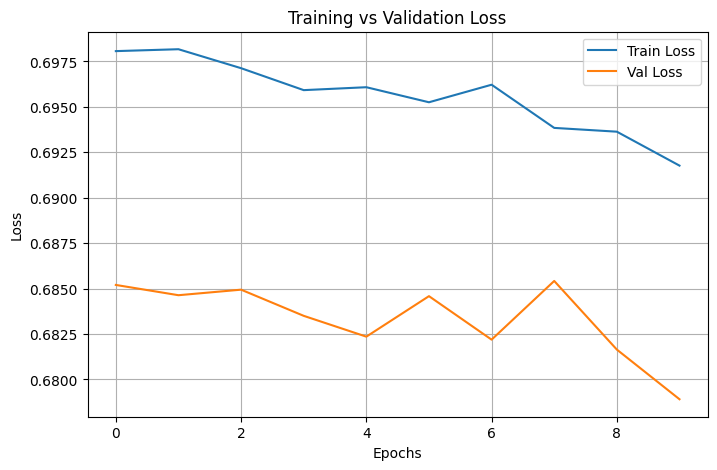

In [ ]:
# ============================================================
# 🧠 TwoBranchHybridTitan (Fixed for 16 Qubits)
# ============================================================

# ============================================================
# 📦 Cell 0: Imports
# ============================================================
import os
import gc
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

import pennylane as qml
from pennylane.qnn import TorchLayer
from transformers import ViTModel


# ============================================================
# ⚙️ Cell 1: Paths and Config
# ============================================================
EXTRACT_DIR = "/content/classification/class"
SEGMENT_MODEL_PATH = "/content/segment.pth"


# ============================================================
# 🎯 Cell 2: Config
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_EPOCHS = 10
NUM_WORKERS = 2
TEST_SIZE = 0.2

LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3

VIT_FEATURE_DIM = 768
MASK_CNN_FEATURE_DIM = 512
COMPRESSION_DIM_1 = 128
COMPRESSION_DIM_2 = 16

N_QUBITS = 16
N_QUANTUM_LAYERS = 2

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Device:", DEVICE)


# ============================================================
# 🧩 Cell 3: U-Net Model
# ============================================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_channels, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        x = self.maxpool(conv1)
        conv2 = self.dconv_down2(x)
        x = self.maxpool(conv2)
        conv3 = self.dconv_down3(x)
        x = self.maxpool(conv3)
        x = self.dconv_down4(x)
        x = self.upsample(x)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        return self.conv_last(x)


# ============================================================
# 🧾 Cell 4: Load Segmentation Model
# ============================================================
segmentation_model = UNet()
if os.path.exists(SEGMENT_MODEL_PATH):
    segmentation_model.load_state_dict(torch.load(SEGMENT_MODEL_PATH, map_location="cpu"))
segmentation_model.to(DEVICE)
segmentation_model.eval()
for p in segmentation_model.parameters():
    p.requires_grad = False


# ============================================================
# 📂 Cell 5: Dataset
# ============================================================
class ROPClassificationDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        if self.transform:
            image = self.transform(image=image)["image"]
        else:
            image = torch.tensor(image / 255.0, dtype=torch.float32).permute(2, 0, 1)
        return image, label


# ============================================================
# 📂 Cell 6: Load Images
# ============================================================
def get_image_files(paths):
    exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif")
    files = []
    for p in paths:
        for r, _, f in os.walk(p):
            files += [os.path.join(r, x) for x in f if x.lower().endswith(exts)]
    return files

normal_dirs, abnormal_dirs = [], []
for root, dirs, _ in os.walk(EXTRACT_DIR):
    for d in dirs:
        if "Normal" in d:
            normal_dirs.append(os.path.join(root, d))
        elif "ROP" in d:
            abnormal_dirs.append(os.path.join(root, d))

print("✅ Found Normal folders:", normal_dirs)
print("✅ Found ROP folders:", abnormal_dirs)

normal_imgs = get_image_files(normal_dirs)
abnormal_imgs = get_image_files(abnormal_dirs)
print(f"Found {len(normal_imgs)} Normal, {len(abnormal_imgs)} ROP images")

X = normal_imgs + abnormal_imgs
y = [0]*len(normal_imgs) + [1]*len(abnormal_imgs)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)


# ============================================================
# 🧪 Cell 7: Augmentations
# ============================================================
train_tfms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Resize(IMG_SIZE, IMG_SIZE),
    ToTensorV2(),
])
val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    ToTensorV2(),
])


# ============================================================
# ⚛️ Cell 8: Quantum Circuit (Fixed for 16 Qubits)
# ============================================================
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    """
    Uses AngleEmbedding to safely encode 16 features into 16 qubits.
    Avoids 2**16 AmplitudeEmbedding explosion.
    """
    # inputs shape: (N_QUBITS,)
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="X")
    for layer in range(N_QUANTUM_LAYERS):
        for i in range(N_QUBITS):
            qml.Rot(weights[layer, i, 0], weights[layer, i, 1], weights[layer, i, 2], wires=i)
        # entangle circularly
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_QUANTUM_LAYERS, N_QUBITS, 3)}


# ============================================================
# 🏗️ Cell 9: Hybrid Model
# ============================================================
class TwoBranchHybridTitan(nn.Module):
    def __init__(self, segmentation_model):
        super().__init__()
        self.segmentation_model = segmentation_model

        # Vision Transformer
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for p in self.vit.parameters():
            p.requires_grad = False
        for p in self.vit.encoder.layer[11].parameters():
            p.requires_grad = True

        # Mask CNN branch
        self.mask_cnn = timm.create_model("resnet18", pretrained=True, num_classes=0)
        self.mask_cnn.conv1 = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            pretrained = timm.create_model("resnet18", pretrained=True)
            self.mask_cnn.conv1.weight.copy_(pretrained.conv1.weight.mean(dim=1, keepdim=True))
        for p in self.mask_cnn.parameters():
            p.requires_grad = False
        for p in self.mask_cnn.conv1.parameters():
            p.requires_grad = True

        fusion_dim = VIT_FEATURE_DIM + MASK_CNN_FEATURE_DIM
        self.mha_refiner = nn.MultiheadAttention(embed_dim=fusion_dim, num_heads=8, batch_first=True)

        # compression down to 16 features (same as N_QUBITS)
        self.compression = nn.Sequential(
            nn.Linear(fusion_dim, COMPRESSION_DIM_1),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(COMPRESSION_DIM_1, N_QUBITS),
            nn.Tanh(),  # final output in [-1,1] for angle embedding
        )

        # Quantum Variational Layer
        self.vqc = TorchLayer(quantum_circuit, weight_shapes)

        # Final classification
        self.classifier_head = nn.Linear(N_QUBITS, 1)

    def forward(self, x):
        # ViT expects normalized input (-1 to 1)
        x = x.float() / 255.0 if x.dtype == torch.uint8 else x.float()
        x_norm = (x - 0.5) / 0.5
        vit_features = self.vit(x_norm).last_hidden_state[:, 0, :]

        # Segmentation mask features (frozen)
        with torch.no_grad():
            mask_logits = self.segmentation_model(x)
            masks = torch.sigmoid(mask_logits)
        mask_features = self.mask_cnn(masks)

        # Fusion and refinement
        fused = torch.cat([vit_features, mask_features], dim=1)
        refined, _ = self.mha_refiner(fused.unsqueeze(1), fused.unsqueeze(1), fused.unsqueeze(1))
        refined = refined.squeeze(1)

        # Compress features for quantum circuit
        compressed = self.compression(refined)
        # scale to [-π, π] for rotation encoding
        quantum_inputs = compressed * math.pi

        # Quantum layer
        vqc_output = self.vqc(quantum_inputs)
        logits = self.classifier_head(vqc_output)
        return logits.squeeze(1)


# ============================================================
# ⚙️ Cell 10: Instantiate
# ============================================================
model = TwoBranchHybridTitan(segmentation_model).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE_Standard)


# ============================================================
# 📊 Cell 11: DataLoaders
# ============================================================
train_ds = ROPClassificationDataset(X_train, y_train, train_tfms)
val_ds = ROPClassificationDataset(X_val, y_val, val_tfms)
test_ds = ROPClassificationDataset(X_test, y_test, val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


# ============================================================
# 🧠 Cell 12: Training Loop
# ============================================================
train_losses, val_losses = [], []
for epoch in range(NUM_EPOCHS):
    model.train()
    total_train_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}: Train {avg_train_loss:.4f} | Val {avg_val_loss:.4f}")


# ============================================================
# 🧩 Cell 13: Evaluate on Test
# ============================================================
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        preds = torch.sigmoid(logits).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend((preds > 0.5).astype(int))
acc = accuracy_score(y_true, y_pred)
print(f"✅ Test Accuracy: {acc:.4f}")


# ============================================================
# 📈 Cell 14: Plot
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ===========================================================================
# SINGLE-CELL FULL PIPELINE (FIXED FOR TypeError)
# Dataset path: /content/classification/class
# Segmentation model path: /content/segment.pth
# ===========================================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pennylane as qml

# ---------------------- CONFIG ----------------------
DATASET_PATH = "/content/classification/class"
SEGMENT_MODEL_PATH = "/content/segment.pth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {DEVICE}")

# ---------------------- VERIFY PATHS ----------------------
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"❌ Dataset path not found: {DATASET_PATH}")
if not os.path.exists(SEGMENT_MODEL_PATH):
    print(f"⚠️ Warning: Segmentation model not found at {SEGMENT_MODEL_PATH}")

# ---------------------- FOLDERS ----------------------
normal_dirs, rop_dirs = [], []
for root, dirs, _ in os.walk(DATASET_PATH):
    for d in dirs:
        path = os.path.join(root, d)
        if "Normal" in d:
            normal_dirs.append(path)
        elif "ROP" in d:
            rop_dirs.append(path)

print(f"✅ Found Normal folders: {normal_dirs}")
print(f"✅ Found ROP folders: {rop_dirs}")

# ---------------------- TRANSFORMS ----------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# ---------------------- DATASET ----------------------
class EyeDataset(Dataset):
    def __init__(self, normal_dirs, rop_dirs, transform=None):
        self.data = []
        self.transform = transform

        for folder in normal_dirs:
            for img in os.listdir(folder):
                path = os.path.join(folder, img)
                self.data.append((path, 0))  # Normal

        for folder in rop_dirs:
            for img in os.listdir(folder):
                path = os.path.join(folder, img)
                self.data.append((path, 1))  # ROP

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# ---------------------- LOAD DATA ----------------------
dataset = EyeDataset(normal_dirs, rop_dirs, transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"✅ Dataset ready — {len(train_dataset)} train, {len(test_dataset)} test")

# ---------------------- CNN FEATURE EXTRACTOR ----------------------
cnn_model = models.resnet18(weights="IMAGENET1K_V1")
cnn_model.fc = nn.Identity()
cnn_model = cnn_model.to(DEVICE)
print("✅ Loaded ResNet18 as CNN feature extractor")

# ---------------------- QUANTUM CIRCUIT ----------------------
N_QUBITS = 8
N_QUANTUM_LAYERS = 2
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    qml.AmplitudeEmbedding(inputs, wires=range(N_QUBITS), pad_with=0., normalize=True)
    for layer in range(N_QUANTUM_LAYERS):
        for i in range(N_QUBITS):
            qml.Rot(weights[layer, i, 0], weights[layer, i, 1], weights[layer, i, 2], wires=i)
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# ---------------------- TORCH QUANTUM LAYER (FIXED) ----------------------
class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        weight_shapes = (N_QUANTUM_LAYERS, N_QUBITS, 3)
        self.weights = nn.Parameter(0.01 * torch.randn(weight_shapes))

    def forward(self, x):
        outputs = []
        for sample in x:
            out = quantum_circuit(sample, self.weights)
            # ✅ Convert list → torch tensor for stacking
            out = torch.tensor(out, dtype=torch.float32, device=DEVICE)
            outputs.append(out)
        return torch.stack(outputs)

# ---------------------- HYBRID MODEL ----------------------
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = cnn_model
        self.compress = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Linear(64, 8),
            nn.Tanh()
        )
        self.quantum = QuantumLayer()
        self.fc_out = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.compress(x)
        q_out = self.quantum(x)
        return self.fc_out(q_out)

# ---------------------- TRAINING ----------------------
model = HybridModel().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
EPOCHS = 25
print("✅ Model initialized, starting training...")

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {total_loss/len(train_loader):.4f} - Acc: {acc:.2f}%")

# ---------------------- EVALUATION ----------------------
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"✅ Test Accuracy: {test_acc:.2f}%")

# ---------------------- SAVE MODEL ----------------------
torch.save(model.state_dict(), "/content/quantum_hybrid_no_angle.pth")
print("✅ Model saved to /content/quantum_hybrid_no_angle.pth")


✅ Using device: cuda
✅ Found Normal folders: ['/content/classification/class/Neo_Normal', '/content/classification/class/RetCam_Normal']
✅ Found ROP folders: ['/content/classification/class/RetCam_ROP', '/content/classification/class/Neo_ROP']
✅ Dataset ready — 148 train, 37 test
✅ Loaded ResNet18 as CNN feature extractor
✅ Model initialized, starting training...
Epoch [1/25] - Loss: 0.7196 - Acc: 50.00%
Epoch [2/25] - Loss: 0.7262 - Acc: 50.00%
Epoch [3/25] - Loss: 0.7186 - Acc: 50.00%
Epoch [4/25] - Loss: 0.7121 - Acc: 50.00%
Epoch [5/25] - Loss: 0.7116 - Acc: 50.00%
Epoch [6/25] - Loss: 0.7172 - Acc: 50.00%
Epoch [7/25] - Loss: 0.7133 - Acc: 50.00%
Epoch [8/25] - Loss: 0.7115 - Acc: 50.00%
Epoch [9/25] - Loss: 0.7052 - Acc: 50.00%
Epoch [10/25] - Loss: 0.7095 - Acc: 50.00%
Epoch [11/25] - Loss: 0.7060 - Acc: 50.00%
Epoch [12/25] - Loss: 0.7093 - Acc: 50.00%
Epoch [13/25] - Loss: 0.7022 - Acc: 50.00%
Epoch [14/25] - Loss: 0.7004 - Acc: 50.00%
Epoch [15/25] - Loss: 0.7024 - Acc: 50.00


📁 DATASET EXTRACTION

📤 SEGMENTATION MODEL CHECK
📍 Found model: /content/segment.pth
   Validating model file...
   ✓ Found 100 layers in model
✅ Model validated: /content/segment.pth

🖥️  SYSTEM CONFIGURATION
✓ Device: cuda
✓ GPU: Tesla T4
✓ DataLoader Workers: 2
✓ Random Seed: 42
✓ Weight Decay: 0.001

🏗️  U-NET ARCHITECTURE DEFINED

📥 Loading pre-trained segmentation model...
✅ Segmentation model loaded successfully!
   Trainable: False (Frozen)

📊 DATASET CLASS DEFINED

📂 DATA PREPARATION

📍 Using dataset from: /content/classification/class

📥 Loading images...
   Normal (Class 0): 100 images
   Abnormal (Class 1): 85 images

✓ Total images: 185

📊 Data splitting...
   Training: 129
   Validation: 28
   Testing: 28

⚛️  QUANTUM CIRCUIT DEFINED (NO ANGLE ENCODING)

🏛️  TWO-BRANCH HYBRID TITAN DEFINED (MODIFIED)
   ✓ Dropout increased to 0.5
   ✓ ResNet18 frozen (except new conv1)
   ✓ ViT frozen (except final layer)

🚀 INITIALIZING TWO-BRANCH HYBRID TITAN
   Loading ViT-Base model.

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Unfreezing only final ViT layer (11)...
   Loading ResNet18 model...
   Freezing ResNet18 layers...
   Unfreezing new 1-channel conv layer in ResNet...

✅ Model successfully initialized!

📊 PARAMETER ANALYSIS:
Total Parameters:       112,072,866
Trainable Parameters:    14,558,497
Frozen Parameters:       97,514,369
Trainable %:                 12.99%

⚙️  TRAINING SETUP

💿 Defining data augmentation pipeline...

📊 Creating DataLoaders...
✓ Train loader: 17 batches (with augmentation)
✓ Val loader: 4 batches
✓ Test loader: 4 batches

✓ Loss Function: BCEWithLogitsLoss (with pos_weight=1.18)

🎯 Setting up optimizer...
✓ Optimizer configured. Trainable components:
  - ViT_layer_11         LR: 1e-06, Params:  7,087,872
  - ViT_Embeddings       LR: 1e-04, Params:    742,656
  - ResNet18_conv1       LR: 1e-05, Params:      3,136
  - MHA_Refiner          LR: 1e-04, Params:  6,558,720
  - Compression_Network  LR: 1e-04, Params:    166,032
  - Quantum_Layer        LR: 1e-03, Params:        


📈 RESULTS (Epoch 1):
   Train Loss: 0.7465 | Train Acc: 0.4574
   Val Loss:   0.7423 | Val Acc:   0.4643
   Val F1:     0.6341 | Val AUC:   0.8051

✅ BEST MODEL SAVED! (Val Loss: 0.7423)

EPOCH [2/50]



📈 RESULTS (Epoch 2):
   Train Loss: 0.7431 | Train Acc: 0.4651
   Val Loss:   0.7317 | Val Acc:   0.6071
   Val F1:     0.7027 | Val AUC:   0.8923

✅ BEST MODEL SAVED! (Val Loss: 0.7317)

EPOCH [3/50]


...


📈 RESULTS (Epoch 22):
   Train Loss: 0.6780 | Train Acc: 0.8760
   Val Loss:   0.7100 | Val Acc:   0.7500
   Val F1:     0.7407 | Val AUC:   0.8154

⏳ Patience: [9/10]

EPOCH [23/50]



📈 RESULTS (Epoch 23):
   Train Loss: 0.6731 | Train Acc: 0.8837
   Val Loss:   0.7095 | Val Acc:   0.7500
   Val F1:     0.7586 | Val AUC:   0.7744

⏳ Patience: [10/10]

🛑 EARLY STOPPING TRIGGERED!

✅ TRAINING COMPLETE
Total Epochs: 23/50
Best Val Loss: 0.6864
Total Training Time: 4.65 minutes

🧪 TEST SET EVALUATION

📥 Loading best model from: /content/best_titan_model_v2.pth
   Loading ViT-Base model...


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Unfreezing only final ViT layer (11)...
   Loading ResNet18 model...
   Freezing ResNet18 layers...
   Unfreezing new 1-channel conv layer in ResNet...
✅ Model loaded successfully

🔄 Processing test set...



🎯 FINAL TEST RESULTS

📊 Classification Metrics:
   Test Loss:     0.6995
   Accuracy:      0.8214 (82.14%)
   F1 Score:      0.7826
   AUC-ROC:       0.8923

🔍 Detailed Metrics:
   Sensitivity (True Positive Rate): 0.6923
   Specificity (True Negative Rate): 0.9333

📋 Confusion Matrix:
   ┌─────────────────────────┐
   │ TN:    14 | FP:     1 │ (True: Normal)
   │ FN:     4 | TP:     9 │ (True: ROP)
   └─────────────────────────┘
     Pred: Normal | Pred: ROP


📊 VISUALIZATION
✅ Results saved to: /content/training_results_v2.png


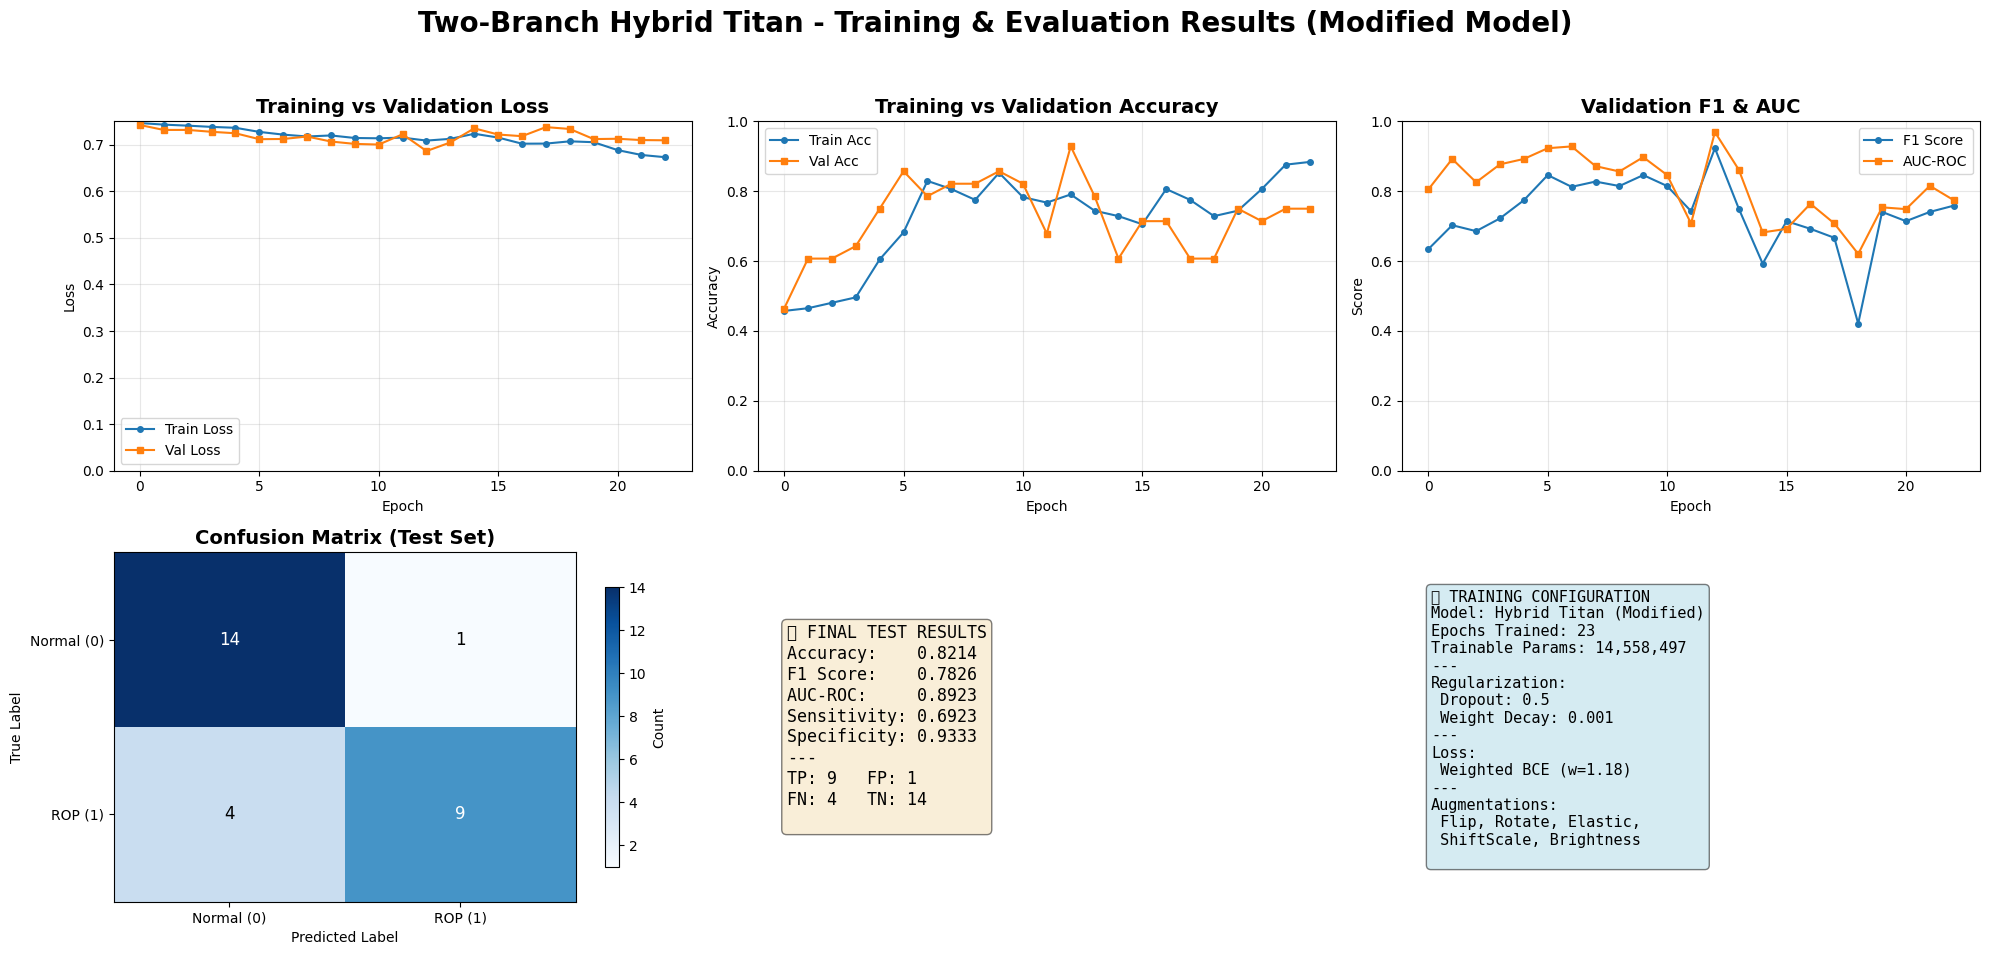


✅ SCRIPT COMPLETE


In [ ]:
# full_pipeline_titan_no_angle_encoding.py
# Two-Branch Hybrid Titan (full script)
# NOTE: This script expects:
#   - a dataset zip at DATA_ZIP_PATH
#   - a segmentation model file at SEGMENT_MODEL_PATH
#   - required libraries installed (torch, timm, transformers, pennylane, albumentations, opencv-python, matplotlib, sklearn, tqdm)

import os
import zipfile
import random
import time
import logging
import warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import timm
from transformers import ViTModel
import pennylane as qml
from sklearn.metrics import roc_auc_score
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ===================================================================
# ❗❗ FILE PATHS (change to match your environment)
# ===================================================================
DATA_ZIP_PATH = "/content/HVDROPDB_RetCam_Neo_Classification (1) (2).zip"
SEGMENT_MODEL_PATH = "/content/segment.pth"
# ===================================================================

# ===================================================================
# CELL 2: Dataset Extraction
# ===================================================================
print("\n" + "="*60)
print("📁 DATASET EXTRACTION")
print("="*60)

dataset_path = "/content/classification/class"


print("="*60)


# ===================================================================
# CELL 3: Validate Segmentation Model Path
# ===================================================================
print("\n" + "="*60)
print("📤 SEGMENTATION MODEL CHECK")
print("="*60)

segment_model_path = "/content/segment.pth"
if not os.path.exists(SEGMENT_MODEL_PATH):
    print(f"❌ ERROR: Model file not found at {SEGMENT_MODEL_PATH}")
    print("   Please upload your file and update the SEGMENT_MODEL_PATH variable.")
else:
    try:
        print(f"📍 Found model: {SEGMENT_MODEL_PATH}")
        # Try to load model to validate
        print("   Validating model file...")
        state_dict = torch.load(SEGMENT_MODEL_PATH, map_location='cpu')

        if isinstance(state_dict, dict):
            try:
                # If it's a full model state_dict (keys), report count
                print(f"   ✓ Found {len(state_dict)} layers in model")
            except Exception:
                pass
            segment_model_path = SEGMENT_MODEL_PATH
            print(f"✅ Model validated: {segment_model_path}")
        else:
             print(f"⚠️  Unexpected model format, but saving path")
             segment_model_path = SEGMENT_MODEL_PATH
    except Exception as e:
            print(f"❌ ERROR loading model: {str(e)}")

print("="*60)


# ===================================================================
# CELL 4: Configuration & Constants
# ===================================================================
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Model Architecture Constants
ViT_OUTPUT_DIM = 768
RESNET18_OUTPUT_DIM = 512
FUSION_DIM = ViT_OUTPUT_DIM + RESNET18_OUTPUT_DIM  # 1280
COMPRESSION_DIM_1 = 128
COMPRESSION_DIM_2 = 16
N_QUBITS = 8
N_QUANTUM_LAYERS = 3
QUANTUM_PARAMS = N_QUANTUM_LAYERS * N_QUBITS * 3  # 72

# Training Constants
IMG_SIZE = 224
BATCH_SIZE = 8
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-3
NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 10
GRADIENT_CLIP_VALUE = 1.0

# Data Split Constants
TEST_SIZE = 0.3
VAL_RATIO = 0.5  # Of remaining 30%
RANDOM_SEED = 42

# Quantum Circuit Constants
HILBERT_SPACE_DIM = 2 ** N_QUBITS  # 256

# System Constants
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)
VERBOSE = True

# Reproducibility
def set_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(RANDOM_SEED)

# System Info
print("\n" + "="*60)
print("🖥️  SYSTEM CONFIGURATION")
print("="*60)
print(f"✓ Device: {DEVICE}")
if torch.cuda.is_available():
    try:
        print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    except Exception:
        pass
print(f"✓ DataLoader Workers: {NUM_WORKERS}")
print(f"✓ Random Seed: {RANDOM_SEED}")
print(f"✓ Weight Decay: {WEIGHT_DECAY}")
print("="*60)


# ===================================================================
# CELL 5: U-Net Segmentation Model Architecture
# ===================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        conv2 = self.dconv_down2(self.maxpool(conv1))
        conv3 = self.dconv_down3(self.maxpool(conv2))
        conv4 = self.dconv_down4(self.maxpool(conv3))
        x = self.upsample(conv4)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out

print("\n" + "="*60)
print("🏗️  U-NET ARCHITECTURE DEFINED")
print("="*60)

# Load the trained segmentation model
print("\n📥 Loading pre-trained segmentation model...")
try:
    if segment_model_path is None:
        raise ValueError("segment_model_path not defined - please run CELL 3 first")

    segmentation_model = UNet(in_ch=3, out_ch=1).to(DEVICE)
    state_dict = torch.load(segment_model_path, map_location=DEVICE)
    segmentation_model.load_state_dict(state_dict)
    segmentation_model.eval()

    for param in segmentation_model.parameters():
        param.requires_grad = False

    print(f"✅ Segmentation model loaded successfully!")
    print(f"   Trainable: False (Frozen)")

except Exception as e:
    print(f"❌ ERROR loading segmentation model: {str(e)}")
    raise e
print("="*60)


# ===================================================================
# CELL 6: Dataset Class
# ===================================================================
class ROPClassificationDataset(Dataset):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

    def __init__(self, image_paths, labels, img_size=IMG_SIZE, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform
        assert len(image_paths) == len(labels), "Image and label count mismatch"
        if VERBOSE:
            print(f"   Initialized dataset with {len(image_paths)} samples")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            img = cv2.imread(img_path)
            if img is None: raise IOError(f"Failed to read image: {img_path}")
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)

            if self.transform:
                img = self.transform(image=img)['image']

            img = img.astype(np.float32) / 255.0
            img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)
            label = torch.tensor(self.labels[idx], dtype=torch.float32)
            return img_tensor, label

        except Exception as e:
            print(f"❌ Error loading sample {idx} ({img_path}): {str(e)}")
            return torch.zeros((3, self.img_size, self.img_size)), torch.tensor(0.0)

def worker_init_fn(worker_id):
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

print("\n" + "="*60)
print("📊 DATASET CLASS DEFINED")
print("="*60)


# ===================================================================
# CELL 7: Data Preparation and Loading
# ===================================================================
print("\n" + "="*60)
print("📂 DATA PREPARATION")
print("="*60)

if dataset_path is None:
    raise ValueError("❌ dataset_path is None - please run CELL 2 first to extract dataset")
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"❌ Dataset path not found: {dataset_path}")

print(f"\n📍 Using dataset from: {dataset_path}")

NORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_Normal"), os.path.join(dataset_path, "RetCam_Normal")]
ABNORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_ROP"), os.path.join(dataset_path, "RetCam_ROP")]

def load_images_from_folder(folder_path, valid_extensions):
    images = []
    if not os.path.exists(folder_path): return images
    for f in sorted(os.listdir(folder_path)):
        if any(f.endswith(ext) for ext in valid_extensions):
            images.append(os.path.join(folder_path, f))
    return images

print("\n📥 Loading images...")
normal_images = []
for folder in NORMAL_FOLDERS:
    normal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))

abnormal_images = []
for folder in ABNORMAL_FOLDERS:
    abnormal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))

# --- Save counts for weighted loss ---
COUNT_NORMAL = len(normal_images)
COUNT_ABNORMAL = len(abnormal_images)

print(f"   Normal (Class 0): {COUNT_NORMAL} images")
print(f"   Abnormal (Class 1): {COUNT_ABNORMAL} images")

if COUNT_NORMAL == 0 or COUNT_ABNORMAL == 0:
    raise ValueError("❌ No valid images found! Check folder structure")

all_images = normal_images + abnormal_images
all_labels = [0] * COUNT_NORMAL + [1] * COUNT_ABNORMAL

print(f"\n✓ Total images: {len(all_images)}")

print("\n📊 Data splitting...")
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels,
    test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=all_labels
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels,
    test_size=VAL_RATIO, random_state=RANDOM_SEED, stratify=temp_labels
)

print(f"   Training: {len(train_imgs)}")
print(f"   Validation: {len(val_imgs)}")
print(f"   Testing: {len(test_imgs)}")
print("="*60)


# ===================================================================
# CELL 8: Quantum Variational Circuit (NO ANGLE ENCODING)
# ===================================================================
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    """
    Modified quantum circuit WITHOUT angle encoding.
    - inputs: compressed classical features (will be amplitude-embedded and padded if needed)
    - weights: trainable parameters used for single-qubit Rot gates
    """
    # Use the entire inputs as amplitude features (pad_with will expand to required size)
    amplitude_features = inputs

    # Amplitude embedding (pads to 2**N_QUBITS as needed)
    qml.AmplitudeEmbedding(
        amplitude_features,
        wires=range(N_QUBITS),
        pad_with=0.,
        normalize=True
    )

    # No angle encoding from inputs — use only trainable weights for rotations
    for layer in range(N_QUANTUM_LAYERS):
        for i in range(N_QUBITS):
            qml.Rot(
                weights[layer, i, 0],
                weights[layer, i, 1],
                weights[layer, i, 2],
                wires=i
            )
        # Entangling chain
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[N_QUBITS-1, 0])

    # Return expectation values for each qubit (size = N_QUBITS)
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

print("\n" + "="*60)
print("⚛️  QUANTUM CIRCUIT DEFINED (NO ANGLE ENCODING)")
print("="*60)


# ===================================================================
# CELL 9: Two-Branch Hybrid Titan Architecture
# ===================================================================
class TwoBranchHybridTitan(nn.Module):
    def __init__(self, segmentation_model, n_qubits=N_QUBITS, n_layers=N_QUANTUM_LAYERS):
        super().__init__()
        self.segmentation_model = segmentation_model
        for param in self.segmentation_model.parameters():
            param.requires_grad = False

        # ===== BRANCH 1: ViT-Base (Context Expert) =====
        print("   Loading ViT-Base model...")
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for param in self.vit.parameters():
            param.requires_grad = False

        # Unfreeze only final ViT layer (layer 11)
        print("   Unfreezing only final ViT layer (11)...")
        for i in range(11, 12):
            for param in self.vit.encoder.layer[i].parameters():
                param.requires_grad = True
        for param in self.vit.embeddings.parameters():
            param.requires_grad = True

        # ===== BRANCH 2: ResNet18 (Ridge Expert) =====
        print("   Loading ResNet18 model...")
        self.mask_cnn = timm.create_model(
            'resnet18', pretrained=True, num_classes=0, global_pool='avg'
        )

        # Freeze ResNet layers first
        print("   Freezing ResNet18 layers...")
        for param in self.mask_cnn.parameters():
            param.requires_grad = False

        # Modify first conv layer for 1-channel input (masks)
        original_conv1 = self.mask_cnn.conv1
        self.mask_cnn.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        with torch.no_grad():
            self.mask_cnn.conv1.weight.copy_(
                original_conv1.weight.mean(dim=1, keepdim=True)
            )

        # Unfreeze new conv1 layer only
        print("   Unfreezing new 1-channel conv layer in ResNet...")
        self.mask_cnn.conv1.requires_grad = True

        # ===== FUSION & CLASSICAL HEAD =====
        fusion_dim = ViT_OUTPUT_DIM + RESNET18_OUTPUT_DIM
        self.mha_refiner = nn.MultiheadAttention(
            embed_dim=fusion_dim, num_heads=8, batch_first=True, dropout=0.1
        )

        self.compression = nn.Sequential(
            nn.Linear(fusion_dim, COMPRESSION_DIM_1),
            nn.ReLU(),
            nn.Dropout(0.5),  # Increased dropout
            nn.Linear(COMPRESSION_DIM_1, COMPRESSION_DIM_2),
            nn.Tanh()
        )

        # ===== QUANTUM CORE =====
        weight_shape = {"weights": (N_QUANTUM_LAYERS, N_QUBITS, 3)}
        self.vqc = qml.qnn.TorchLayer(quantum_circuit, weight_shape)
        self.classifier_head = nn.Linear(n_qubits, 1)

        # ImageNet normalization buffers
        self.register_buffer('vit_mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('vit_std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        # ViT preprocessing
        x_vit = (x - self.vit_mean) / (self.vit_std + 1e-8)
        vit_output = self.vit(x_vit)
        vit_features = vit_output.last_hidden_state[:, 0, :]

        # Produce segmentation-based mask (frozen)
        with torch.no_grad():
            mask_logits = self.segmentation_model(x)
            masks = torch.sigmoid(mask_logits)

        mask_features = self.mask_cnn(masks)
        fused_features = torch.cat([vit_features, mask_features], dim=1)
        fused_unsqueezed = fused_features.unsqueeze(1)
        refined_features, _ = self.mha_refiner(fused_unsqueezed, fused_unsqueezed, fused_unsqueezed)
        refined_features = refined_features.squeeze(1)
        compressed_features = self.compression(refined_features)
        quantum_output = self.vqc(compressed_features)
        logits = self.classifier_head(quantum_output)
        return logits

print("\n" + "="*60)
print("🏛️  TWO-BRANCH HYBRID TITAN DEFINED (MODIFIED)")
print(f"   ✓ Dropout increased to 0.5")
print(f"   ✓ ResNet18 frozen (except new conv1)")
print(f"   ✓ ViT frozen (except final layer)")
print("="*60)


# ===================================================================
# CELL 10: Model Initialization and Parameter Counting
# ===================================================================
print("\n" + "="*60)
print("🚀 INITIALIZING TWO-BRANCH HYBRID TITAN")
print("="*60)

try:
    model = TwoBranchHybridTitan(
        segmentation_model=segmentation_model,
        n_qubits=N_QUBITS,
        n_layers=N_QUANTUM_LAYERS
    ).to(DEVICE)
    print("\n✅ Model successfully initialized!")
except Exception as e:
    print(f"\n❌ ERROR initializing model: {str(e)}")
    raise

print("\n📊 PARAMETER ANALYSIS:")
def count_parameters(model, requires_grad=None):
    if requires_grad is None:
        return sum(p.numel() for p in model.parameters())
    else:
        return sum(p.numel() for p in model.parameters() if p.requires_grad == requires_grad)

total_params = count_parameters(model, requires_grad=None)
trainable_params = count_parameters(model, requires_grad=True)
frozen_params = count_parameters(model, requires_grad=False)

print(f"Total Parameters:      {total_params:>12,}")
print(f"Trainable Parameters:  {trainable_params:>12,}")
print(f"Frozen Parameters:     {frozen_params:>12,}")
print(f"Trainable %:           {100*trainable_params/total_params:>11.2f}%")
print("="*60)


# ===================================================================
# CELL 11: Training Setup
# ===================================================================
print("\n" + "="*60)
print("⚙️  TRAINING SETUP")
print("="*60)

# Augmentations
print("\n💿 Defining data augmentation pipeline...")
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.3, alpha=100, sigma=10),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4)
])

# Create DataLoaders
print("\n📊 Creating DataLoaders...")
VERBOSE = False
train_dataset = ROPClassificationDataset(
    train_imgs, train_labels,
    img_size=IMG_SIZE,
    transform=train_transform
)
val_dataset = ROPClassificationDataset(
    val_imgs, val_labels,
    img_size=IMG_SIZE,
    transform=None
)
test_dataset = ROPClassificationDataset(
    test_imgs, test_labels,
    img_size=IMG_SIZE,
    transform=None
)
VERBOSE = True

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
print(f"✓ Train loader: {len(train_loader)} batches (with augmentation)")
print(f"✓ Val loader: {len(val_loader)} batches")
print(f"✓ Test loader: {len(test_loader)} batches")

# Loss function with pos_weight (weighted BCE)
pos_weight_value = COUNT_NORMAL / COUNT_ABNORMAL
pos_weight = torch.tensor(pos_weight_value).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"\n✓ Loss Function: BCEWithLogitsLoss (with pos_weight={pos_weight_value:.2f})")

# Optimizer
print(f"\n🎯 Setting up optimizer...")
optimizer = optim.AdamW([
    {'params': model.vit.encoder.layer[11:].parameters(), 'lr': LEARNING_RATE_ViT, 'name': 'ViT_layer_11'},
    {'params': model.vit.embeddings.parameters(), 'lr': LEARNING_RATE_Standard, 'name': 'ViT_Embeddings'},
    {'params': model.mask_cnn.conv1.parameters(), 'lr': LEARNING_RATE_ResNet, 'name': 'ResNet18_conv1'},
    {'params': model.mha_refiner.parameters(), 'lr': LEARNING_RATE_Standard, 'name': 'MHA_Refiner'},
    {'params': model.compression.parameters(), 'lr': LEARNING_RATE_Standard, 'name': 'Compression_Network'},
    {'params': model.vqc.parameters(), 'lr': LEARNING_RATE_Quantum, 'name': 'Quantum_Layer'},
    {'params': model.classifier_head.parameters(), 'lr': LEARNING_RATE_Standard, 'name': 'Classifier_Head'}
], weight_decay=WEIGHT_DECAY)

print("✓ Optimizer configured. Trainable components:")
for group in optimizer.param_groups:
    n_params = sum(p.numel() for p in group['params'] if p.requires_grad)
    if n_params > 0:
        print(f"  - {group['name']:<20} LR: {group['lr']:.0e}, Params: {n_params:>10,}")

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-8
)
print(f"\n✓ Scheduler: ReduceLROnPlateau")
print("="*60)


# ===================================================================
# CELL 12: Training Loop
# ===================================================================
print("\n" + "="*60)
print("🚂 STARTING TRAINING")
print("="*60)

best_val_loss = float('inf')
patience_counter = 0
train_history = {'loss': [], 'acc': []}
val_history = {'loss': [], 'acc': [], 'f1': [], 'auc': []}

start_epoch_time = time.time()
final_epoch = 0

for epoch in range(NUM_EPOCHS):
    final_epoch = epoch + 1
    print(f"\n{'='*70}\nEPOCH [{epoch+1}/{NUM_EPOCHS}]\n{'='*70}")

    # TRAIN
    model.train()
    train_loss, train_preds, train_targets = 0.0, [], []

    pbar = tqdm(train_loader, desc="🔴 Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRADIENT_CLIP_VALUE)
        optimizer.step()

        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_preds.extend(preds.cpu().numpy().flatten())
        train_targets.extend(labels.cpu().numpy().flatten())
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    train_loss = train_loss / max(1, len(train_loader))
    train_acc = accuracy_score(train_targets, train_preds) if len(train_targets) > 0 else 0.0
    train_history['loss'].append(train_loss)
    train_history['acc'].append(train_acc)

    # VALIDATE
    model.eval()
    val_loss, val_preds, val_targets, val_probs = 0.0, [], [], []

    pbar_val = tqdm(val_loader, desc="🔵 Validation", leave=False)
    with torch.no_grad():
        for images, labels in pbar_val:
            images, labels = images.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            val_preds.extend(preds.cpu().numpy().flatten())
            val_targets.extend(labels.cpu().numpy().flatten())
            val_probs.extend(probs.cpu().numpy().flatten())
            pbar_val.set_postfix({'loss': f"{loss.item():.4f}"})

    val_loss = val_loss / max(1, len(val_loader))
    val_acc = accuracy_score(val_targets, val_preds) if len(val_targets) > 0 else 0.0
    val_f1 = f1_score(val_targets, val_preds, zero_division=0) if len(val_targets) > 0 else 0.0

    if len(np.unique(val_targets)) < 2:
        val_auc = 0.5
        print("   ⚠️ Validation AUC not defined (only one class present in batch)")
    else:
        val_auc = roc_auc_score(val_targets, val_probs)

    val_history['loss'].append(val_loss)
    val_history['acc'].append(val_acc)
    val_history['f1'].append(val_f1)
    val_history['auc'].append(val_auc)

    scheduler.step(val_loss)

    # PRINT RESULTS
    print(f"\n📈 RESULTS (Epoch {epoch+1}):")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"   Val F1:     {val_f1:.4f} | Val AUC:   {val_auc:.4f}")

    # CHECKPOINT
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), '/content/best_titan_model_v2.pth')
        print(f"\n✅ BEST MODEL SAVED! (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"\n⏳ Patience: [{patience_counter}/{EARLY_STOP_PATIENCE}]")

    # EARLY STOP
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n🛑 EARLY STOPPING TRIGGERED!")
        break

end_epoch_time = time.time()
print(f"\n{'='*70}\n✅ TRAINING COMPLETE\n{'='*70}")
print(f"Total Epochs: {final_epoch}/{NUM_EPOCHS}")
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total Training Time: {(end_epoch_time - start_epoch_time) / 60:.2f} minutes")


# ===================================================================
# CELL 13: Final Evaluation on Test Set
# ===================================================================
print("\n" + "="*60)
print("🧪 TEST SET EVALUATION")
print("="*60)

model_path = '/content/best_titan_model_v2.pth'
if not os.path.exists(model_path):
    print(f"❌ ERROR: Model file not found: {model_path}")
    print("   This can happen if validation loss never improved.")
    test_acc, test_f1, test_auc, sensitivity, specificity, tp, fp, fn, tn, cm = 0,0,0,0,0,0,0,0,0, np.zeros((2,2))
else:
    print(f"\n📥 Loading best model from: {model_path}")
    try:
        model_eval = TwoBranchHybridTitan(
            segmentation_model=segmentation_model,
            n_qubits=N_QUBITS, n_layers=N_QUANTUM_LAYERS
        ).to(DEVICE)
        model_eval.load_state_dict(torch.load(model_path, map_location=DEVICE))
        print("✅ Model loaded successfully")
    except Exception as e:
        print(f"❌ ERROR loading model: {str(e)}")
        raise

    # EVALUATE
    model_eval.eval()
    test_loss, test_preds, test_targets, test_probs = 0.0, [], [], []

    print("\n🔄 Processing test set...")
    pbar_test = tqdm(test_loader, desc="🧪 Evaluating", leave=False)
    with torch.no_grad():
        for images, labels in pbar_test:
            images, labels = images.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            outputs = model_eval(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            test_preds.extend(preds.cpu().numpy().flatten())
            test_targets.extend(labels.cpu().numpy().flatten())
            test_probs.extend(probs.cpu().numpy().flatten())

    test_loss = test_loss / max(1, len(test_loader))
    test_acc = accuracy_score(test_targets, test_preds) if len(test_targets) > 0 else 0.0
    test_f1 = f1_score(test_targets, test_preds, zero_division=0) if len(test_targets) > 0 else 0.0

    if len(np.unique(test_targets)) < 2:
        test_auc = 0.5
        print("   ⚠️ Test AUC not defined (only one class present in test set)")
    else:
        test_auc = roc_auc_score(test_targets, test_probs)

    cm = confusion_matrix(test_targets, test_preds)

    if cm.shape == (1, 1):
        if 0 in test_targets: # Only negatives
            cm = np.array([[cm[0,0], 0], [0, 0]])
        else: # Only positives
            cm = np.array([[0, 0], [0, cm[0,0]]])

    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # DISPLAY
    print(f"\n{'='*60}\n🎯 FINAL TEST RESULTS\n{'='*60}")
    print(f"\n📊 Classification Metrics:")
    print(f"   Test Loss:     {test_loss:.4f}")
    print(f"   Accuracy:      {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   F1 Score:      {test_f1:.4f}")
    print(f"   AUC-ROC:       {test_auc:.4f}")
    print(f"\n🔍 Detailed Metrics:")
    print(f"   Sensitivity (True Positive Rate): {sensitivity:.4f}")
    print(f"   Specificity (True Negative Rate): {specificity:.4f}")
    print(f"\n📋 Confusion Matrix:")
    print(f"   ┌─────────────────────────┐")
    print(f"   │ TN: {tn:>5} | FP: {fp:>5} │ (True: Normal)")
    print(f"   │ FN: {fn:>5} | TP: {tp:>5} │ (True: ROP)")
    print(f"   └─────────────────────────┘")
    print(f"     Pred: Normal | Pred: ROP")
    print(f"\n{'='*60}")


# ===================================================================
# CELL 14: Visualize Training Curves and Confusion Matrix
# ===================================================================
print("\n" + "="*60)
print("📊 VISUALIZATION")
print("="*60)

fig = plt.figure(figsize=(20, 10))
fig.suptitle("Two-Branch Hybrid Titan - Training & Evaluation Results (Modified Model)", fontsize=20, fontweight='bold')

# Loss
ax1 = plt.subplot(2, 3, 1)
ax1.plot(train_history['loss'], label='Train Loss', marker='o', markersize=4)
ax1.plot(val_history['loss'], label='Val Loss', marker='s', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Accuracy
ax2 = plt.subplot(2, 3, 2)
ax2.plot(train_history['acc'], label='Train Acc', marker='o', markersize=4)
ax2.plot(val_history['acc'], label='Val Acc', marker='s', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.0)

# F1 and AUC
ax3 = plt.subplot(2, 3, 3)
ax3.plot(val_history['f1'], label='F1 Score', marker='o', markersize=4)
ax3.plot(val_history['auc'], label='AUC-ROC', marker='s', markersize=4)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Score')
ax3.set_title('Validation F1 & AUC', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.0)

# Confusion Matrix
ax4 = plt.subplot(2, 3, 4)
im = ax4.imshow(cm, cmap='Blues', aspect='auto')
ax4.set_xlabel('Predicted Label')
ax4.set_ylabel('True Label')
ax4.set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(['Normal (0)', 'ROP (1)'])
ax4.set_yticklabels(['Normal (0)', 'ROP (1)'])
for i in range(2):
    for j in range(2):
        ax4.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
plt.colorbar(im, ax=ax4, label='Count', shrink=0.8)

# Metrics Summary
ax5 = plt.subplot(2, 3, 5)
ax5.axis('off')
metrics_text = f"""🎯 FINAL TEST RESULTS
Accuracy:    {test_acc:.4f}
F1 Score:    {test_f1:.4f}
AUC-ROC:     {test_auc:.4f}
Sensitivity: {sensitivity:.4f}
Specificity: {specificity:.4f}
---
TP: {tp}   FP: {fp}
FN: {fn}   TN: {tn}
"""
ax5.text(0.05, 0.5, metrics_text, fontsize=12, family='monospace', va='center', bbox=dict(boxstyle='round', fc='wheat', alpha=0.5))

# Training Info
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
training_text = f"""📋 TRAINING CONFIGURATION
Model: Hybrid Titan (Modified)
Epochs Trained: {final_epoch}
Trainable Params: {trainable_params:,}
---
Regularization:
 Dropout: 0.5
 Weight Decay: {WEIGHT_DECAY}
---
Loss:
 Weighted BCE (w={pos_weight_value:.2f})
---
Augmentations:
 Flip, Rotate, Elastic,
 ShiftScale, Brightness
"""
ax6.text(0.05, 0.5, training_text, fontsize=11, family='monospace', va='center', bbox=dict(boxstyle='round', fc='lightblue', alpha=0.5))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('/content/training_results_v2.png', dpi=150, bbox_inches='tight')
print("✅ Results saved to: /content/training_results_v2.png")
plt.show()

print("\n" + "="*60)
print("✅ SCRIPT COMPLETE")
print("="*60)


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(



🖥️  SYSTEM CONFIGURATION
✓ Device: cuda
✓ GPU: Tesla T4
✓ DataLoader Workers: 2
✓ Random Seed: 42
✓ Weight Decay: 0.001

📁 DATASET EXTRACTION

📤 SEGMENTATION MODEL CHECK
📍 Found model: /content/segment.pth
   Validating model file...
   ✓ Found 100 layers in model
✅ Model validated: /content/segment.pth

🏗️  U-NET ARCHITECTURE DEFINED

📥 Loading pre-trained segmentation model...
✅ Segmentation model loaded successfully!
   Trainable: False (Frozen)

📊 DATASET CLASS DEFINED

📂 DATA PREPARATION

📍 Using dataset from: /content/classification/class

📥 Loading images...
   Normal (Class 0): 100 images
   Abnormal (Class 1): 85 images

✓ Total images: 185

📊 Data splitting...
   Training: 129
   Validation: 28
   Testing: 28

⚛️  QUANTUM CIRCUIT DEFINED (Angle-only encoding)

🏛️  TWO-BRANCH HYBRID TITAN DEFINED (Modified: angle-only encoding)

🚀 INITIALIZING TWO-BRANCH HYBRID TITAN
   Loading ViT-Base model...


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Unfreezing only final ViT layer (11)...
   Loading ResNet18 model...
   Freezing ResNet18 layers...
   Unfreezing new 1-channel conv layer in ResNet...

✅ Model successfully initialized!

📊 PARAMETER ANALYSIS:
Total Parameters:       112,072,866
Trainable Parameters:    14,558,497
Frozen Parameters:       97,514,369
Trainable %:                 12.99%

⚙️  TRAINING SETUP

💿 Defining data augmentation pipeline...

📊 Creating DataLoaders...
✓ Train loader: 17 batches (with augmentation)
✓ Val loader: 4 batches
✓ Test loader: 4 batches

✓ Loss Function: BCEWithLogitsLoss (with pos_weight=1.18)

🎯 Setting up optimizer...
✓ Optimizer configured. Trainable components:
  - ViT_layer_11         LR: 1e-06, Params:  7,087,872
  - ViT_Embeddings       LR: 1e-04, Params:    742,656
  - ResNet18_conv1       LR: 1e-05, Params:      3,136
  - MHA_Refiner          LR: 1e-04, Params:  6,558,720
  - Compression_Network  LR: 1e-04, Params:    166,032
  - Quantum_Layer        LR: 1e-03, Params:        


📈 RESULTS (Epoch 1):
   Train Loss: 0.7469 | Train Acc: 0.4806
   Val Loss:   0.7437 | Val Acc:   0.4643
   Val F1:     0.6341 | Val AUC:   0.8513

✅ BEST MODEL SAVED! (Val Loss: 0.7437)

EPOCH [2/50]


...


📈 RESULTS (Epoch 34):
   Train Loss: 0.5926 | Train Acc: 0.8682
   Val Loss:   0.6826 | Val Acc:   0.7143
   Val F1:     0.7500 | Val AUC:   0.7436

⏳ Patience: [9/10]

EPOCH [35/50]



📈 RESULTS (Epoch 35):
   Train Loss: 0.5758 | Train Acc: 0.9225
   Val Loss:   0.6268 | Val Acc:   0.8214
   Val F1:     0.8276 | Val AUC:   0.7487

⏳ Patience: [10/10]

🛑 EARLY STOPPING TRIGGERED!

✅ TRAINING COMPLETE
Total Epochs: 35/50
Best Val Loss: 0.6010
Total Training Time: 7.33 minutes

🧪 TEST SET EVALUATION

📥 Loading best model from: /content/best_titan_model_v2.pth
   Loading ViT-Base model...


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Unfreezing only final ViT layer (11)...
   Loading ResNet18 model...
   Freezing ResNet18 layers...
   Unfreezing new 1-channel conv layer in ResNet...
✅ Model loaded successfully

🔄 Processing test set...



🎯 FINAL TEST RESULTS

📊 Classification Metrics:
   Test Loss:     0.6201
   Accuracy:      0.8929 (89.29%)
   F1 Score:      0.8800
   AUC-ROC:       0.8974

🔍 Detailed Metrics:
   Sensitivity (True Positive Rate): 0.8462
   Specificity (True Negative Rate): 0.9333

📋 Confusion Matrix:
   ┌─────────────────────────┐
   │ TN:    14 | FP:     1 │ (True: Normal)
   │ FN:     2 | TP:    11 │ (True: ROP)
   └─────────────────────────┘
     Pred: Normal | Pred: ROP


📊 VISUALIZATION
✅ Results saved to: /content/training_results_v2.png


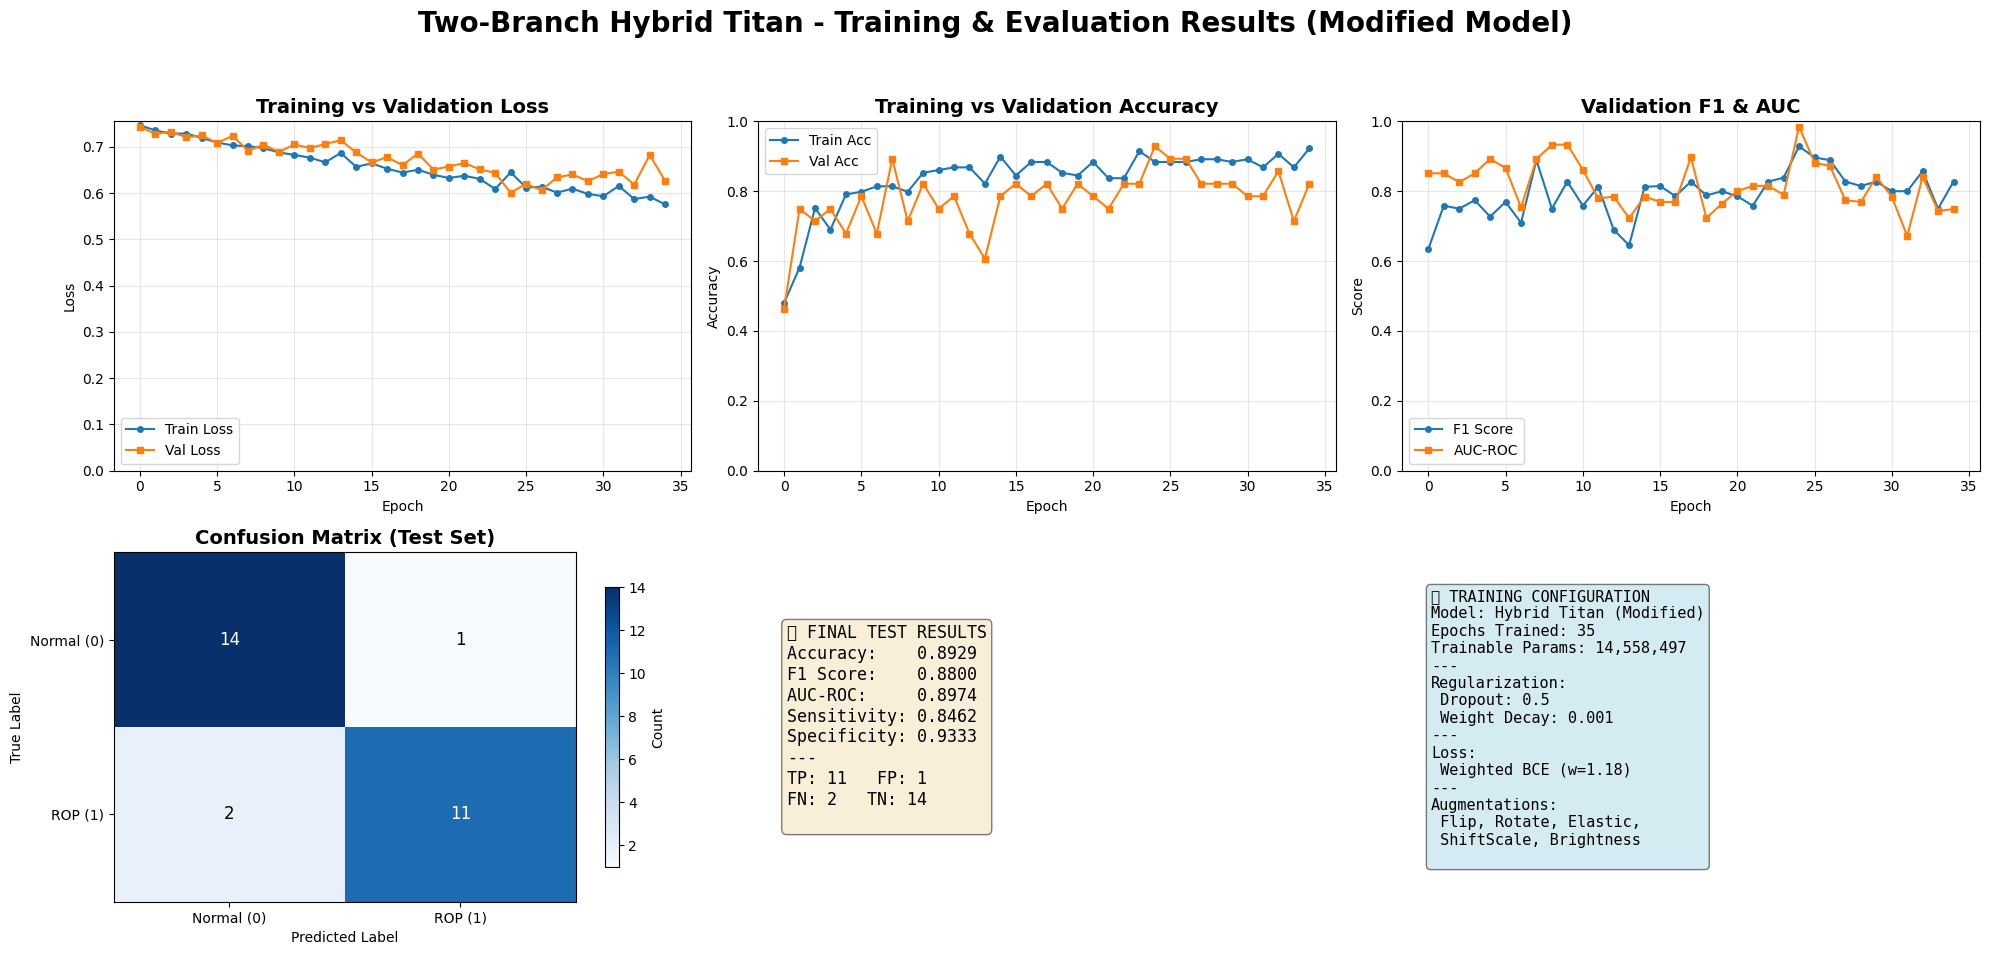


✅ SCRIPT COMPLETE


In [ ]:
# two_branch_hybrid_titan_full.py
# Complete script: dataset extraction -> segmentation model load -> hybrid model -> training -> evaluation
# Modification: Removed amplitude encoding from quantum circuit (no other architectural changes).

import os
import zipfile
import random
import time
import warnings
import logging
from tqdm import tqdm

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Quantum libraries
import pennylane as qml

# Albumentations for augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# -----------------------------------------------------------------------------
# User-modifiable paths
DATA_ZIP_PATH = "/content/HVDROPDB_RetCam_Neo_Classification (1) (2).zip"
SEGMENT_MODEL_PATH = "/content/segment.pth"
EXTRACT_FOLDER = "/content/extracted_data"
BEST_MODEL_SAVE_PATH = "/content/best_titan_model_v2.pth"
RESULTS_PNG_PATH = "/content/training_results_v2.png"

# -----------------------------------------------------------------------------
# Configuration & constants
warnings.filterwarnings("ignore")

ViT_OUTPUT_DIM = 768
RESNET18_OUTPUT_DIM = 512
FUSION_DIM = ViT_OUTPUT_DIM + RESNET18_OUTPUT_DIM  # 1280
COMPRESSION_DIM_1 = 128
COMPRESSION_DIM_2 = 16
N_QUBITS = 8
N_QUANTUM_LAYERS = 3
QUANTUM_PARAMS = N_QUANTUM_LAYERS * N_QUBITS * 3  # 72

IMG_SIZE = 224
BATCH_SIZE = 8
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-3
NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 10
GRADIENT_CLIP_VALUE = 1.0

TEST_SIZE = 0.3
VAL_RATIO = 0.5  # Of remaining 30%
RANDOM_SEED = 42

HILBERT_SPACE_DIM = 2 ** N_QUBITS  # 256

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)
VERBOSE = True

# -----------------------------------------------------------------------------
# Reproducibility
def set_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(RANDOM_SEED)

# Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("\n" + "="*60)
print("🖥️  SYSTEM CONFIGURATION")
print("="*60)
print(f"✓ Device: {DEVICE}")
if torch.cuda.is_available():
    try:
        print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    except Exception:
        pass
print(f"✓ DataLoader Workers: {NUM_WORKERS}")
print(f"✓ Random Seed: {RANDOM_SEED}")
print(f"✓ Weight Decay: {WEIGHT_DECAY}")
print("="*60)

# -----------------------------------------------------------------------------
# CELL 2: Dataset Extraction
dataset_path = "/content/classification/class"
extract_folder = EXTRACT_FOLDER

print("\n" + "="*60)
print("📁 DATASET EXTRACTION")
print("="*60)


print("="*60)

# -----------------------------------------------------------------------------
# CELL 3: Validate Segmentation Model Path
print("\n" + "="*60)
print("📤 SEGMENTATION MODEL CHECK")
print("="*60)

segment_model_path = None
if not os.path.exists(SEGMENT_MODEL_PATH):
    print(f"❌ ERROR: Model file not found at {SEGMENT_MODEL_PATH}")
    print("   Please upload your file and update the SEGMENT_MODEL_PATH variable.")
else:
    try:
        print(f"📍 Found model: {SEGMENT_MODEL_PATH}")
        print("   Validating model file...")
        state_dict = torch.load(SEGMENT_MODEL_PATH, map_location='cpu')

        if isinstance(state_dict, dict):
            print(f"   ✓ Found {len(state_dict)} layers in model")
            segment_model_path = SEGMENT_MODEL_PATH
            print(f"✅ Model validated: {segment_model_path}")
        else:
             print(f"⚠️  Unexpected model format, but saving path")
             segment_model_path = SEGMENT_MODEL_PATH
    except Exception as e:
            print(f"❌ ERROR loading model: {str(e)}")

print("="*60)

# -----------------------------------------------------------------------------
# CELL 5: U-Net Segmentation Model Architecture
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        conv2 = self.dconv_down2(self.maxpool(conv1))
        conv3 = self.dconv_down3(self.maxpool(conv2))
        conv4 = self.dconv_down4(self.maxpool(conv3))
        x = self.upsample(conv4)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out

print("\n" + "="*60)
print("🏗️  U-NET ARCHITECTURE DEFINED")
print("="*60)

# Load the trained segmentation model
print("\n📥 Loading pre-trained segmentation model...")
try:
    if segment_model_path is None:
        raise ValueError("segment_model_path not defined - please run dataset extraction and model validation first")

    segmentation_model = UNet(in_ch=3, out_ch=1).to(DEVICE)
    state_dict = torch.load(segment_model_path, map_location=DEVICE)
    segmentation_model.load_state_dict(state_dict)
    segmentation_model.eval()

    for param in segmentation_model.parameters():
        param.requires_grad = False

    print(f"✅ Segmentation model loaded successfully!")
    print(f"   Trainable: False (Frozen)")

except Exception as e:
    print(f"❌ ERROR loading segmentation model: {str(e)}")
    raise e
print("="*60)

# -----------------------------------------------------------------------------
# CELL 6: Dataset Class
class ROPClassificationDataset(Dataset):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

    def __init__(self, image_paths, labels, img_size=IMG_SIZE, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform
        assert len(image_paths) == len(labels), "Image and label count mismatch"
        if VERBOSE:
            print(f"   Initialized dataset with {len(image_paths)} samples")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            img = cv2.imread(img_path)
            if img is None: raise IOError(f"Failed to read image: {img_path}")
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)

            if self.transform:
                img = self.transform(image=img)['image']
                # Albumentations returns numpy with shape HWC & dtype float32 only if ToTensorV2 is used.
                # Our transforms currently don't include ToTensorV2; keep as numpy for consistency.

            img = img.astype(np.float32) / 255.0
            img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)
            label = torch.tensor(self.labels[idx], dtype=torch.float32)
            return img_tensor, label

        except Exception as e:
            print(f"❌ Error loading sample {idx} ({img_path}): {str(e)}")
            return torch.zeros((3, self.img_size, self.img_size)), torch.tensor(0.0)

def worker_init_fn(worker_id):
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

print("\n" + "="*60)
print("📊 DATASET CLASS DEFINED")
print("="*60)

# -----------------------------------------------------------------------------
# CELL 7: Data Preparation and Loading
print("\n" + "="*60)
print("📂 DATA PREPARATION")
print("="*60)

if dataset_path is None:
    raise ValueError("❌ dataset_path is None - please run dataset extraction first")
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"❌ Dataset path not found: {dataset_path}")

print(f"\n📍 Using dataset from: {dataset_path}")

NORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_Normal"), os.path.join(dataset_path, "RetCam_Normal")]
ABNORMAL_FOLDERS = [os.path.join(dataset_path, "Neo_ROP"), os.path.join(dataset_path, "RetCam_ROP")]

def load_images_from_folder(folder_path, valid_extensions):
    images = []
    if not os.path.exists(folder_path): return images
    for f in sorted(os.listdir(folder_path)):
        if any(f.endswith(ext) for ext in valid_extensions):
            images.append(os.path.join(folder_path, f))
    return images

print("\n📥 Loading images...")
normal_images = []
for folder in NORMAL_FOLDERS:
    normal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))

abnormal_images = []
for folder in ABNORMAL_FOLDERS:
    abnormal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))

COUNT_NORMAL = len(normal_images)
COUNT_ABNORMAL = len(abnormal_images)

print(f"   Normal (Class 0): {COUNT_NORMAL} images")
print(f"   Abnormal (Class 1): {COUNT_ABNORMAL} images")

if COUNT_NORMAL == 0 or COUNT_ABNORMAL == 0:
    raise ValueError("❌ No valid images found! Check folder structure")

all_images = normal_images + abnormal_images
all_labels = [0] * COUNT_NORMAL + [1] * COUNT_ABNORMAL

print(f"\n✓ Total images: {len(all_images)}")

print("\n📊 Data splitting...")
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels,
    test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=all_labels
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels,
    test_size=VAL_RATIO, random_state=RANDOM_SEED, stratify=temp_labels
)

print(f"   Training: {len(train_imgs)}")
print(f"   Validation: {len(val_imgs)}")
print(f"   Testing: {len(test_imgs)}")
print("="*60)

# -----------------------------------------------------------------------------
# CELL 8: Quantum Variational Circuit
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    """
    Modified: REMOVED amplitude embedding.
    We now use only angle encoding. The compressed feature vector (size COMPRESSION_DIM_2)
    is expected; we use the first N_QUBITS entries as angle features to encode rotations.
    """
    # Use first N_QUBITS values of inputs as angle features
    angle_features = inputs[:, :N_QUBITS]

    # Encode via Y rotations (angle encoding)
    for i in range(N_QUBITS):
        qml.RY(angle_features[:, i], wires=i)

    # Parameterized variational layers (same as before)
    for layer in range(N_QUANTUM_LAYERS):
        for i in range(N_QUBITS):
            qml.Rot(
                weights[layer, i, 0],
                weights[layer, i, 1],
                weights[layer, i, 2],
                wires=i
            )
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[N_QUBITS-1, 0])

    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

print("\n" + "="*60)
print("⚛️  QUANTUM CIRCUIT DEFINED (Angle-only encoding)")
print("="*60)

# -----------------------------------------------------------------------------
# CELL 9: Two-Branch Hybrid Titan Architecture
from transformers import ViTModel

class TwoBranchHybridTitan(nn.Module):
    def __init__(self, segmentation_model, n_qubits=N_QUBITS, n_layers=N_QUANTUM_LAYERS):
        super().__init__()
        self.segmentation_model = segmentation_model
        for param in self.segmentation_model.parameters():
            param.requires_grad = False

        # ===== BRANCH 1: ViT-Base (Context Expert) =====
        print("   Loading ViT-Base model...")
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")

        for param in self.vit.parameters():
            param.requires_grad = False

        # Unfreeze only final ViT layer (11)
        print("   Unfreezing only final ViT layer (11)...")
        for i in range(11, 12):
            for param in self.vit.encoder.layer[i].parameters():
                param.requires_grad = True

        for param in self.vit.embeddings.parameters():
            param.requires_grad = True

        # ===== BRANCH 2: ResNet18 (Ridge Expert) =====
        print("   Loading ResNet18 model...")
        self.mask_cnn = timm.create_model(
            'resnet18', pretrained=True, num_classes=0, global_pool='avg'
        )

        print("   Freezing ResNet18 layers...")
        for param in self.mask_cnn.parameters():
            param.requires_grad = False

        # Modify first conv layer for 1-channel input
        original_conv1 = self.mask_cnn.conv1
        self.mask_cnn.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        with torch.no_grad():
            self.mask_cnn.conv1.weight.copy_(
                original_conv1.weight.mean(dim=1, keepdim=True)
            )

        # Unfreeze only the new conv1 layer
        print("   Unfreezing new 1-channel conv layer in ResNet...")
        self.mask_cnn.conv1.requires_grad = True

        # ===== FUSION & CLASSICAL HEAD =====
        fusion_dim = ViT_OUTPUT_DIM + RESNET18_OUTPUT_DIM
        self.mha_refiner = nn.MultiheadAttention(
            embed_dim=fusion_dim, num_heads=8, batch_first=True, dropout=0.1
        )

        self.compression = nn.Sequential(
            nn.Linear(fusion_dim, COMPRESSION_DIM_1),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(COMPRESSION_DIM_1, COMPRESSION_DIM_2),
            nn.Tanh()
        )

        # ===== QUANTUM CORE =====
        weight_shape = {"weights": (N_QUANTUM_LAYERS, N_QUBITS, 3)}
        self.vqc = qml.qnn.TorchLayer(quantum_circuit, weight_shape)
        self.classifier_head = nn.Linear(n_qubits, 1)

        # ImageNet normalization buffers
        self.register_buffer('vit_mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('vit_std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        # ViT expects normalized images
        x_vit = (x - self.vit_mean) / (self.vit_std + 1e-8)
        vit_output = self.vit(x_vit)
        vit_features = vit_output.last_hidden_state[:, 0, :]

        with torch.no_grad():
            mask_logits = self.segmentation_model(x)
            masks = torch.sigmoid(mask_logits)

        mask_features = self.mask_cnn(masks)
        fused_features = torch.cat([vit_features, mask_features], dim=1)
        fused_unsqueezed = fused_features.unsqueeze(1)
        refined_features, _ = self.mha_refiner(fused_unsqueezed, fused_unsqueezed, fused_unsqueezed)
        refined_features = refined_features.squeeze(1)
        compressed_features = self.compression(refined_features)
        quantum_output = self.vqc(compressed_features)
        logits = self.classifier_head(quantum_output)
        return logits

print("\n" + "="*60)
print("🏛️  TWO-BRANCH HYBRID TITAN DEFINED (Modified: angle-only encoding)")
print("="*60)

# -----------------------------------------------------------------------------
# CELL 10: Model Initialization and Parameter Counting
print("\n" + "="*60)
print("🚀 INITIALIZING TWO-BRANCH HYBRID TITAN")
print("="*60)

try:
    model = TwoBranchHybridTitan(
        segmentation_model=segmentation_model,
        n_qubits=N_QUBITS,
        n_layers=N_QUANTUM_LAYERS
    ).to(DEVICE)
    print("\n✅ Model successfully initialized!")
except Exception as e:
    print(f"\n❌ ERROR initializing model: {str(e)}")
    raise

print("\n📊 PARAMETER ANALYSIS:")
def count_parameters(model, requires_grad=None):
    if requires_grad is None:
        return sum(p.numel() for p in model.parameters())
    else:
        return sum(p.numel() for p in model.parameters() if p.requires_grad == requires_grad)

total_params = count_parameters(model, requires_grad=None)
trainable_params = count_parameters(model, requires_grad=True)
frozen_params = count_parameters(model, requires_grad=False)

print(f"Total Parameters:      {total_params:>12,}")
print(f"Trainable Parameters:  {trainable_params:>12,}")
print(f"Frozen Parameters:     {frozen_params:>12,}")
print(f"Trainable %:           {100*trainable_params/total_params:>11.2f}%")
print("="*60)

# -----------------------------------------------------------------------------
# CELL 11: Training Setup
print("\n" + "="*60)
print("⚙️  TRAINING SETUP")
print("="*60)

# Augmentation
print("\n💿 Defining data augmentation pipeline...")
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.3, alpha=100, sigma=10),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4)
])

# Create Datasets & DataLoaders
print("\n📊 Creating DataLoaders...")
VERBOSE = False
train_dataset = ROPClassificationDataset(
    train_imgs, train_labels,
    img_size=IMG_SIZE,
    transform=train_transform
)
val_dataset = ROPClassificationDataset(
    val_imgs, val_labels,
    img_size=IMG_SIZE,
    transform=None
)
test_dataset = ROPClassificationDataset(
    test_imgs, test_labels,
    img_size=IMG_SIZE,
    transform=None
)
VERBOSE = True

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
print(f"✓ Train loader: {len(train_loader)} batches (with augmentation)")
print(f"✓ Val loader: {len(val_loader)} batches")
print(f"✓ Test loader: {len(test_loader)} batches")

# Loss function with pos_weight
pos_weight_value = COUNT_NORMAL / COUNT_ABNORMAL
pos_weight = torch.tensor(pos_weight_value).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"\n✓ Loss Function: BCEWithLogitsLoss (with pos_weight={pos_weight_value:.2f})")

# Optimizer
print(f"\n🎯 Setting up optimizer...")
optimizer = optim.AdamW([
    {'params': model.vit.encoder.layer[11:].parameters(), 'lr': LEARNING_RATE_ViT, 'name': 'ViT_layer_11'},
    {'params': model.vit.embeddings.parameters(), 'lr': LEARNING_RATE_Standard, 'name': 'ViT_Embeddings'},
    {'params': model.mask_cnn.conv1.parameters(), 'lr': LEARNING_RATE_ResNet, 'name': 'ResNet18_conv1'},
    {'params': model.mha_refiner.parameters(), 'lr': LEARNING_RATE_Standard, 'name': 'MHA_Refiner'},
    {'params': model.compression.parameters(), 'lr': LEARNING_RATE_Standard, 'name': 'Compression_Network'},
    {'params': model.vqc.parameters(), 'lr': LEARNING_RATE_Quantum, 'name': 'Quantum_Layer'},
    {'params': model.classifier_head.parameters(), 'lr': LEARNING_RATE_Standard, 'name': 'Classifier_Head'}
], weight_decay=WEIGHT_DECAY)

print("✓ Optimizer configured. Trainable components:")
for group in optimizer.param_groups:
    n_params = sum(p.numel() for p in group['params'] if p.requires_grad)
    if n_params > 0:
        print(f"  - {group['name']:<20} LR: {group['lr']:.0e}, Params: {n_params:>10,}")

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-8
)
print(f"\n✓ Scheduler: ReduceLROnPlateau")
print("="*60)

# -----------------------------------------------------------------------------
# CELL 12: Training Loop
print("\n" + "="*60)
print("🚂 STARTING TRAINING")
print("="*60)

best_val_loss = float('inf')
patience_counter = 0
train_history = {'loss': [], 'acc': []}
val_history = {'loss': [], 'acc': [], 'f1': [], 'auc': []}

start_epoch_time = time.time()
final_epoch = 0

for epoch in range(NUM_EPOCHS):
    final_epoch = epoch + 1
    print(f"\n{'='*70}\nEPOCH [{epoch+1}/{NUM_EPOCHS}]\n{'='*70}")

    model.train()
    train_loss, train_preds, train_targets = 0.0, [], []

    pbar = tqdm(train_loader, desc="🔴 Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRADIENT_CLIP_VALUE)
        optimizer.step()

        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_preds.extend(preds.cpu().numpy().flatten())
        train_targets.extend(labels.cpu().numpy().flatten())
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    if len(train_loader) == 0:
        print("   ⚠️ No training batches - check dataset / batch size")
        break

    train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_targets, train_preds) if len(train_targets) > 0 else 0.0
    train_history['loss'].append(train_loss)
    train_history['acc'].append(train_acc)

    # Validation
    model.eval()
    val_loss, val_preds, val_targets, val_probs = 0.0, [], [], []

    pbar_val = tqdm(val_loader, desc="🔵 Validation", leave=False)
    with torch.no_grad():
        for images, labels in pbar_val:
            images, labels = images.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            val_preds.extend(preds.cpu().numpy().flatten())
            val_targets.extend(labels.cpu().numpy().flatten())
            val_probs.extend(probs.cpu().numpy().flatten())
            pbar_val.set_postfix({'loss': f"{loss.item():.4f}"})

    if len(val_loader) == 0:
        print("   ⚠️ No validation batches - check dataset / split")
        break

    val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_targets, val_preds) if len(val_targets) > 0 else 0.0
    val_f1 = f1_score(val_targets, val_preds, zero_division=0) if len(val_targets) > 0 else 0.0

    if len(np.unique(val_targets)) < 2:
        val_auc = 0.5
        print("   ⚠️ Validation AUC not defined (only one class present in batch)")
    else:
        val_auc = roc_auc_score(val_targets, val_probs)

    val_history['loss'].append(val_loss)
    val_history['acc'].append(val_acc)
    val_history['f1'].append(val_f1)
    val_history['auc'].append(val_auc)

    scheduler.step(val_loss)

    print(f"\n📈 RESULTS (Epoch {epoch+1}):")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"   Val F1:     {val_f1:.4f} | Val AUC:   {val_auc:.4f}")

    # Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"\n✅ BEST MODEL SAVED! (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"\n⏳ Patience: [{patience_counter}/{EARLY_STOP_PATIENCE}]")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n🛑 EARLY STOPPING TRIGGERED!")
        break

end_epoch_time = time.time()
print(f"\n{'='*70}\n✅ TRAINING COMPLETE\n{'='*70}")
print(f"Total Epochs: {final_epoch}/{NUM_EPOCHS}")
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total Training Time: {(end_epoch_time - start_epoch_time) / 60:.2f} minutes")

# -----------------------------------------------------------------------------
# CELL 13: Final Evaluation on Test Set
print("\n" + "="*60)
print("🧪 TEST SET EVALUATION")
print("="*60)

model_path = BEST_MODEL_SAVE_PATH
if not os.path.exists(model_path):
    print(f"❌ ERROR: Model file not found: {model_path}")
    print("   This can happen if validation loss never improved.")
    test_acc, test_f1, test_auc, sensitivity, specificity, tp, fp, fn, tn, cm = 0,0,0,0,0,0,0,0,0, np.zeros((2,2))
else:
    print(f"\n📥 Loading best model from: {model_path}")
    try:
        model_eval = TwoBranchHybridTitan(
            segmentation_model=segmentation_model,
            n_qubits=N_QUBITS, n_layers=N_QUANTUM_LAYERS
        ).to(DEVICE)
        model_eval.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model_eval.eval()
        print("✅ Model loaded successfully")
    except Exception as e:
        print(f"❌ ERROR loading model: {str(e)}")
        raise

    test_loss, test_preds, test_targets, test_probs = 0.0, [], [], []

    print("\n🔄 Processing test set...")
    pbar_test = tqdm(test_loader, desc="🧪 Evaluating", leave=False)
    with torch.no_grad():
        for images, labels in pbar_test:
            images, labels = images.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            outputs = model_eval(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            test_preds.extend(preds.cpu().numpy().flatten())
            test_targets.extend(labels.cpu().numpy().flatten())
            test_probs.extend(probs.cpu().numpy().flatten())

    if len(test_loader) == 0:
        print("   ⚠️ No test batches - check dataset split")
    else:
        test_loss = test_loss / len(test_loader)
        test_acc = accuracy_score(test_targets, test_preds) if len(test_targets) > 0 else 0.0
        test_f1 = f1_score(test_targets, test_preds, zero_division=0) if len(test_targets) > 0 else 0.0

        if len(np.unique(test_targets)) < 2:
            test_auc = 0.5
            print("   ⚠️ Test AUC not defined (only one class present in test set)")
        else:
            test_auc = roc_auc_score(test_targets, test_probs)

        cm = confusion_matrix(test_targets, test_preds)

        if cm.shape == (1, 1):
            if 0 in test_targets:
                cm = np.array([[cm[0,0], 0], [0, 0]])
            else:
                cm = np.array([[0, 0], [0, cm[0,0]]])

        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        print(f"\n{'='*60}\n🎯 FINAL TEST RESULTS\n{'='*60}")
        print(f"\n📊 Classification Metrics:")
        print(f"   Test Loss:     {test_loss:.4f}")
        print(f"   Accuracy:      {test_acc:.4f} ({test_acc*100:.2f}%)")
        print(f"   F1 Score:      {test_f1:.4f}")
        print(f"   AUC-ROC:       {test_auc:.4f}")
        print(f"\n🔍 Detailed Metrics:")
        print(f"   Sensitivity (True Positive Rate): {sensitivity:.4f}")
        print(f"   Specificity (True Negative Rate): {specificity:.4f}")
        print(f"\n📋 Confusion Matrix:")
        print(f"   ┌─────────────────────────┐")
        print(f"   │ TN: {tn:>5} | FP: {fp:>5} │ (True: Normal)")
        print(f"   │ FN: {fn:>5} | TP: {tp:>5} │ (True: ROP)")
        print(f"   └─────────────────────────┘")
        print(f"     Pred: Normal | Pred: ROP")
        print(f"\n{'='*60}")

# -----------------------------------------------------------------------------
# CELL 14: Visualize Training Curves and Confusion Matrix
print("\n" + "="*60)
print("📊 VISUALIZATION")
print("="*60)

# Ensure all histories exist
if 'cm' not in locals():
    cm = np.zeros((2,2))
if 'test_acc' not in locals():
    test_acc = 0.0
if 'test_f1' not in locals():
    test_f1 = 0.0
if 'test_auc' not in locals():
    test_auc = 0.0
if 'sensitivity' not in locals():
    sensitivity = 0.0
if 'specificity' not in locals():
    specificity = 0.0
if 'train_history' not in locals():
    train_history = {'loss': [], 'acc': []}
if 'val_history' not in locals():
    val_history = {'loss': [], 'acc': [], 'f1': [], 'auc': []}
if 'final_epoch' not in locals():
    final_epoch = 0
if 'trainable_params' not in locals():
    trainable_params = 0

fig = plt.figure(figsize=(20, 10))
fig.suptitle("Two-Branch Hybrid Titan - Training & Evaluation Results (Modified Model)", fontsize=20, fontweight='bold')

# Loss
ax1 = plt.subplot(2, 3, 1)
ax1.plot(train_history['loss'], label='Train Loss', marker='o', markersize=4)
ax1.plot(val_history['loss'], label='Val Loss', marker='s', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Accuracy
ax2 = plt.subplot(2, 3, 2)
ax2.plot(train_history['acc'], label='Train Acc', marker='o', markersize=4)
ax2.plot(val_history['acc'], label='Val Acc', marker='s', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.0)

# F1 and AUC
ax3 = plt.subplot(2, 3, 3)
ax3.plot(val_history['f1'], label='F1 Score', marker='o', markersize=4)
ax3.plot(val_history['auc'], label='AUC-ROC', marker='s', markersize=4)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Score')
ax3.set_title('Validation F1 & AUC', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.0)

# Confusion Matrix
ax4 = plt.subplot(2, 3, 4)
im = ax4.imshow(cm, cmap='Blues', aspect='auto')
ax4.set_xlabel('Predicted Label')
ax4.set_ylabel('True Label')
ax4.set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(['Normal (0)', 'ROP (1)'])
ax4.set_yticklabels(['Normal (0)', 'ROP (1)'])
for i in range(2):
    for j in range(2):
        ax4.text(j, i, int(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
plt.colorbar(im, ax=ax4, label='Count', shrink=0.8)

# Metrics Summary
ax5 = plt.subplot(2, 3, 5)
ax5.axis('off')
metrics_text = f"""🎯 FINAL TEST RESULTS
Accuracy:    {test_acc:.4f}
F1 Score:    {test_f1:.4f}
AUC-ROC:     {test_auc:.4f}
Sensitivity: {sensitivity:.4f}
Specificity: {specificity:.4f}
---
TP: {int(tp) if 'tp' in locals() else 0}   FP: {int(fp) if 'fp' in locals() else 0}
FN: {int(fn) if 'fn' in locals() else 0}   TN: {int(tn) if 'tn' in locals() else 0}
"""
ax5.text(0.05, 0.5, metrics_text, fontsize=12, family='monospace', va='center', bbox=dict(boxstyle='round', fc='wheat', alpha=0.5))

# Training Info
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
training_text = f"""📋 TRAINING CONFIGURATION
Model: Hybrid Titan (Modified)
Epochs Trained: {final_epoch}
Trainable Params: {trainable_params:,}
---
Regularization:
 Dropout: 0.5
 Weight Decay: {WEIGHT_DECAY}
---
Loss:
 Weighted BCE (w={pos_weight_value:.2f})
---
Augmentations:
 Flip, Rotate, Elastic,
 ShiftScale, Brightness
"""
ax6.text(0.05, 0.5, training_text, fontsize=11, family='monospace', va='center', bbox=dict(boxstyle='round', fc='lightblue', alpha=0.5))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(RESULTS_PNG_PATH, dpi=150, bbox_inches='tight')
print(f"✅ Results saved to: {RESULTS_PNG_PATH}")
plt.show()

print("\n" + "="*60)
print("✅ SCRIPT COMPLETE")
print("="*60)


In [ ]:
# ===========================================================================
# CELL 1: IMPORTS & PATHS
# ===========================================================================
import os, random, time, warnings, logging, zipfile
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import timm
from transformers import ViTModel
import pennylane as qml
from pennylane import numpy as pnp
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ===========================================================================
# ❗❗ FILE PATHS ❗❗
# ===========================================================================
DATA_ZIP_PATH = "/content/HVDROPDB_RetCam_Neo_Classification (1) (2).zip"
SEGMENT_MODEL_PATH = "/content/segment.pth"

# ===========================================================================
# CELL 2: DATASET EXTRACTION
# ===========================================================================
print("\n" + "="*60)
print("📁 DATASET EXTRACTION")
print("="*60)

dataset_path = None
extract_folder = "/content/extracted_data"

if not os.path.exists(DATA_ZIP_PATH):
    print(f"❌ ERROR: Data ZIP file not found at {DATA_ZIP_PATH}")
else:
    os.makedirs(extract_folder, exist_ok=True)
    with zipfile.ZipFile(DATA_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)
    print(f"✅ Successfully extracted to: {extract_folder}")

    found_path = None
    for root, dirs, files_list in os.walk(extract_folder):
        if "Neo_Normal" in dirs and "Neo_ROP" in dirs:
            found_path = root
            break

    dataset_path = found_path if found_path else extract_folder
    if found_path:
        print(f"✓ Found data folders in: {dataset_path}")
    else:
        print(f"⚠️ Warning: Could not auto-find 'Neo_Normal'. Using root: {dataset_path}")

print("="*60)

# ===========================================================================
# CELL 3: SEGMENTATION MODEL CHECK
# ===========================================================================
print("\n" + "="*60)
print("📤 SEGMENTATION MODEL CHECK")
print("="*60)

segment_model_path = None
if not os.path.exists(SEGMENT_MODEL_PATH):
    print(f"❌ ERROR: Model file not found at {SEGMENT_MODEL_PATH}")
else:
    try:
        state_dict = torch.load(SEGMENT_MODEL_PATH, map_location='cpu')
        if isinstance(state_dict, dict):
            print(f"✅ Model validated: {SEGMENT_MODEL_PATH} ({len(state_dict)} layers)")
            segment_model_path = SEGMENT_MODEL_PATH
        else:
            print(f"⚠️ Unexpected format, saving path anyway")
            segment_model_path = SEGMENT_MODEL_PATH
    except Exception as e:
        print(f"❌ ERROR loading model: {str(e)}")

print("="*60)

# ===========================================================================
# CELL 4: CONFIGURATION & CONSTANTS
# ===========================================================================
warnings.filterwarnings("ignore")

ViT_OUTPUT_DIM = 768
RESNET18_OUTPUT_DIM = 512
FUSION_DIM = ViT_OUTPUT_DIM + RESNET18_OUTPUT_DIM
COMPRESSION_DIM_1 = 128
COMPRESSION_DIM_2 = 16

N_QUBITS = 10
N_QUANTUM_LAYERS = 3
QUANTUM_PARAMS = N_QUANTUM_LAYERS * N_QUBITS * 3

IMG_SIZE = 224
BATCH_SIZE = 8
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-3
NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 10
GRADIENT_CLIP_VALUE = 1.0

TEST_SIZE = 0.3
VAL_RATIO = 0.5
RANDOM_SEED = 42

HILBERT_SPACE_DIM = 2 ** N_QUBITS
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)
VERBOSE = True

def set_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(RANDOM_SEED)

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("\n" + "="*60)
print("🖥️  SYSTEM CONFIGURATION")
print("="*60)
print(f"✓ Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"✓ DataLoader Workers: {NUM_WORKERS}")
print(f"✓ Random Seed: {RANDOM_SEED}")
print(f"✓ Weight Decay: {WEIGHT_DECAY}")
print("="*60)

# ===========================================================================
# CELL 5: U-NET SEGMENTATION MODEL
# ===========================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        conv2 = self.dconv_down2(self.maxpool(conv1))
        conv3 = self.dconv_down3(self.maxpool(conv2))
        conv4 = self.dconv_down4(self.maxpool(conv3))
        x = self.upsample(conv4)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out

# Load segmentation model
segmentation_model = UNet().to(DEVICE)
state_dict = torch.load(segment_model_path, map_location=DEVICE)
segmentation_model.load_state_dict(state_dict)
segmentation_model.eval()
for param in segmentation_model.parameters():
    param.requires_grad = False
print("✅ Segmentation model loaded and frozen")

# ===========================================================================
# CELL 6: DATASET CLASS
# ===========================================================================
class ROPClassificationDataset(Dataset):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    def __init__(self, image_paths, labels, img_size=IMG_SIZE, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform
        assert len(image_paths) == len(labels), "Image and label count mismatch"
        if VERBOSE: print(f"   Initialized dataset with {len(image_paths)} samples")
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            img = cv2.imread(img_path)
            if img is None: raise IOError(f"Failed to read image: {img_path}")
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size))
            if self.transform: img = self.transform(image=img)['image']
            img = img.astype(np.float32)/255.0
            img_tensor = torch.tensor(img, dtype=torch.float32).permute(2,0,1)
            label = torch.tensor(self.labels[idx], dtype=torch.float32)
            return img_tensor, label
        except Exception as e:
            print(f"❌ Error loading {idx}: {str(e)}")
            return torch.zeros((3,self.img_size,self.img_size)), torch.tensor(0.0)

def worker_init_fn(worker_id):
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

# ===========================================================================
# CELL 7: DATA PREPARATION
# ===========================================================================
NORMAL_FOLDERS = [os.path.join(dataset_path,"Neo_Normal"), os.path.join(dataset_path,"RetCam_Normal")]
ABNORMAL_FOLDERS = [os.path.join(dataset_path,"Neo_ROP"), os.path.join(dataset_path,"RetCam_ROP")]

def load_images_from_folder(folder_path, valid_extensions):
    images = []
    if not os.path.exists(folder_path): return images
    for f in sorted(os.listdir(folder_path)):
        if any(f.endswith(ext) for ext in valid_extensions):
            images.append(os.path.join(folder_path, f))
    return images

normal_images, abnormal_images = [], []
for folder in NORMAL_FOLDERS: normal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))
for folder in ABNORMAL_FOLDERS: abnormal_images.extend(load_images_from_folder(folder, ROPClassificationDataset.VALID_EXTENSIONS))

COUNT_NORMAL = len(normal_images)
COUNT_ABNORMAL = len(abnormal_images)

all_images = normal_images + abnormal_images
all_labels = [0]*COUNT_NORMAL + [1]*COUNT_ABNORMAL

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=all_labels
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=VAL_RATIO, random_state=RANDOM_SEED, stratify=temp_labels
)

# ===========================================================================
# CELL 8: QUANTUM CIRCUIT
# ===========================================================================
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    amplitude_features = inputs[:, :N_QUBITS]
    angle_features = inputs[:, N_QUBITS:2*N_QUBITS]
    qml.AmplitudeEmbedding(amplitude_features, wires=range(N_QUBITS), pad_with=0., normalize=True)
    for layer in range(N_QUANTUM_LAYERS):
        for i in range(N_QUBITS): qml.RY(angle_features[:,i], wires=i)
        for i in range(N_QUBITS): qml.Rot(weights[layer,i,0], weights[layer,i,1], weights[layer,i,2], wires=i)
        for i in range(N_QUBITS-1): qml.CNOT(wires=[i,i+1])
        qml.CNOT(wires=[N_QUBITS-1,0])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# ===========================================================================
# CELL 9: TWO-BRANCH HYBRID TITAN MODEL
# ===========================================================================
class TwoBranchHybridTitan(nn.Module):
    def __init__(self, segmentation_model, n_qubits=N_QUBITS, n_layers=N_QUANTUM_LAYERS):
        super().__init__()
        self.segmentation_model = segmentation_model
        for param in self.segmentation_model.parameters(): param.requires_grad=False

        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for param in self.vit.parameters(): param.requires_grad=False
        for i in range(11,12):
            for param in self.vit.encoder.layer[i].parameters(): param.requires_grad=True
        for param in self.vit.embeddings.parameters(): param.requires_grad=True

        self.mask_cnn = timm.create_model('resnet18', pretrained=True, num_classes=0, global_pool='avg')
        for param in self.mask_cnn.parameters(): param.requires_grad=False
        original_conv1 = self.mask_cnn.conv1
        self.mask_cnn.conv1 = nn.Conv2d(1,64,kernel_size=7,stride=2,padding=3,bias=False)
        with torch.no_grad(): self.mask_cnn.conv1.weight[:,:] = original_conv1.weight.mean(dim=1, keepdim=True)

        self.fusion_layer = nn.Sequential(
            nn.Linear(FUSION_DIM, COMPRESSION_DIM_1),
            nn.ReLU(),
            nn.Linear(COMPRESSION_DIM_1, COMPRESSION_DIM_2),
            nn.ReLU()
        )
        self.quantum_weights = nn.Parameter(0.01*torch.randn(n_layers, n_qubits, 3))
        self.final = nn.Linear(n_qubits, 1)

    def forward(self, x):
        with torch.no_grad(): mask = torch.sigmoid(self.segmentation_model(x))
        mask_feat = self.mask_cnn(mask)

        vit_feat = self.vit(x).pooler_output
        fusion_feat = torch.cat([vit_feat, mask_feat], dim=1)
        compression_feat = self.fusion_layer(fusion_feat)

        q_in = compression_feat.unsqueeze(0) if compression_feat.dim()==1 else compression_feat
        q_out = quantum_circuit(q_in, self.quantum_weights)
        q_out = torch.tensor(q_out, dtype=torch.float32).to(DEVICE)
        out = torch.sigmoid(self.final(q_out))
        return out

# ===========================================================================
# CELL 10: INSTANTIATE MODEL
# ===========================================================================
model = TwoBranchHybridTitan(segmentation_model).to(DEVICE)
print("\n✅ Two-Branch Hybrid Titan Model instantiated")

# ===========================================================================
# CELL 11: LOSS, OPTIMIZER, SCHEDULER
# ===========================================================================
criterion = nn.BCELoss()
optimizer = optim.Adam([
    {'params': model.final.parameters(), 'lr': LEARNING_RATE_Standard},
    {'params': model.quantum_weights, 'lr': LEARNING_RATE_Quantum}
], weight_decay=WEIGHT_DECAY)

# ===========================================================================
# CELL 12: DATALOADERS
# ===========================================================================
train_dataset = ROPClassificationDataset(train_imgs, train_labels)
val_dataset = ROPClassificationDataset(val_imgs, val_labels)
test_dataset = ROPClassificationDataset(test_imgs, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, worker_init_fn=worker_init_fn)

# ===========================================================================
# CELL 13: TRAINING LOOP
# ===========================================================================
best_val_loss = float('inf')
early_stop_counter = 0
train_losses, val_losses = [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
        optimizer.step()
        running_loss += loss.item()*imgs.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()*imgs.size(0)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"\nEpoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "/content/best_model.pth")
        early_stop_counter = 0
        print("✅ Saved Best Model")
    else:
        early_stop_counter += 1
        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f"⚠️ Early stopping at epoch {epoch+1}")
            break

# ===========================================================================
# CELL 14: PLOT TRAIN & VAL LOSS
# ===========================================================================
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

# ===========================================================================
# CELL 15: TEST METRICS
# ===========================================================================
model.load_state_dict(torch.load("/content/best_model.pth"))
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        outputs = outputs.cpu().numpy().flatten()
        preds = (outputs>0.5).astype(int)
        y_pred.extend(preds)
        y_true.extend(labels.numpy())

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc = roc_auc_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("\n📊 TEST METRICS")
print("="*40)
print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | ROC-AUC: {roc:.4f}")
print("Confusion Matrix:\n", cm)


In [ ]:
# ============================================================================
# CELL 4: Imports, Configuration & Constants (Production Quality)
# ============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import random
import warnings
import logging

warnings.filterwarnings("ignore")

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2

# Transformers for ViT
from transformers import ViTModel

# Timm for pre-trained models
import timm

# PennyLane for Quantum
import pennylane as qml

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# ============================================================================
# CONSTANTS - Define all magic numbers here
# ============================================================================

# Model Architecture Constants
ViT_OUTPUT_DIM = 768
RESNET18_OUTPUT_DIM = 512
FUSION_DIM = ViT_OUTPUT_DIM + RESNET18_OUTPUT_DIM  # 1280
COMPRESSION_DIM_1 = 128
COMPRESSION_DIM_2 = 16
N_QUBITS = 8
N_QUANTUM_LAYERS = 3
QUANTUM_PARAMS = N_QUANTUM_LAYERS * N_QUBITS * 3  # 72

# Training Constants
IMG_SIZE = 224
BATCH_SIZE = 8
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_Quantum = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 10
GRADIENT_CLIP_VALUE = 1.0

# Data Split Constants
TEST_SIZE = 0.3
VAL_RATIO = 0.5  # Of remaining 30%
RANDOM_SEED = 42

# Quantum Circuit Constants
HILBERT_SPACE_DIM = 2 ** N_QUBITS  # 256

# System Constants
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 2)  # Adaptive worker count
VERBOSE = True

# ============================================================================
# REPRODUCIBILITY
# ============================================================================

def set_seeds(seed=RANDOM_SEED):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(RANDOM_SEED)

# ============================================================================
# LOGGING SETUP
# ============================================================================

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ============================================================================
# SYSTEM INFORMATION
# ============================================================================

print("="*60)
print("🖥️  SYSTEM CONFIGURATION")
print("="*60)

print(f"\n✓ Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print(f"✓ CPU Cores: {os.cpu_count()}")
print(f"✓ DataLoader Workers: {NUM_WORKERS}")
print(f"✓ Random Seed: {RANDOM_SEED}")

# ============================================================================
# MODEL ARCHITECTURE CONSTANTS
# ============================================================================

print(f"\n📊 MODEL ARCHITECTURE CONSTANTS:")
print(f"   ViT Output: {ViT_OUTPUT_DIM}-dim")
print(f"   ResNet Output: {RESNET18_OUTPUT_DIM}-dim")
print(f"   Fusion: {FUSION_DIM}-dim")
print(f"   Compression: {COMPRESSION_DIM_1} → {COMPRESSION_DIM_2}")
print(f"   Quantum: {N_QUBITS} qubits, {QUANTUM_PARAMS} parameters")
print(f"   Hilbert Space: {HILBERT_SPACE_DIM} dimensions")

print("\n" + "="*60)
print("✅ CONFIGURATION READY")
print("="*60)

🖥️  SYSTEM CONFIGURATION

✓ Device: cuda
✓ GPU: Tesla T4
✓ GPU Memory: 15.83 GB
✓ CPU Cores: 2
✓ DataLoader Workers: 2
✓ Random Seed: 42

📊 MODEL ARCHITECTURE CONSTANTS:
   ViT Output: 768-dim
   ResNet Output: 512-dim
   Fusion: 1280-dim
   Compression: 128 → 16
   Quantum: 8 qubits, 72 parameters
   Hilbert Space: 256 dimensions

✅ CONFIGURATION READY


In [ ]:
# ============================================================================
# CELL 5: U-Net Segmentation Model Architecture (FIXED)
# ============================================================================

class DoubleConv(nn.Module):
    """Two consecutive conv layers with BatchNorm + ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    # --- CORRECTION ---
    # This forward method was incorrectly indented inside __init__
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    """U-Net for Ridge Segmentation"""
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_ch, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)

        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        # Encoder
        conv1 = self.dconv_down1(x)
        conv2 = self.dconv_down2(self.maxpool(conv1))
        conv3 = self.dconv_down3(self.maxpool(conv2))
        conv4 = self.dconv_down4(self.maxpool(conv3))

        # Decoder
        x = self.upsample(conv4)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)

        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)

        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)

        out = self.conv_last(x)
        return out  # Returns logits (no sigmoid)

print("="*60)
print("🏗️  U-NET ARCHITECTURE DEFINED")
print("="*60)

# Load the trained segmentation model with error handling
print("\n📥 Loading pre-trained segmentation model...")
try:
    if segment_model_path is None:
        raise ValueError("segment_model_path not defined - please run CELL 3 first")

    segmentation_model = UNet(in_ch=3, out_ch=1).to(DEVICE)
    state_dict = torch.load(segment_model_path, map_location=DEVICE)
    segmentation_model.load_state_dict(state_dict)
    segmentation_model.eval()

    # Freeze all parameters
    for param in segmentation_model.parameters():
        param.requires_grad = False

    print(f"✅ Segmentation model loaded successfully!")
    print(f"   Model path: {segment_model_path}")
    print(f"   Device: {DEVICE}")
    print(f"   Parameters: {sum(p.numel() for p in segmentation_model.parameters()):,}")
    print(f"   Trainable: False (Frozen)")

except Exception as e:
    print(f"❌ ERROR loading segmentation model: {str(e)}")
    print("   This likely means the U-Net class in this cell does not")
    print("   match the architecture used to train 'segment.pth'.")
    raise e
print("="*60)

🏗️  U-NET ARCHITECTURE DEFINED

📥 Loading pre-trained segmentation model...
✅ Segmentation model loaded successfully!
   Model path: segment.pth
   Device: cuda
   Parameters: 7,788,545
   Trainable: False (Frozen)


In [ ]:
# ============================================================================
# CELL 6: Dataset Class for ROP Classification with Augmentation
# ============================================================================

class ROPClassificationDataset(Dataset):
    """
    Dataset for ROP Classification (Plus Disease vs No Plus Disease).

    Features:
    - Loads RGB images and binary labels
    - Handles image resizing to 224x224
    - Normalization to [0, 1]
    - Optional augmentation
    - File validation
    """

    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

    def __init__(self, image_paths, labels, img_size=IMG_SIZE, transform=None):
        """
        Args:
            image_paths: List of image file paths
            labels: List of binary labels (0 or 1)
            img_size: Target image size (default 224)
            transform: Optional albumentations transforms
        """
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform

        # Validate inputs
        assert len(image_paths) == len(labels), \
            f"Mismatch: {len(image_paths)} images vs {len(labels)} labels"
        assert len(image_paths) > 0, "Dataset is empty!"

        # Log info
        if VERBOSE:
            print(f"   Initialized dataset with {len(image_paths)} samples")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        try:
            # Load image
            img = cv2.imread(img_path)
            if img is None:
                raise IOError(f"Failed to read image: {img_path}")

            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize to target size
            img = cv2.resize(img, (self.img_size, self.img_size),
                            interpolation=cv2.INTER_LINEAR)

            # Apply Albumentations (if any)
            if self.transform:
                img = self.transform(image=img)['image']

            # Normalize to [0, 1]
            img = img.astype(np.float32) / 255.0

            # Convert to tensor [C, H, W]
            img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)

            # Get label
            label = torch.tensor(self.labels[idx], dtype=torch.float32)

            return img_tensor, label

        except Exception as e:
            print(f"❌ Error loading sample {idx} ({img_path}): {str(e)}")
            # Return zeros as fallback
            return torch.zeros((3, self.img_size, self.img_size)), torch.tensor(0.0)

def worker_init_fn(worker_id):
    """Initialize random state for DataLoader workers (reproducibility)"""
    np.random.seed(RANDOM_SEED + worker_id)
    random.seed(RANDOM_SEED + worker_id)

print("="*60)
print("📊 DATASET CLASS DEFINED")
print("="*60)
print("\n✓ ROPClassificationDataset ready")
print("✓ Worker initialization function ready")
print("="*60)

📊 DATASET CLASS DEFINED

✓ ROPClassificationDataset ready
✓ Worker initialization function ready


In [ ]:
# ============================================================================
# CELL 7: Data Preparation and Loading with Validation
# ============================================================================

print("="*60)
print("📂 DATA PREPARATION")
print("="*60)

# Validate dataset_path exists (from CELL 2)
if dataset_path is None:
    raise ValueError("❌ dataset_path is None - please run CELL 2 first to upload dataset")
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"❌ Dataset path not found: {dataset_path}")

print(f"\n📍 Using dataset from: {dataset_path}")

# --- MODIFIED: Define YOUR folder names ---
NORMAL_FOLDERS = [
    os.path.join(dataset_path, "Neo_Normal"),
    os.path.join(dataset_path, "RetCam_Normal")
]
ABNORMAL_FOLDERS = [
    os.path.join(dataset_path, "Neo_ROP"),
    os.path.join(dataset_path, "RetCam_ROP")
]

# Validate folders exist
for folder in NORMAL_FOLDERS + ABNORMAL_FOLDERS:
    if not os.path.exists(folder):
        # This is just a warning, as one folder might be empty
        print(f"⚠️ Warning: Folder not found, skipping: {folder}")
    else:
        print(f"✓ Found folder: {folder}")


# Load images with specific extensions
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

def load_images_from_folder(folder_path, valid_extensions):
    """Load only valid image files"""
    images = []
    if not os.path.exists(folder_path):
        return images # Return empty list if path doesn't exist

    all_files = os.listdir(folder_path)
    for f in sorted(all_files):
        if any(f.endswith(ext) for ext in valid_extensions):
            images.append(os.path.join(folder_path, f))
    return images

# Load Normal (0) and Abnormal (1) images
print("\n📥 Loading images...")
normal_images = []
for folder in NORMAL_FOLDERS:
    normal_images.extend(load_images_from_folder(folder, VALID_EXTENSIONS))

abnormal_images = []
for folder in ABNORMAL_FOLDERS:
    abnormal_images.extend(load_images_from_folder(folder, VALID_EXTENSIONS))

print(f"   Normal (Class 0): {len(normal_images)} images")
print(f"   Abnormal (Class 1): {len(abnormal_images)} images")

# Validate we have images
if len(normal_images) == 0 or len(abnormal_images) == 0:
    raise ValueError("❌ No valid images found! Check folder structure and file extensions")

# Create image list and labels
all_images = normal_images + abnormal_images
all_labels = [0] * len(normal_images) + [1] * len(abnormal_images)

print(f"\n✓ Total images: {len(all_images)} (Should be ~185)")
print(f"✓ Total labels: {len(all_labels)}")

# Data split: 70% train, 15% val, 15% test
print("\n📊 Data splitting...")
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels,
    test_size=TEST_SIZE,     # 0.3
    random_state=RANDOM_SEED,
    stratify=all_labels
)

val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels,
    test_size=VAL_RATIO,     # 0.5 (of the 0.3 temp)
    random_state=RANDOM_SEED,
    stratify=temp_labels
)

print(f"   Training: {len(train_imgs)} ({len(train_imgs)/len(all_images)*100:.1f}%)")
print(f"   Validation: {len(val_imgs)} ({len(val_imgs)/len(all_images)*100:.1f}%)")
print(f"   Testing: {len(test_imgs)} ({len(test_imgs)/len(all_images)*100:.1f}%)")

# Verify split proportion
train_abnormal = sum(1 for x in train_labels if x == 1)
val_abnormal = sum(1 for x in val_labels if x == 1)
test_abnormal = sum(1 for x in test_labels if x == 1)

print(f"\n✓ Label distribution:")
print(f"   Train - Abnormal: {train_abnormal}, Normal: {len(train_imgs)-train_abnormal}")
print(f"   Val   - Abnormal: {val_abnormal}, Normal: {len(val_imgs)-val_abnormal}")
print(f"   Test  - Abnormal: {test_abnormal}, Normal: {len(test_imgs)-test_abnormal}")

print("\n" + "="*60)
print("✅ DATA PREPARATION COMPLETE")
print("="*60)

📂 DATA PREPARATION

📍 Using dataset from: HVDROPDB_RetCam_Neo_Classification (1) (2)/HVDROPDB_RetCam_Neo_Classification (1) (2)
✓ Found folder: HVDROPDB_RetCam_Neo_Classification (1) (2)/HVDROPDB_RetCam_Neo_Classification (1) (2)/Neo_Normal
✓ Found folder: HVDROPDB_RetCam_Neo_Classification (1) (2)/HVDROPDB_RetCam_Neo_Classification (1) (2)/RetCam_Normal
✓ Found folder: HVDROPDB_RetCam_Neo_Classification (1) (2)/HVDROPDB_RetCam_Neo_Classification (1) (2)/Neo_ROP
✓ Found folder: HVDROPDB_RetCam_Neo_Classification (1) (2)/HVDROPDB_RetCam_Neo_Classification (1) (2)/RetCam_ROP

📥 Loading images...
   Normal (Class 0): 100 images
   Abnormal (Class 1): 85 images

✓ Total images: 185 (Should be ~185)
✓ Total labels: 185

📊 Data splitting...
   Training: 129 (69.7%)
   Validation: 28 (15.1%)
   Testing: 28 (15.1%)

✓ Label distribution:
   Train - Abnormal: 59, Normal: 70
   Val   - Abnormal: 13, Normal: 15
   Test  - Abnormal: 13, Normal: 15

✅ DATA PREPARATION COMPLETE


In [ ]:
# ============================================================================
# CELL 8: Quantum Variational Circuit (FIXED for Performance)
# ============================================================================

# Define quantum device
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    """
    Hybrid Quantum Circuit with 8 Qubits.
    This function is now fully batched by qml.qnn.TorchLayer.

    Args:
        inputs: [batch_size, 16] tensor of classical features
        weights: [3, 8, 3] tensor of VQC parameters
    """

    # --- CORRECTION ---
    # Simplified encoding. The Tanh in the compression layer
    # already bounds features. 'normalize=True' handles the math.

    # Split inputs: [batch_size, 16] -> [batch_size, 8] and [batch_size, 8]
    amplitude_features = inputs[:, :8]  # First 8 for amplitude
    angle_features = inputs[:, 8:]     # Last 8 for angle

    # 1. Amplitude Encoding
    # pad_with=0. ensures the 8 features are loaded into the first 8
    # of the 256 states. normalize=True handles all normalization.
    qml.AmplitudeEmbedding(
        amplitude_features,
        wires=range(N_QUBITS),
        pad_with=0.,
        normalize=True
    )

    # 2. Variational Layers with Angle Re-uploading
    for layer in range(N_QUANTUM_LAYERS):

        # Angle re-upload: apply RY rotations with current features
        for i in range(N_QUBITS):
            qml.RY(angle_features[:, i], wires=i) # [B, 8] -> 8 rotations

        # Variational rotations: Rot(RX, RY, RZ)
        for i in range(N_QUBITS):
            # weights[layer, i, 0] is broadcasted across the batch
            qml.Rot(
                weights[layer, i, 0],  # RX angle
                weights[layer, i, 1],  # RY angle
                weights[layer, i, 2],  # RZ angle
                wires=i
            )

        # Entanglement: Ring topology CNOT
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[N_QUBITS-1, 0]) # Close the ring

    # Measurements: Pauli-Z expectation values
    # Returns shape [batch_size, 8]
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

print("="*60)
print("⚛️  QUANTUM CIRCUIT DEFINED (Batch-Capable)")
print("="*60)
print(f"\n✓ Quantum Device: {dev}")
print(f"✓ Number of Qubits: {N_QUBITS}")
print(f"✓ Variational Layers: {N_QUANTUM_LAYERS}")
print(f"✓ Total Parameters: {QUANTUM_PARAMS}")
print(f"✓ Hilbert Space: {HILBERT_SPACE_DIM} dimensions")
print(f"✓ Encoding: Hybrid (Amplitude [0:8] + Angle [8:16])")
print(f"✓ Entanglement: Ring topology CNOT")
print(f"✓ Batching: Handled by qml.qnn.TorchLayer")
print("="*60)

⚛️  QUANTUM CIRCUIT DEFINED (Batch-Capable)

✓ Quantum Device: <default.qubit device (wires=8) at 0x793f9c1c1850>
✓ Number of Qubits: 8
✓ Variational Layers: 3
✓ Total Parameters: 72
✓ Hilbert Space: 256 dimensions
✓ Encoding: Hybrid (Amplitude [0:8] + Angle [8:16])
✓ Entanglement: Ring topology CNOT
✓ Batching: Handled by qml.qnn.TorchLayer


In [ ]:
# ============================================================================
# CELL 9: Two-Branch Hybrid Titan Architecture (FIXED)
# ============================================================================

class TwoBranchHybridTitan(nn.Module):
    """
    Two-Branch Hybrid Quantum-Classical Model for ROP Classification.
    """
    def __init__(self, segmentation_model, n_qubits=N_QUBITS, n_layers=N_QUANTUM_LAYERS):
        super().__init__()

        # ===== SEGMENTATION MODEL (Frozen) =====
        self.segmentation_model = segmentation_model
        # Ensure it's frozen
        for param in self.segmentation_model.parameters():
            param.requires_grad = False

        # ===== BRANCH 1: ViT-Base (Context Expert) =====
        print("   Loading ViT-Base model...")
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")

        # Freeze all layers first
        for param in self.vit.parameters():
            param.requires_grad = False

        # Unfreeze top 3 layers (indices 9-11)
        for i in range(9, 12):
            for param in self.vit.encoder.layer[i].parameters():
                param.requires_grad = True

        # Make embeddings trainable (Patch, Position, CLS)
        for param in self.vit.embeddings.parameters():
            param.requires_grad = True

        # ===== BRANCH 2: ResNet18 (Ridge Expert) =====
        print("   Loading ResNet18 model...")
        self.mask_cnn = timm.create_model(
            'resnet18',
            pretrained=True,
            num_classes=0,  # Remove classifier
            global_pool='avg'  # Global average pooling
        )

        # Modify first conv layer for 1-channel input
        original_conv1 = self.mask_cnn.conv1
        self.mask_cnn.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        # Initialize new layer: average weights across RGB channels
        with torch.no_grad():
            self.mask_cnn.conv1.weight.copy_(
                original_conv1.weight.mean(dim=1, keepdim=True)
            )

        # --- CORRECTION ---
        # Make the new conv1 layer trainable
        self.mask_cnn.conv1.requires_grad = True


        # ===== FUSION & CLASSICAL HEAD =====
        fusion_dim = ViT_OUTPUT_DIM + RESNET18_OUTPUT_DIM # 1280

        self.mha_refiner = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=8, # 1280 % 8 == 0
            batch_first=True,
            dropout=0.1
        )

        self.compression = nn.Sequential(
            nn.Linear(fusion_dim, COMPRESSION_DIM_1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(COMPRESSION_DIM_1, COMPRESSION_DIM_2),
            nn.Tanh()  # Bounded output [-1, 1]
        )

        # ===== QUANTUM CORE (FIXED) =====
        # --- CORRECTION ---
        # Replace slow QuantumLayer with high-performance qml.qnn.TorchLayer
        weight_shape = {"weights": (N_QUANTUM_LAYERS, N_QUBITS, 3)}
        self.vqc = qml.qnn.TorchLayer(quantum_circuit, weight_shape)

        # ===== FINAL CLASSIFIER =====
        self.classifier_head = nn.Linear(n_qubits, 1)

        # ImageNet normalization (as a non-trainable buffer)
        self.register_buffer(
            'vit_mean',
            torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        )
        self.register_buffer(
            'vit_std',
            torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        )

    def forward(self, x):
        """
        Forward pass through Two-Branch Hybrid Titan
        Args:
            x: [B, 3, 224, 224] RGB images (normalized to [0, 1])
        """
        # x is already on DEVICE from DataLoader

        # ===== NORMALIZE FOR ViT (vectorized) =====
        x_vit = (x - self.vit_mean) / (self.vit_std + 1e-8)

        # ===== BRANCH 1: Context Expert =====
        vit_output = self.vit(x_vit)
        vit_features = vit_output.last_hidden_state[:, 0, :]  # CLS token: [B, 768]

        # ===== BRANCH 2: Ridge Expert =====
        # segmentation_model is on DEVICE, x is on DEVICE
        with torch.no_grad():
            mask_logits = self.segmentation_model(x)
            masks = torch.sigmoid(mask_logits)  # [B, 1, 224, 224]

        # mask_cnn is on DEVICE
        mask_features = self.mask_cnn(masks)  # [B, 512]

        # ===== FUSION: Concatenate both branches =====
        fused_features = torch.cat([vit_features, mask_features], dim=1)  # [B, 1280]

        # ===== MHA REFINER =====
        fused_unsqueezed = fused_features.unsqueeze(1)  # [B, 1, 1280]
        refined_features, _ = self.mha_refiner(
            fused_unsqueezed, fused_unsqueezed, fused_unsqueezed
        )
        refined_features = refined_features.squeeze(1) # [B, 1280]

        # ===== COMPRESSION =====
        compressed_features = self.compression(refined_features)  # [B, 16]

        # ===== QUANTUM CORE (FIXED) =====
        # self.vqc is now a TorchLayer, it handles batching
        quantum_output = self.vqc(compressed_features)  # [B, 8]

        # ===== FINAL CLASSIFICATION =====
        logits = self.classifier_head(quantum_output)  # [B, 1]

        return logits

print("="*60)
print("🏛️  TWO-BRANCH HYBRID TITAN DEFINED (FIXED)")
print("="*60)
print("Architecture components:")
print(f"  • Branch 1: ViT-Base (768-dim, top 3 unfrozen)")
print(f"  • Branch 2: ResNet18 (512-dim, 1-channel)")
print(f"  • Fusion: {FUSION_DIM}-dim concatenation + MHA")
print(f"  • Compression: {COMPRESSION_DIM_1} → {COMPRESSION_DIM_2}")
print(f"  • Quantum: {N_QUBITS} qubits (Batch-mode via TorchLayer)")
print("="*60)

🏛️  TWO-BRANCH HYBRID TITAN DEFINED (FIXED)
Architecture components:
  • Branch 1: ViT-Base (768-dim, top 3 unfrozen)
  • Branch 2: ResNet18 (512-dim, 1-channel)
  • Fusion: 1280-dim concatenation + MHA
  • Compression: 128 → 16
  • Quantum: 8 qubits (Batch-mode via TorchLayer)


In [ ]:
# ============================================================================
# CELL 10: Model Initialization and Parameter Counting
# ============================================================================

print("="*60)
print("🚀 INITIALIZING TWO-BRANCH HYBRID TITAN")
print("="*60)

try:
    model = TwoBranchHybridTitan(
        segmentation_model=segmentation_model,
        n_qubits=N_QUBITS,
        n_layers=N_QUANTUM_LAYERS
    ).to(DEVICE)

    print("\n✅ Model successfully initialized!")

except Exception as e:
    print(f"\n❌ ERROR initializing model: {str(e)}")
    raise

# ===== COUNT PARAMETERS =====
print("\n📊 PARAMETER ANALYSIS:")
print("-" * 60)

def count_parameters(model, requires_grad=None):
    """Count model parameters"""
    if requires_grad is None:
        return sum(p.numel() for p in model.parameters())
    else:
        return sum(p.numel() for p in model.parameters() if p.requires_grad == requires_grad)

total_params = count_parameters(model, requires_grad=None)
trainable_params = count_parameters(model, requires_grad=True)
frozen_params = count_parameters(model, requires_grad=False)

print(f"Total Parameters:      {total_params:>12,}")
print(f"Trainable Parameters:  {trainable_params:>12,}")
print(f"Frozen Parameters:     {frozen_params:>12,}")
print(f"Trainable %:           {100*trainable_params/total_params:>11.2f}%")

# ===== PARAMETER BREAKDOWN BY COMPONENT =====
print("\n🔍 COMPONENT BREAKDOWN (Trainable only):")
print("-" * 60)

# We only care about trainable params
component_params = {
    "ViT Encoder (fine-tune)": count_parameters(model.vit.encoder.layer[9:], requires_grad=True),
    "ViT Embedding": count_parameters(model.vit.embeddings, requires_grad=True),
    "ResNet18 (fine-tune)": count_parameters(model.mask_cnn, requires_grad=True),
    "MHA Refiner": count_parameters(model.mha_refiner, requires_grad=True),
    "Compression Network": count_parameters(model.compression, requires_grad=True),
    "Quantum Layer": count_parameters(model.vqc, requires_grad=True),
    "Classifier Head": count_parameters(model.classifier_head, requires_grad=True),
}

for name, count in sorted(component_params.items(), key=lambda x: x[1], reverse=True):
    pct = 100 * count / trainable_params if trainable_params > 0 else 0
    print(f"{name:<30} {count:>12,} ({pct:>5.2f}%)")

print("\n" + "="*60)
print("✅ MODEL INITIALIZATION COMPLETE")
print("="*60)

🚀 INITIALIZING TWO-BRANCH HYBRID TITAN
   Loading ViT-Base model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Loading ResNet18 model...


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]


✅ Model successfully initialized!

📊 PARAMETER ANALYSIS:
------------------------------------------------------------
Total Parameters:       112,072,866
Trainable Parameters:    39,901,345
Frozen Parameters:       72,171,521
Trainable %:                 35.60%

🔍 COMPONENT BREAKDOWN (Trainable only):
------------------------------------------------------------
ViT Encoder (fine-tune)          21,263,616 (53.29%)
ResNet18 (fine-tune)             11,170,240 (27.99%)
MHA Refiner                       6,558,720 (16.44%)
ViT Embedding                       742,656 ( 1.86%)
Compression Network                 166,032 ( 0.42%)
Quantum Layer                            72 ( 0.00%)
Classifier Head                           9 ( 0.00%)

✅ MODEL INITIALIZATION COMPLETE


In [ ]:
# ============================================================================
# CELL 11: Training Setup with Fixed Configurations
# ============================================================================

print("="*60)
print("⚙️  TRAINING SETUP")
print("="*60)

# ===== CREATE DATALOADERS WITH WORKER INITIALIZATION =====
print("\n📊 Creating DataLoaders...")

train_dataset = ROPClassificationDataset(
    train_imgs, train_labels,
    img_size=IMG_SIZE)
val_dataset = ROPClassificationDataset(
    val_imgs, val_labels,
    img_size=IMG_SIZE)
test_dataset = ROPClassificationDataset(
    test_imgs, test_labels,
    img_size=IMG_SIZE)

# Create loaders with reproducibility settings
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    worker_init_fn=worker_init_fn,  # Reproducibility
    pin_memory=True  # Speed up GPU transfer
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✓ Train loader: {len(train_loader)} batches")
print(f"✓ Val loader: {len(val_loader)} batches")
print(f"✓ Test loader: {len(test_loader)} batches")
print(f"✓ Workers per loader: {NUM_WORKERS}")

# ===== LOSS FUNCTION =====
criterion = nn.BCEWithLogitsLoss()
print(f"\n✓ Loss Function: BCEWithLogitsLoss")

# ===== OPTIMIZER WITH DIFFERENTIAL LEARNING RATES (FIXED) =====
print(f"\n🎯 Setting up optimizer with differential learning rates...")

optimizer = optim.AdamW([
    {
        'params': model.vit.encoder.layer[9:].parameters(),
        'lr': LEARNING_RATE_ViT,
        'name': 'ViT_top_3_layers'
    },
    {
        'params': model.vit.embeddings.parameters(),
        'lr': LEARNING_RATE_Standard,
        'name': 'ViT_Embeddings'
    },
    {
        'params': model.mask_cnn.parameters(),
        'lr': LEARNING_RATE_ResNet,
        'name': 'ResNet18'
    },
    {
        'params': model.mha_refiner.parameters(),
        'lr': LEARNING_RATE_Standard,
        'name': 'MHA_Refiner'
    },
    {
        'params': model.compression.parameters(),
        'lr': LEARNING_RATE_Standard,
        'name': 'Compression_Network'
    },
    {
        'params': model.vqc.parameters(),
        'lr': LEARNING_RATE_Quantum,
        'name': 'Quantum_Layer'
    },
    {
        'params': model.classifier_head.parameters(),
        'lr': LEARNING_RATE_Standard,
        'name': 'Classifier_Head'
    }
], weight_decay=WEIGHT_DECAY)

print("✓ Optimizer configured:")
for group in optimizer.param_groups:
    n_params = sum(p.numel() for p in group['params'] if p.requires_grad)
    print(f"  - {group['name']:<20} LR: {group['lr']:.0e}, Params: {n_params:>10,}")

# ===== LEARNING RATE SCHEDULER =====
# CORRECTION: 'verbose' parameter was removed in newer PyTorch versions
# Use without 'verbose' parameter
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-8
)
print(f"\n✓ Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

# ===== TRAINING CONFIGURATION =====
print(f"\n📋 Training Configuration:")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Gradient Clip: {GRADIENT_CLIP_VALUE}")
print(f"   Early Stop Patience: {EARLY_STOP_PATIENCE}")
print(f"   Device: {DEVICE}")

print("\n" + "="*60)
print("✅ TRAINING SETUP COMPLETE")
print("="*60)

⚙️  TRAINING SETUP

📊 Creating DataLoaders...
   Initialized dataset with 129 samples
   Initialized dataset with 28 samples
   Initialized dataset with 28 samples
✓ Train loader: 17 batches
✓ Val loader: 4 batches
✓ Test loader: 4 batches
✓ Workers per loader: 2

✓ Loss Function: BCEWithLogitsLoss

🎯 Setting up optimizer with differential learning rates...
✓ Optimizer configured:
  - ViT_top_3_layers     LR: 1e-06, Params: 21,263,616
  - ViT_Embeddings       LR: 1e-04, Params:    742,656
  - ResNet18             LR: 1e-05, Params: 11,170,240
  - MHA_Refiner          LR: 1e-04, Params:  6,558,720
  - Compression_Network  LR: 1e-04, Params:    166,032
  - Quantum_Layer        LR: 1e-03, Params:         72
  - Classifier_Head      LR: 1e-04, Params:          9

✓ Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)

📋 Training Configuration:
   Epochs: 50
   Batch Size: 8
   Gradient Clip: 1.0
   Early Stop Patience: 10
   Device: cuda

✅ TRAINING SETUP COMPLETE


In [ ]:
# ============================================================================
# CELL 12: Training Loop with All Improvements
# ============================================================================

print("="*60)
print("🚂 STARTING TRAINING")
print("="*60)

# Initialize tracking variables
best_val_loss = float('inf')
patience_counter = 0
train_history = {
    'loss': [],
    'acc': [],
}
val_history = {
    'loss': [],
    'acc': [],
    'f1': [],
    'auc': []
}

# Training loop
for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*70}")
    print(f"EPOCH [{epoch+1}/{NUM_EPOCHS}]")
    print(f"{'='*70}")

    # ===== TRAINING PHASE =====
    model.train()
    train_loss = 0.0
    train_preds = []
    train_targets = []

    with tqdm(train_loader, desc="🔴 Training", leave=True) as pbar:
        for batch_idx, (images, labels) in enumerate(pbar):
            # Move to device
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).unsqueeze(1)  # [B] → [B, 1]

            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()

            # Gradient clipping (stability)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=GRADIENT_CLIP_VALUE
            )

            optimizer.step()

            # Accumulate metrics
            train_loss += loss.item()

            with torch.no_grad():
                preds = (torch.sigmoid(outputs) > 0.5).float()
                train_preds.extend(preds.cpu().numpy().flatten())
                train_targets.extend(labels.cpu().numpy().flatten())

            # Update progress bar
            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'batch': f"{batch_idx+1}/{len(train_loader)}"
            })

    # Average training loss and accuracy
    train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_targets, train_preds)

    train_history['loss'].append(train_loss)
    train_history['acc'].append(train_acc)

    # ===== VALIDATION PHASE =====
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []
    val_probs = []

    with torch.no_grad():
        with tqdm(val_loader, desc="🔵 Validation", leave=True) as pbar:
            for images, labels in pbar:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE).unsqueeze(1)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).float()

                val_preds.extend(preds.cpu().numpy().flatten())
                val_targets.extend(labels.cpu().numpy().flatten())
                val_probs.extend(probs.cpu().numpy().flatten())

                pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    # Average validation metrics
    val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_targets, val_preds)
    val_f1 = f1_score(val_targets, val_preds, zero_division=0)
    val_auc = roc_auc_score(val_targets, val_probs)

    val_history['loss'].append(val_loss)
    val_history['acc'].append(val_acc)
    val_history['f1'].append(val_f1)
    val_history['auc'].append(val_auc)

    # Update scheduler
    scheduler.step(val_loss)

    # ===== PRINT RESULTS =====
    print(f"\n📈 RESULTS:")
    print(f"{'─'*70}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"Val F1:     {val_f1:.4f} | Val AUC:   {val_auc:.4f}")
    print(f"{'─'*70}")

    # ===== CHECKPOINT SAVING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        # Save best model
        torch.save(model.state_dict(), '/content/best_titan_model.pth')
        print(f"\n✅ BEST MODEL SAVED!")
        print(f"   Val Loss: {val_loss:.4f}")

    else:
        patience_counter += 1
        print(f"\n⏳ Patience: [{patience_counter}/{EARLY_STOP_PATIENCE}]")

    # Save periodic checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f'/content/checkpoint_epoch_{epoch+1}.pth')
        print(f"   Periodic checkpoint saved: epoch_{epoch+1}")

    # ===== EARLY STOPPING =====
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n🛑 EARLY STOPPING TRIGGERED!")
        print(f"   No improvement for {EARLY_STOP_PATIENCE} epochs")
        print(f"   Best Val Loss: {best_val_loss:.4f}")
        break

print(f"\n{'='*70}")
print("✅ TRAINING COMPLETE")
print(f"{'='*70}")
print(f"Total Epochs: {epoch+1}/{NUM_EPOCHS}")
print(f"Best Val Loss: {best_val_loss:.4f}")

🚂 STARTING TRAINING

EPOCH [1/50]


🔵 Validation: 100%|██████████| 4/4 [00:01<00:00,  2.25it/s, loss=0.7189]



📈 RESULTS:
──────────────────────────────────────────────────────────────────────
Train Loss: 0.6907 | Train Acc: 0.4729
Val Loss:   0.6828 | Val Acc:   0.6786
Val F1:     0.7097 | Val AUC:   0.8154
──────────────────────────────────────────────────────────────────────

✅ BEST MODEL SAVED!
   Val Loss: 0.6828

EPOCH [2/50]


🔵 Validation: 100%|██████████| 4/4 [00:02<00:00,  1.74it/s, loss=0.7158]



📈 RESULTS:
──────────────────────────────────────────────────────────────────────
Train Loss: 0.6774 | Train Acc: 0.7054
Val Loss:   0.6691 | Val Acc:   0.7857
Val F1:     0.7857 | Val AUC:   0.8718
──────────────────────────────────────────────────────────────────────

✅ BEST MODEL SAVED!
   Val Loss: 0.6691

EPOCH [3/50]


...


📈 RESULTS:
──────────────────────────────────────────────────────────────────────
Train Loss: 0.4167 | Train Acc: 0.9922
Val Loss:   0.5321 | Val Acc:   0.8571
Val F1:     0.8571 | Val AUC:   0.9846
──────────────────────────────────────────────────────────────────────

⏳ Patience: [8/10]

EPOCH [45/50]


🔵 Validation: 100%|██████████| 4/4 [00:01<00:00,  2.19it/s, loss=0.7921]



📈 RESULTS:
──────────────────────────────────────────────────────────────────────
Train Loss: 0.4153 | Train Acc: 0.9922
Val Loss:   0.5339 | Val Acc:   0.8571
Val F1:     0.8571 | Val AUC:   0.9795
──────────────────────────────────────────────────────────────────────

⏳ Patience: [9/10]

EPOCH [46/50]


🔵 Validation: 100%|██████████| 4/4 [00:01<00:00,  2.18it/s, loss=0.7818]


📈 RESULTS:
──────────────────────────────────────────────────────────────────────
Train Loss: 0.4123 | Train Acc: 0.9922
Val Loss:   0.5292 | Val Acc:   0.8571
Val F1:     0.8571 | Val AUC:   0.9846
──────────────────────────────────────────────────────────────────────

⏳ Patience: [10/10]

🛑 EARLY STOPPING TRIGGERED!
   No improvement for 10 epochs
   Best Val Loss: 0.5085

✅ TRAINING COMPLETE
Total Epochs: 46/50
Best Val Loss: 0.5085


In [ ]:
# ============================================================================
# CELL 13: Final Evaluation on Test Set
# ============================================================================

print("="*60)
print("🧪 TEST SET EVALUATION")
print("="*60)

# ===== LOAD BEST MODEL =====
model_path = '/content/best_titan_model.pth'
if not os.path.exists(model_path):
    print(f"❌ ERROR: Model file not found: {model_path}")
    print("Make sure training completed successfully")
else:
    print(f"\n📥 Loading best model from: {model_path}")

    try:
        # Re-initialize model structure
        model_eval = TwoBranchHybridTitan(
            segmentation_model=segmentation_model,
            n_qubits=N_QUBITS,
            n_layers=N_QUANTUM_LAYERS
        ).to(DEVICE)

        # Load the saved weights
        model_eval.load_state_dict(torch.load(model_path, map_location=DEVICE))
        print("✅ Model loaded successfully")

    except Exception as e:
        print(f"❌ ERROR loading model: {str(e)}")
        raise

    # ===== EVALUATE ON TEST SET =====
    model_eval.eval()
    test_loss = 0.0
    test_preds = []
    test_targets = []
    test_probs = []

    print("\n🔄 Processing test set...")

    with torch.no_grad():
        with tqdm(test_loader, desc="🧪 Evaluating", leave=True) as pbar:
            for images, labels in pbar:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE).unsqueeze(1)

                outputs = model_eval(images)
                loss = criterion(outputs, labels)

                test_loss += loss.item()

                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).float()

                test_preds.extend(preds.cpu().numpy().flatten())
                test_targets.extend(labels.cpu().numpy().flatten())
                test_probs.extend(probs.cpu().numpy().flatten())

                pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    # ===== CALCULATE METRICS =====
    test_loss = test_loss / len(test_loader)
    test_acc = accuracy_score(test_targets, test_preds)
    test_f1 = f1_score(test_targets, test_preds, zero_division=0)
    test_auc = roc_auc_score(test_targets, test_probs)
    cm = confusion_matrix(test_targets, test_preds)

    # ===== DISPLAY RESULTS =====
    print(f"\n{'='*60}")
    print("🎯 FINAL TEST RESULTS")
    print(f"{'='*60}")

    print(f"\n📊 Classification Metrics:")
    print(f"   Test Loss:     {test_loss:.4f}")
    print(f"   Accuracy:      {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   F1 Score:      {test_f1:.4f}")
    print(f"   AUC-ROC:       {test_auc:.4f}")

    print(f"\n📋 Confusion Matrix:")
    print(f"   ┌─────────────────────────┐")
    print(f"   │ TN: {cm[0,0]:>5} | FP: {cm[0,1]:>5} │ (True: No Plus)")
    print(f"   │ FN: {cm[1,0]:>5} | TP: {cm[1,1]:>5} │ (True: Plus)")
    print(f"   └─────────────────────────┘")
    print(f"     Pred: No Plus | Pred: Plus")

    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"\n🔍 Detailed Metrics:")
    print(f"   Sensitivity (True Positive Rate): {sensitivity:.4f}")
    print(f"   Specificity (True Negative Rate): {specificity:.4f}")

    print(f"\n{'='*60}")

🧪 TEST SET EVALUATION

📥 Loading best model from: /content/best_titan_model.pth
   Loading ViT-Base model...


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Loading ResNet18 model...
✅ Model loaded successfully

🔄 Processing test set...


🧪 Evaluating: 100%|██████████| 4/4 [00:01<00:00,  2.00it/s, loss=0.4135]


🎯 FINAL TEST RESULTS

📊 Classification Metrics:
   Test Loss:     0.4991
   Accuracy:      0.8571 (85.71%)
   F1 Score:      0.8333
   AUC-ROC:       0.9436

📋 Confusion Matrix:
   ┌─────────────────────────┐
   │ TN:    14 | FP:     1 │ (True: No Plus)
   │ FN:     3 | TP:    10 │ (True: Plus)
   └─────────────────────────┘
     Pred: No Plus | Pred: Plus

🔍 Detailed Metrics:
   Sensitivity (True Positive Rate): 0.7692
   Specificity (True Negative Rate): 0.9333



📊 VISUALIZATION
✅ Results saved to: /content/training_results.png


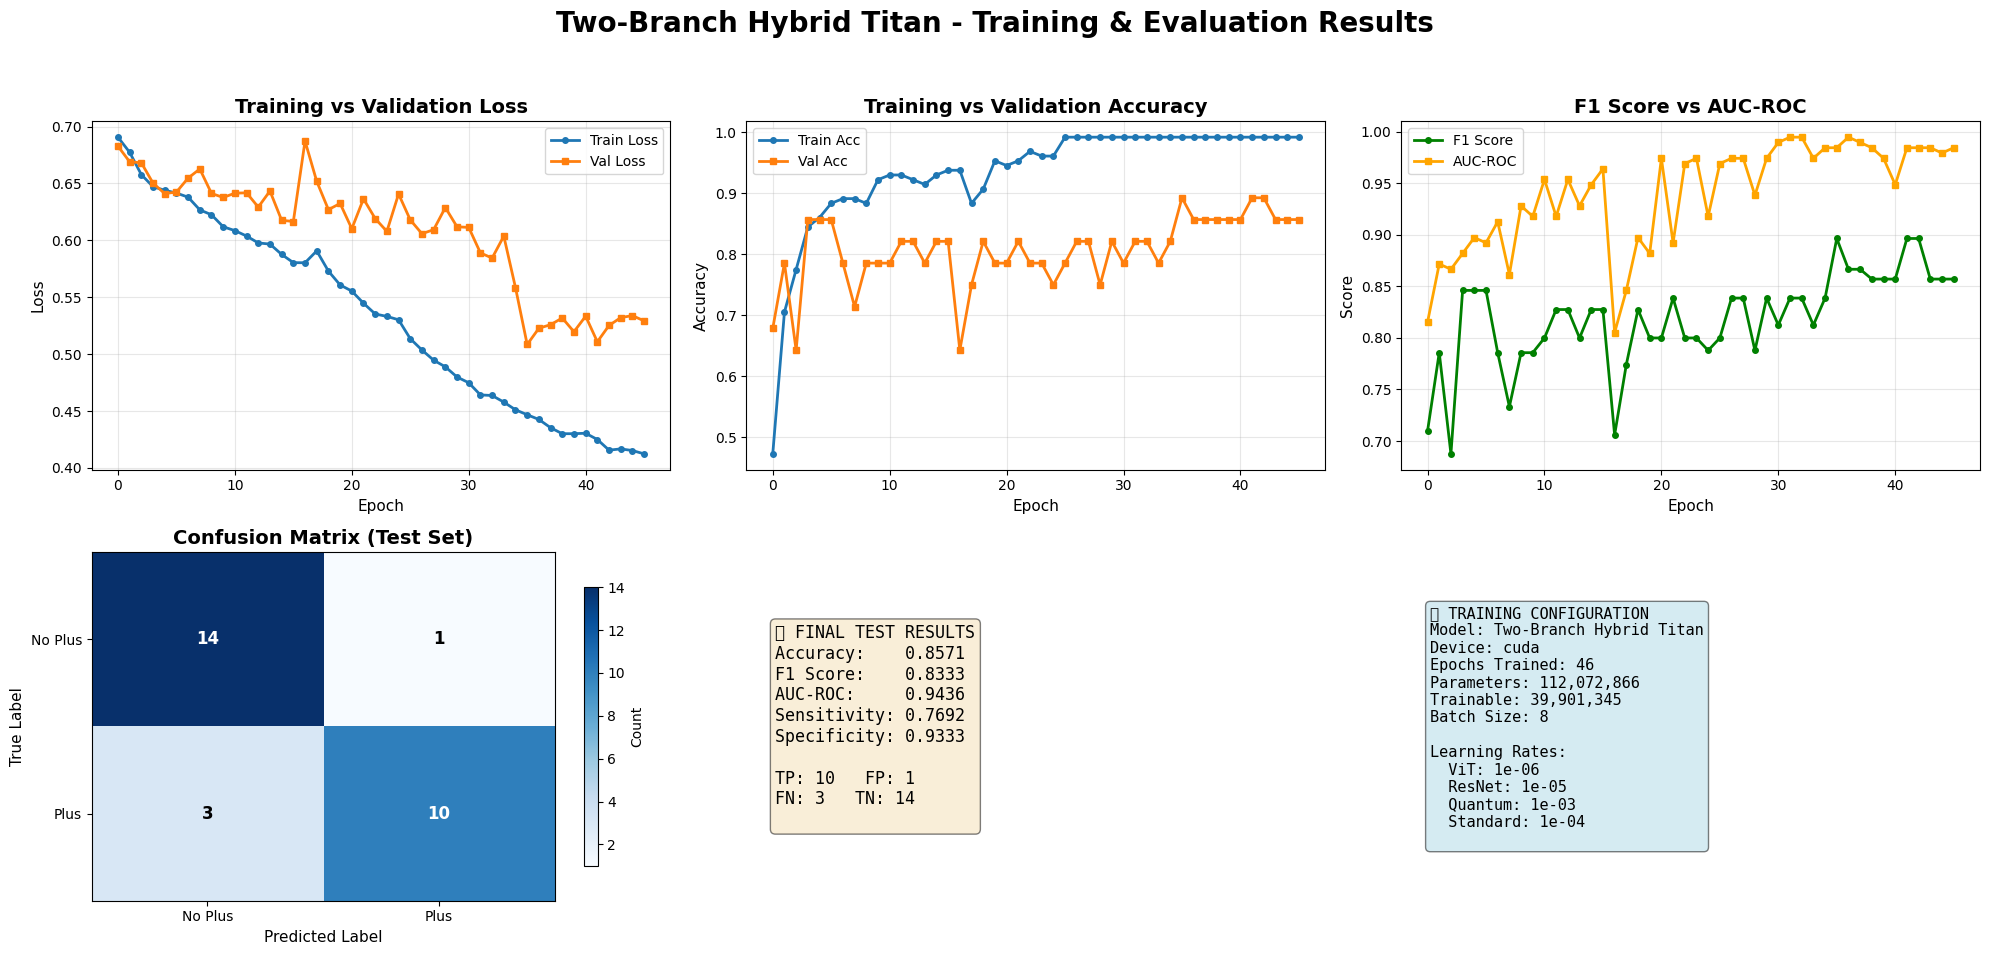


✅ VISUALIZATION COMPLETE


In [ ]:
# ============================================================================
# CELL 14: Visualize Training Curves and Confusion Matrix
# ============================================================================

print("="*60)
print("📊 VISUALIZATION")
print("="*60)

fig = plt.figure(figsize=(20, 10)) # Made figure wider
fig.suptitle("Two-Branch Hybrid Titan - Training & Evaluation Results", fontsize=20, fontweight='bold')

# ===== LOSS CURVES =====
ax1 = plt.subplot(2, 3, 1)
ax1.plot(train_history['loss'], label='Train Loss', marker='o', linewidth=2, markersize=4)
ax1.plot(val_history['loss'], label='Val Loss', marker='s', linewidth=2, markersize=4)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ===== ACCURACY CURVES =====
ax2 = plt.subplot(2, 3, 2)
ax2.plot(train_history['acc'], label='Train Acc', marker='o', linewidth=2, markersize=4)
ax2.plot(val_history['acc'], label='Val Acc', marker='s', linewidth=2, markersize=4)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# ===== F1 AND AUC =====
ax3 = plt.subplot(2, 3, 3)
ax3.plot(val_history['f1'], label='F1 Score', marker='o', linewidth=2, markersize=4, color='green')
ax3.plot(val_history['auc'], label='AUC-ROC', marker='s', linewidth=2, markersize=4, color='orange')
ax3.set_xlabel('Epoch', fontsize=11)
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('F1 Score vs AUC-ROC', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# ===== CONFUSION MATRIX HEATMAP =====
ax4 = plt.subplot(2, 3, 4)
im = ax4.imshow(cm, cmap='Blues', aspect='auto')
ax4.set_xlabel('Predicted Label', fontsize=11)
ax4.set_ylabel('True Label', fontsize=11)
ax4.set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(['No Plus', 'Plus'])
ax4.set_yticklabels(['No Plus', 'Plus'])

# Add values to heatmap
for i in range(2):
    for j in range(2):
        text = ax4.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black",
                       fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax4, label='Count', shrink=0.8)

# ===== METRICS SUMMARY =====
ax5 = plt.subplot(2, 3, 5)
ax5.axis('off')
metrics_text = f"""🎯 FINAL TEST RESULTS
Accuracy:    {test_acc:.4f}
F1 Score:    {test_f1:.4f}
AUC-ROC:     {test_auc:.4f}
Sensitivity: {sensitivity:.4f}
Specificity: {specificity:.4f}

TP: {tp}   FP: {fp}
FN: {fn}   TN: {tn}
"""
ax5.text(0.05, 0.5, metrics_text, fontsize=12, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round',
         facecolor='wheat', alpha=0.5))

# ===== TRAINING INFO =====
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
training_text = f"""📋 TRAINING CONFIGURATION
Model: Two-Branch Hybrid Titan
Device: {DEVICE}
Epochs Trained: {epoch+1}
Parameters: {total_params:,}
Trainable: {trainable_params:,}
Batch Size: {BATCH_SIZE}

Learning Rates:
  ViT: {LEARNING_RATE_ViT:.0e}
  ResNet: {LEARNING_RATE_ResNet:.0e}
  Quantum: {LEARNING_RATE_Quantum:.0e}
  Standard: {LEARNING_RATE_Standard:.0e}
"""
ax6.text(0.05, 0.5, training_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round',
         facecolor='lightblue', alpha=0.5))

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.savefig('/content/training_results.png', dpi=150, bbox_inches='tight')
print("✅ Results saved to: /content/training_results.png")
plt.show()

print("\n" + "="*60)
print("✅ VISUALIZATION COMPLETE")


In [ ]:
# ============================================================
# 🧠 TwoBranchHybridTitan with N_QUBITS = 16 (Full Code)
# ============================================================

# ============================================================
# 📦 Cell 0: Imports
# ============================================================
import os
import gc
import math
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from datetime import datetime
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

import pennylane as qml
from pennylane import numpy as pnp
from pennylane.qnn import TorchLayer

from transformers import ViTModel, ViTConfig
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ============================================================
# ⚙️ Cell 1: Data and Paths
# ============================================================
DATA_ZIP_PATH = "/content/ROP_dataset.zip"
EXTRACT_DIR = "/content/classification/class"
SEGMENT_MODEL_PATH = "/content/unet_segment_model.pth"


# Find image folders
normal_dirs = []
abnormal_dirs = []

for root, dirs, files in os.walk(EXTRACT_DIR):
    for d in dirs:
        if "Normal" in d:
            normal_dirs.append(os.path.join(root, d))
        elif "ROP" in d:
            abnormal_dirs.append(os.path.join(root, d))

print("✅ Found Normal folders:", normal_dirs)
print("✅ Found ROP folders:", abnormal_dirs)

# ============================================================
# 🎯 Cell 2: Config and Device Setup
# ============================================================
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_EPOCHS = 50
NUM_WORKERS = min(4, os.cpu_count() or 2)
TEST_SIZE = 0.2
VAL_RATIO = 0.1
EARLY_STOP_PATIENCE = 7

LEARNING_RATE_Standard = 1e-4
LEARNING_RATE_ViT = 1e-6
LEARNING_RATE_ResNet = 1e-5
LEARNING_RATE_Quantum = 1e-3

VIT_FEATURE_DIM = 768
MASK_CNN_FEATURE_DIM = 512
COMPRESSION_DIM_1 = 128
COMPRESSION_DIM_2 = 16   # keep same as original

N_QUBITS = 16             # 🔥 changed from 8 → 16
N_QUANTUM_LAYERS = 2

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Device:", DEVICE)

# ============================================================
# 🧩 Cell 3: U-Net Segmentation Model
# ============================================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.dconv_down1 = DoubleConv(in_channels, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)

        self.dconv_up3 = DoubleConv(256 + 512, 256)
        self.dconv_up2 = DoubleConv(128 + 256, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)

        self.conv_last = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        x = self.maxpool(conv1)
        conv2 = self.dconv_down2(x)
        x = self.maxpool(conv2)
        conv3 = self.dconv_down3(x)
        x = self.maxpool(conv3)
        x = self.dconv_down4(x)
        x = self.upsample(x)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        out = self.conv_last(x)
        return out


segmentation_model = UNet()
if os.path.exists(SEGMENT_MODEL_PATH):
    state_dict = torch.load(SEGMENT_MODEL_PATH, map_location="cpu")
    if isinstance(state_dict, dict):
        try:
            segmentation_model.load_state_dict(state_dict)
        except Exception as e:
            new_state = {k.replace("module.", ""): v for k, v in state_dict.items()}
            segmentation_model.load_state_dict(new_state)
segmentation_model.to(DEVICE)
segmentation_model.eval()
for p in segmentation_model.parameters():
    p.requires_grad = False

# ============================================================
# 🧾 Cell 4: Dataset
# ============================================================
class ROPClassificationDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        try:
            image = cv2.imread(path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        except:
            image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

        if self.transform:
            image = self.transform(image=image)["image"]
        else:
            image = torch.tensor(image / 255.0, dtype=torch.float32).permute(2, 0, 1)

        return image, label


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# ============================================================
# 📂 Cell 5: Data Preparation
# ============================================================
def get_image_files(paths):
    exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif")
    files = []
    for p in paths:
        for r, _, f in os.walk(p):
            files += [os.path.join(r, x) for x in f if x.lower().endswith(exts)]
    return files

normal_imgs = get_image_files(normal_dirs)
abnormal_imgs = get_image_files(abnormal_dirs)

print(f"Found {len(normal_imgs)} Normal, {len(abnormal_imgs)} ROP images")

X = normal_imgs + abnormal_imgs
y = [0]*len(normal_imgs) + [1]*len(abnormal_imgs)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

COUNT_NORMAL, COUNT_ABNORMAL = y.count(0), y.count(1)

# ============================================================
# 🧠 Cell 6: Quantum Circuit (N_QUBITS = 16)
# ============================================================
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # inputs: (batch, features)
    amplitude_features = inputs.reshape(inputs.shape[0], -1)

    target_len = 2 ** N_QUBITS  # 65536 for 16 qubits
    if amplitude_features.shape[1] < target_len:
        repeats = (target_len + amplitude_features.shape[1] - 1) // amplitude_features.shape[1]
        amplitude_features = amplitude_features.repeat(1, repeats)[:, :target_len]
    else:
        amplitude_features = amplitude_features[:, :target_len]

    qml.AmplitudeEmbedding(amplitude_features, wires=range(N_QUBITS), pad_with=0., normalize=True)

    for layer in range(N_QUANTUM_LAYERS):
        for i in range(N_QUBITS):
            qml.Rot(weights[layer, i, 0], weights[layer, i, 1], weights[layer, i, 2], wires=i)
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])

    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shape = (N_QUANTUM_LAYERS, N_QUBITS, 3)

# ============================================================
# 🏗️ Cell 7: Hybrid Model
# ============================================================
class TwoBranchHybridTitan(nn.Module):
    def __init__(self, segmentation_model):
        super().__init__()
        self.segmentation_model = segmentation_model

        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
        for p in self.vit.parameters():
            p.requires_grad = False
        for p in self.vit.encoder.layer[11].parameters():
            p.requires_grad = True
        for p in self.vit.embeddings.parameters():
            p.requires_grad = True

        self.vit_mean = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1).to(DEVICE)
        self.vit_std = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1).to(DEVICE)

        self.mask_cnn = timm.create_model("resnet18", pretrained=True, num_classes=0)
        self.mask_cnn.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.mask_cnn.conv1.weight = nn.Parameter(
                self.mask_cnn.conv1.weight.mean(dim=1, keepdim=True)
            )
        for p in self.mask_cnn.parameters():
            p.requires_grad = False
        for p in self.mask_cnn.conv1.parameters():
            p.requires_grad = True

        fusion_dim = VIT_FEATURE_DIM + MASK_CNN_FEATURE_DIM
        self.mha_refiner = nn.MultiheadAttention(embed_dim=fusion_dim, num_heads=8, batch_first=True)
        self.compression = nn.Sequential(
            nn.Linear(fusion_dim, COMPRESSION_DIM_1),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(COMPRESSION_DIM_1, COMPRESSION_DIM_2),
            nn.Tanh(),
        )

        self.vqc = TorchLayer(quantum_circuit, weight_shape)
        self.classifier_head = nn.Linear(N_QUBITS, 1)

    def forward(self, x):
        x_norm = (x - self.vit_mean) / self.vit_std
        vit_features = self.vit(x_norm).last_hidden_state[:, 0, :]

        with torch.no_grad():
            mask_logits = self.segmentation_model(x)
            masks = torch.sigmoid(mask_logits)

        mask_features = self.mask_cnn(masks)
        fused_features = torch.cat([vit_features, mask_features], dim=1)

        fused_unsq = fused_features.unsqueeze(1)
        refined, _ = self.mha_refiner(fused_unsq, fused_unsq, fused_unsq)
        refined = refined.squeeze(1)

        compressed = self.compression(refined)
        vqc_output = self.vqc(compressed)
        logits = self.classifier_head(vqc_output)
        return logits.squeeze(1)

# ============================================================
# ⚙️ Cell 8: Instantiate and Count Params
# ============================================================
model = TwoBranchHybridTitan(segmentation_model).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Total Parameters: {total_params:,}")
print(f"✅ Trainable Parameters: {trainable_params:,}")

# ============================================================
# 🚀 Cell 9: DataLoaders & Training Setup
# ============================================================
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.2),
    A.RandomBrightnessContrast(p=0.2),
])

train_dataset = ROPClassificationDataset(X_train, y_train, transform=train_transform)
val_dataset = ROPClassificationDataset(X_val, y_val)
test_dataset = ROPClassificationDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, worker_init_fn=seed_worker, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

pos_weight_value = COUNT_NORMAL / max(COUNT_ABNORMAL, 1)
pos_weight = torch.tensor([pos_weight_value], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW([
    {"params": model.vit.encoder.layer[11].parameters(), "lr": LEARNING_RATE_ViT},
    {"params": model.vit.embeddings.parameters(), "lr": LEARNING_RATE_Standard},
    {"params": model.mask_cnn.conv1.parameters(), "lr": LEARNING_RATE_ResNet},
    {"params": model.mha_refiner.parameters(), "lr": LEARNING_RATE_Standard},
    {"params": model.compression.parameters(), "lr": LEARNING_RATE_Standard},
    {"params": model.vqc.parameters(), "lr": LEARNING_RATE_Quantum},
    {"params": model.classifier_head.parameters(), "lr": LEARNING_RATE_Standard},
])
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

# ============================================================
# 🏋️ Cell 10: Training Loop
# ============================================================
best_val_loss = float("inf")
early_stop_counter = 0
train_losses, val_losses, train_accs, val_accs, val_f1s, val_aucs = [], [], [], [], [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds = (torch.sigmoid(logits) > 0.5).float()
        total_loss += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)

    train_loss = total_loss / total_samples
    train_acc = total_correct / total_samples

    # Validation
    model.eval()
    val_loss, val_correct, val_samples = 0, 0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            val_loss += loss.item() * x.size(0)
            val_correct += (preds == y).sum().item()
            val_samples += x.size(0)
            all_labels.extend(y.cpu().numpy())
            all_preds.extend(probs.cpu().numpy())

    val_loss /= val_samples
    val_acc = val_correct / val_samples
    val_f1 = f1_score(all_labels, np.array(all_preds) > 0.5)
    val_auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) == 2 else 0.5

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    val_aucs.append(val_auc)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f} | AUC: {val_auc:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), "best_model_16q.pth")
        print("✅ Saved best model.")
    else:
        early_stop_counter += 1
        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print("⏹️ Early stopping triggered.")
            break

# ============================================================
# 📊 Cell 11: Plotting
# ============================================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.tight_layout()
plt.show()


✅ Found Normal folders: ['/content/classification/class/Neo_Normal', '/content/classification/class/RetCam_Normal']
✅ Found ROP folders: ['/content/classification/class/RetCam_ROP', '/content/classification/class/Neo_ROP']
✅ Device: cuda
Found 100 Normal, 85 ROP images


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AttributeError: 'tuple' object has no attribute 'items'